In [10]:
# ============================================================================
# CELL 1: SGD TRAINING (baseline)
#
# Dong bo voi SAM / RWP / Controller:
#   1. set_seed() - reproducible
#   2. EarlyStopping dung unified_score = val_clean + ALPHA_WORST * val_worst
#      (cung tieu chi voi SAM de so sanh cong bang)
#   3. 4 loai robustness eval: Gaussian, Log-Normal, Uniform, Worst-Case
#   4. Cung noise_levels, num_mc, subset_size
# ============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import time
import copy
import random
import os


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
    torch.use_deterministic_algorithms(True, warn_only=True)


def train_sgd_no_io_fixed(seed=42):
    set_seed(seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device} | Seed: {seed}")

    # ----- Hyperparams (dong bo voi SAM cell) -----
    ALPHA_WORST = 0.3    # trong so worst-case trong unified score
    WC_EPSILON  = 0.01   # epsilon de tinh val worst-case moi epoch
    WC_SUBSET   = 1000   # subset size de tinh gradient worst-case val
    PATIENCE    = 20

    class SimpleMLP(nn.Module):
        def __init__(self):
            super().__init__()
            self.fc1 = nn.Linear(784, 512)
            self.fc2 = nn.Linear(512, 10)
            self.relu = nn.ReLU()

        def forward(self, x):
            x = self.relu(self.fc1(x))
            return self.fc2(x)

    class EarlyStopping:
        """
        Dung unified_score = val_clean + ALPHA_WORST * val_worst_case
        Dong bo voi SAM/RWP/Controller de chon checkpoint cong bang.
        """
        def __init__(self, patience=20):
            self.patience = patience
            self.counter = 0
            self.best_score = None
            self.best_model_state = None

        def __call__(self, score, model):
            if self.best_score is None or score > self.best_score:
                self.best_score = score
                self.best_model_state = copy.deepcopy(model.state_dict())
                self.counter = 0
            else:
                self.counter += 1
                if self.counter >= self.patience:
                    return True
            return False

        def load_best_model(self, model):
            if self.best_model_state is not None:
                model.load_state_dict(self.best_model_state)

    # ===== PRE-LOAD DATA =====
    import torchvision.transforms as transforms
    from torchvision.datasets import MNIST
    from torch.utils.data import DataLoader, random_split

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x.view(-1))
    ])

    full_train = MNIST(root='./data', train=True, download=True, transform=transform)
    test_set   = MNIST(root='./data', train=False, download=True, transform=transform)

    n_val   = int(len(full_train) * 0.1)
    n_train = len(full_train) - n_val
    train_set, val_set = random_split(full_train, [n_train, n_val],
                                      generator=torch.Generator().manual_seed(42))

    def preload_to_gpu(dataset):
        loader = DataLoader(dataset, batch_size=256, shuffle=False, num_workers=0)
        xs, ys = [], []
        for x, y in loader:
            xs.append(x); ys.append(y)
        return torch.cat(xs).to(device), torch.cat(ys).to(device)

    train_data, train_targets = preload_to_gpu(train_set)
    val_data,   val_targets   = preload_to_gpu(val_set)
    test_data,  test_targets  = preload_to_gpu(test_set)

    print(f"Train: {len(train_data):,} | Val: {len(val_data):,} | Test: {len(test_data):,}")

    # ===== HELPERS =====
    def eval_clean(model, data, targets):
        model.eval()
        with torch.no_grad():
            return 100. * (model(data).max(1)[1] == targets).sum().item() / len(targets)

    def eval_worst_case_acc(model, data, targets, epsilon, criterion, subset=1000):
        """Tinh acc sau khi perturb w += epsilon * sign(grad_w L)"""
        original = copy.deepcopy(model.state_dict())
        model.train()
        model.zero_grad()
        n = min(subset, len(data))
        loss = criterion(model(data[:n]), targets[:n])
        loss.backward()
        with torch.no_grad():
            for name, p in model.named_parameters():
                if 'weight' in name and p.grad is not None:
                    p.data.add_(epsilon * p.grad.sign())
        acc = eval_clean(model, data, targets)
        model.load_state_dict(original)
        return acc

    # ===== INIT =====
    model      = SimpleMLP().to(device)
    optimizer  = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=0.0001)
    criterion  = nn.CrossEntropyLoss()
    early_stop = EarlyStopping(patience=PATIENCE)

    batch_size  = 512
    num_batches = len(train_data) // batch_size
    history     = {'train_acc': [], 'val_acc': [], 'val_worst': [],
                   'val_score': [], 'test_acc': [], 'compute_times': []}
    total_compute = 0

    print(f"\n{'='*70}")
    print(f"SGD TRAINING  |  alpha_worst={ALPHA_WORST}  wc_eps={WC_EPSILON}")
    print(f"Early stopping: score = val_clean + {ALPHA_WORST} * val_worst_case")
    print(f"{'='*70}")
    print(f"{'Epoch':>6} {'LR':>7} {'Train':>8} {'Val':>8} {'ValWC':>8} {'Score':>8} {'Time':>7}")
    print("-" * 70)

    # ===== TRAINING LOOP =====
    for epoch in range(100):
        lr = 0.1 * 0.5 * (1 + np.cos(np.pi * epoch / 100))
        for pg in optimizer.param_groups:
            pg['lr'] = lr

        model.train()
        if torch.cuda.is_available(): torch.cuda.synchronize()
        t0 = time.perf_counter()

        correct, total, total_loss = 0, 0, 0.0
        indices = torch.randperm(len(train_data), device=device)

        for i in range(num_batches):
            idx       = indices[i*batch_size : (i+1)*batch_size]
            inputs    = train_data[idx]
            targets_b = train_targets[idx]

            optimizer.zero_grad()
            loss = criterion(model(inputs), targets_b)
            loss.backward()
            optimizer.step()

            with torch.no_grad():
                correct += (model(inputs).max(1)[1] == targets_b).sum().item()
                total   += targets_b.size(0)
            total_loss += loss.item() * inputs.size(0)

        if torch.cuda.is_available(): torch.cuda.synchronize()
        compute_time = time.perf_counter() - t0
        total_compute += compute_time

        train_acc = 100. * correct / total

        # Val: clean + worst-case -> unified score (dong bo voi SAM)
        val_acc   = eval_clean(model, val_data, val_targets)
        val_worst = eval_worst_case_acc(model, val_data, val_targets,
                                        WC_EPSILON, criterion, WC_SUBSET)
        val_score = val_acc + ALPHA_WORST * val_worst

        test_acc = eval_clean(model, test_data, test_targets)

        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['val_worst'].append(val_worst)
        history['val_score'].append(val_score)
        history['test_acc'].append(test_acc)
        history['compute_times'].append(compute_time)

        stopped = early_stop(val_score, model)

        if (epoch + 1) % 5 == 0 or epoch == 0 or stopped:
            print(f"{epoch+1:>6} {lr:>7.4f} {train_acc:>7.2f}% "
                  f"{val_acc:>7.2f}% {val_worst:>7.2f}% {val_score:>8.3f} {compute_time:>6.3f}s")

        if stopped:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

    early_stop.load_best_model(model)

    model.eval()
    with torch.no_grad():
        final_test_acc = 100. * (model(test_data).max(1)[1] == test_targets).sum().item() / len(test_data)

    num_epochs = len(history['compute_times'])
    print(f"\nFinal test accuracy (best model): {final_test_acc:.2f}%")
    print(f"Total compute time: {total_compute:.1f}s | Epochs: {num_epochs}")

    # ===== ROBUSTNESS EVALUATION =====
    print(f"\n{'='*60}")
    print("ROBUSTNESS EVALUATION")
    print(f"{'='*60}")

    original_state = copy.deepcopy(model.state_dict())
    noise_levels    = [0.0, 0.03, 0.06, 0.09, 0.12, 0.15]
    wc_noise_levels = [0, 0.003, 0.006, 0.009, 0.012, 0.015, 0.03]
    num_mc         = 500

    def eval_accuracy(m):
        m.eval()
        with torch.no_grad():
            return 100. * (m(test_data).max(1)[1] == test_targets).sum().item() / len(test_data)

    # ---- 1. Gaussian ----
    print(f"\n[1] Gaussian Noise: w_noisy = w + N(0, s^2)")
    print(f"{'s':>8} {'Accuracy':>10} {'Drop':>8}")
    print("-" * 30)
    gauss_results = {}
    for sigma in noise_levels:
        accs = []
        for _ in range(num_mc if sigma > 0 else 1):
            model.load_state_dict(original_state)
            with torch.no_grad():
                for name, param in model.named_parameters():
                    if 'weight' in name:
                        param.data.add_(torch.randn_like(param) * sigma)
            accs.append(eval_accuracy(model))
        gauss_results[sigma] = np.mean(accs)
        drop = gauss_results[0.0] - gauss_results[sigma] if sigma > 0 else 0.0
        print(f"{sigma:>8.3f} {gauss_results[sigma]:>9.2f}% {drop:>+7.2f}%")
    model.load_state_dict(original_state)

    # ---- 2. Log-normal ----
    print(f"\n[2] Log-Normal Noise: w_noisy = w * exp(N(0, s^2))")
    print(f"{'s':>8} {'Accuracy':>10} {'Drop':>8}")
    print("-" * 30)
    lognorm_results = {}
    for sigma in noise_levels:
        accs = []
        for _ in range(num_mc if sigma > 0 else 1):
            model.load_state_dict(original_state)
            with torch.no_grad():
                for name, param in model.named_parameters():
                    if 'weight' in name:
                        param.data.mul_(torch.exp(torch.randn_like(param) * sigma))
            accs.append(eval_accuracy(model))
        lognorm_results[sigma] = np.mean(accs)
        drop = lognorm_results[0.0] - lognorm_results[sigma] if sigma > 0 else 0.0
        print(f"{sigma:>8.3f} {lognorm_results[sigma]:>9.2f}% {drop:>+7.2f}%")
    model.load_state_dict(original_state)

    # ---- 3. Uniform ----
    print(f"\n[3] Uniform Noise: w_noisy = w + U(-a, a)")
    print(f"{'a':>8} {'Accuracy':>10} {'Drop':>8}")
    print("-" * 30)
    uniform_results = {}
    for sigma in noise_levels:
        accs = []
        for _ in range(num_mc if sigma > 0 else 1):
            model.load_state_dict(original_state)
            with torch.no_grad():
                for name, param in model.named_parameters():
                    if 'weight' in name:
                        param.data.add_((2 * torch.rand_like(param) - 1) * sigma)
            accs.append(eval_accuracy(model))
        uniform_results[sigma] = np.mean(accs)
        drop = uniform_results[0.0] - uniform_results[sigma] if sigma > 0 else 0.0
        print(f"{sigma:>8.3f} {uniform_results[sigma]:>9.2f}% {drop:>+7.2f}%")
    model.load_state_dict(original_state)

    # ---- 4. Worst-case ----
    print(f"\n[4] Worst-Case Noise: w_noisy = w + e * sign(grad_w L)")
    print(f"{'e':>8} {'Accuracy':>10} {'Drop':>8}")
    print("-" * 30)
    worst_results = {}
    criterion_eval = nn.CrossEntropyLoss()

    for epsilon in wc_noise_levels:
        model.load_state_dict(original_state)
        if epsilon == 0:
            worst_results[epsilon] = eval_accuracy(model)
            print(f"{epsilon:>8.3f} {worst_results[epsilon]:>9.2f}% {'0.00%':>8}")
            continue

        model.train()
        model.zero_grad()
        subset_size = min(2000, len(test_data))
        out  = model(test_data[:subset_size])
        loss = criterion_eval(out, test_targets[:subset_size])
        loss.backward()

        with torch.no_grad():
            for name, param in model.named_parameters():
                if 'weight' in name and param.grad is not None:
                    param.data.add_(epsilon * param.grad.sign())

        worst_results[epsilon] = eval_accuracy(model)
        drop = worst_results[0.0] - worst_results[epsilon]
        print(f"{epsilon:>8.3f} {worst_results[epsilon]:>9.2f}% {drop:>+7.2f}%")
        model.load_state_dict(original_state)

    # ---- Summary ----
    clean_acc = gauss_results[0.0]
    print(f"\n{'='*60}")
    print("ROBUSTNESS SUMMARY")
    print(f"{'='*60}")
    print(f"Clean accuracy: {clean_acc:.2f}%\n")
    print(f"{'Noise Type':<18} {'Avg Noisy Acc':>14} {'Drop @s=0.1':>12} {'Drop @s=0.2':>12}")
    print("-" * 60)
    for label, results in [('Gaussian',   gauss_results),
                            ('Log-Normal', lognorm_results),
                            ('Uniform',    uniform_results)]:
        avg_noisy = np.mean([v for k, v in results.items() if k > 0])
        d01 = results[0.0] - results.get(0.1, float('nan'))
        d02 = results[0.0] - results.get(0.2, float('nan'))
        print(f"{label:<18} {avg_noisy:>13.2f}% {d01:>+11.2f}% {d02:>+11.2f}%")
    # Worst-case dung level khac nen in rieng
    wc_avg = np.mean([v for k, v in worst_results.items() if k > 0])
    wc_d01 = worst_results[0.0] - worst_results.get(0.01, float('nan'))
    wc_d02 = worst_results[0.0] - worst_results.get(0.02, float('nan'))
    wc_d03 = worst_results[0.0] - worst_results.get(0.03, float('nan'))
    print(f"{'Worst-Case':<18} {wc_avg:>13.2f}% {'Drop@e=0.01':>12} {'Drop@e=0.02':>12} {'Drop@e=0.03':>12}")
    print(f"{'':18} {'':14} {wc_d01:>+11.2f}% {wc_d02:>+11.2f}% {wc_d03:>+11.2f}%")

    return {
        'final_test_acc':        final_test_acc,
        'total_compute_time':    total_compute,
        'avg_compute_per_epoch': np.mean(history['compute_times']),
        'num_epochs':            num_epochs,
        'history':               history,
        'robustness': {
            'gaussian':   gauss_results,
            'lognormal':  lognorm_results,
            'uniform':    uniform_results,
            'worst_case': worst_results,
        },
        'robustness_results':  gauss_results,
        'robustness_score':    np.mean([v for k, v in gauss_results.items() if k > 0]),
        'drop_at_01':          gauss_results[0.0] - gauss_results.get(0.1, 0),
        'drop_at_02':          gauss_results[0.0] - gauss_results.get(0.2, 0),
        'model':               model,
        'test_data':           test_data,
        'test_targets':        test_targets,
        'device':              device,
    }


# ============================================================================
# RUN
# ============================================================================

sgd_no_io_fixed = train_sgd_no_io_fixed(seed=42)

Using device: cuda | Seed: 42
Train: 54,000 | Val: 6,000 | Test: 10,000

SGD TRAINING  |  alpha_worst=0.3  wc_eps=0.01
Early stopping: score = val_clean + 0.3 * val_worst_case
 Epoch      LR    Train      Val    ValWC    Score    Time
----------------------------------------------------------------------
     1  0.1000   86.24%   92.03%   36.92%  103.108  0.186s
     5  0.0996   97.39%   96.50%   15.67%  101.200  0.187s
    10  0.0980   98.80%   97.33%   34.93%  107.813  0.185s
    15  0.0952   99.38%   97.45%   50.85%  112.705  0.185s
    20  0.0914   99.69%   97.68%   56.58%  114.658  0.181s
    25  0.0864   99.85%   97.68%   60.95%  115.968  0.187s
    30  0.0806   99.91%   97.97%   66.98%  118.062  0.182s
    35  0.0741   99.94%   97.93%   71.87%  119.493  0.184s
    40  0.0669   99.95%   98.00%   70.25%  119.075  0.186s
    45  0.0594   99.97%   97.95%   72.55%  119.715  0.180s
    50  0.0516   99.98%   97.87%   77.77%  121.197  0.184s
    55  0.0437   99.99%   97.93%   75.33%  12

In [11]:
# ============================================================================
# QUANTIZATION INT4 VÀ LƯU WEIGHTS SGD (TRUE INTEGER ARITHMETIC)
# ============================================================================

def save_sgd_weights_all_formats(sgd_results, prefix='sgd', bits=4, input_bits=8, num_mc=30):
    """Lưu cả weights float32 và int4 cho SGD model (true integer arithmetic)"""
    import scipy.io as sio
    import json
    import os
    from datetime import datetime
    import numpy as np
    import torch
    import copy

    # Sử dụng hàm run_int4_quantization đã định nghĩa trước đó (dùng chung)
    print("\n--- Bước 1: Thực hiện lượng tử hóa INT4 đúng (integer arithmetic) ---")
    quant_results = run_int4_quantization(sgd_results, bits=bits, input_bits=input_bits, num_mc=num_mc)

    os.makedirs('weights', exist_ok=True)
    model = sgd_results['model']
    test_data = sgd_results['test_data']
    test_targets = sgd_results['test_targets']
    test_acc = sgd_results['final_test_acc']

    # Lấy weights float32 từ model gốc
    with torch.no_grad():
        W1 = model.fc1.weight.detach().cpu().numpy()
        b1 = model.fc1.bias.detach().cpu().numpy()
        W2 = model.fc2.weight.detach().cpu().numpy()
        b2 = model.fc2.bias.detach().cpu().numpy()
        W1_T = W1.T
        W2_T = W2.T
        b1_col = b1.reshape(-1, 1)
        b2_col = b2.reshape(-1, 1)

    # 1. LƯU FLOAT32
    print("\n1. LƯU WEIGHTS FLOAT32:")
    float_data = {
        'W1': W1_T.astype(np.float32),
        'W2': W2_T.astype(np.float32),
        'b1': b1_col.astype(np.float32),
        'b2': b2_col.astype(np.float32),
        'test_accuracy': np.array([test_acc], dtype=np.float32),
        'timestamp': np.array([np.datetime64('now')], dtype='datetime64[s]')
    }
    float_filename = f'weights/{prefix}_float32.mat'
    sio.savemat(float_filename, float_data)
    print(f"   ✅ {float_filename}")

    # 2. LẤY DỮ LIỆU INT4 TỪ quant_results
    W1_int = quant_results['W1_int'].cpu().numpy()
    W2_int = quant_results['W2_int'].cpu().numpy()
    scale_W1 = quant_results['scale_W1']
    scale_W2 = quant_results['scale_W2']
    mae_W1 = quant_results['mae_W1']
    mae_W2 = quant_results['mae_W2']

    # Dequantize để có bản float tương ứng (dùng trong MATLAB)
    W1_deq = W1_int.astype(np.float32) * scale_W1
    W2_deq = W2_int.astype(np.float32) * scale_W2

    # Bias giữ nguyên (không lượng tử)
    scale_b1 = 1.0
    scale_b2 = 1.0

    # Transpose
    W1_int_T = W1_int.T
    W2_int_T = W2_int.T
    W1_deq_T = W1_deq.T
    W2_deq_T = W2_deq.T

    # Lưu int4
    print("\n2. LƯU INT4 WEIGHTS:")
    int4_data = {
        'W1_int': W1_int_T.astype(np.int8),
        'W2_int': W2_int_T.astype(np.int8),
        'W1': W1_deq_T.astype(np.float32),
        'W2': W2_deq_T.astype(np.float32),
        'b1': b1_col.astype(np.float32),
        'b2': b2_col.astype(np.float32),
        'scale_W1': np.array([scale_W1], dtype=np.float32),
        'scale_W2': np.array([scale_W2], dtype=np.float32),
        'scale_b1': np.array([scale_b1], dtype=np.float32),
        'scale_b2': np.array([scale_b2], dtype=np.float32),
        'q_min': np.array([-8], dtype=np.int8),
        'q_max': np.array([7], dtype=np.int8),
        'bits': np.array([4], dtype=np.uint8),
        'quantized_accuracy': np.array([quant_results['acc_int4']], dtype=np.float32),
        'model_name': f'{prefix}_int4',
        'description': '4-bit symmetric quantization for memristor (true integer arithmetic)',
        'timestamp': np.array([np.datetime64('now')], dtype='datetime64[s]')
    }
    int4_filename = f'weights/{prefix}_int4.mat'
    sio.savemat(int4_filename, int4_data)
    print(f"   ✅ {int4_filename}")

    # 3. JSON SUMMARY
    print("\n3. LƯU JSON SUMMARY:")
    rob_dict = quant_results['robustness']
    rob_entries = {f'sigma_{k:.2f}': v for k, v in rob_dict.items() if k > 0}

    # Lấy robustness gốc từ sgd_results để so sánh (nếu có)
    sgd_rob = sgd_results.get('robustness', {})
    sgd_gauss = sgd_rob.get('gaussian', {})

    summary = {
        'model_info': {
            'name': 'SGD_MLP',
            'architecture': '784-512-10',
            'parameters': {
                'W1': f"{W1.shape[0]}x{W1.shape[1]} ({W1.size:,})",
                'W2': f"{W2.shape[0]}x{W2.shape[1]} ({W2.size:,})",
                'total': f"{W1.size + W2.size + b1.size + b2.size:,}"
            }
        },
        'performance': {
            'float32_accuracy': float(test_acc),
            'int4_accuracy': float(quant_results['acc_int4']),
            'accuracy_drop': float(quant_results['drop']),
            'samples_flipped': int(quant_results['flipped']),
            'flipped_percent': float(100 * quant_results['flipped'] / len(test_targets))
        },
        'quantization': {
            'bits': 4,
            'range': [-8, 7],
            'scales': {
                'W1': float(scale_W1),
                'W2': float(scale_W2),
                'b1': 1.0,
                'b2': 1.0
            },
            'unique_values': {
                'W1': int(len(np.unique(W1_int))),
                'W2': int(len(np.unique(W2_int)))
            },
            'mae': {
                'W1': float(mae_W1),
                'W2': float(mae_W2)
            }
        },
        'robustness': {
            'clean': float(rob_dict[0.0]),
            **rob_entries
        },
        'float32_robustness_gaussian': {
            'clean': float(sgd_gauss.get(0.0, 0)),
            **{f'sigma_{k:.2f}': float(sgd_gauss[k]) for k in sorted(sgd_gauss) if k > 0}
        } if sgd_gauss else {},
        'files': {
            'float32': f'{prefix}_float32.mat',
            'int4': f'{prefix}_int4.mat',
            'json': f'{prefix}_summary.json'
        },
        'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    }

    json_filename = f'weights/{prefix}_summary.json'
    with open(json_filename, 'w') as f:
        json.dump(summary, f, indent=2)
    print(f"   ✅ {json_filename}")

    # 4. README TXT
    print("\n4. LƯU README TXT:")
    rob_lines = '\n'.join([f"  - σ={k:.2f}: {v:.2f}%" for k, v in rob_dict.items() if k > 0])

    txt_content = f"""SGD MODEL WEIGHTS — {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
================================================================

FLOAT32 MODEL:
  Test accuracy : {test_acc:.2f}%
  W1 shape      : {W1.shape} → {W1_T.shape} (transposed for MATLAB)
  W2 shape      : {W2.shape} → {W2_T.shape} (transposed for MATLAB)

INT4 QUANTIZATION (true integer arithmetic, symmetric per-tensor):
  Accuracy      : {quant_results['acc_int4']:.2f}%
  Drop          : {quant_results['drop']:+.2f}%
  Scale W1      : {scale_W1:.6f}
  Scale W2      : {scale_W2:.6f}
  Integer range : [-8, 7]
  Unique W1     : {len(np.unique(W1_int))} values
  Unique W2     : {len(np.unique(W2_int))} values
  MAE W1        : {mae_W1:.6f}
  MAE W2        : {mae_W2:.6f}
  Sample đổi nhãn: {quant_results['flipped']} / {len(test_targets)} ({100*quant_results['flipped']/len(test_targets):.2f}%)

ROBUSTNESS (Gaussian noise on integer weights - conductance variation):
  Clean: {rob_dict[0.0]:.2f}%
{rob_lines}

FILES:
  {prefix}_float32.mat  → Float32 weights (W1, W2, b1, b2) - transposed
  {prefix}_int4.mat     → INT4 weights (W1_int, W2_int) + dequantized floats + scales
  {prefix}_summary.json → Full metadata
  {prefix}_readme.txt   → This file

LOAD IN MATLAB:
  % Float32
  data = load('{prefix}_float32.mat');   % data.W1, data.W2, data.b1, data.b2

  % INT4 (integers + scales)
  data = load('{prefix}_int4.mat');      % data.W1_int, data.W2_int, data.scale_W1, ...
  % Dequantized floats (ready to use) are also in data.W1, data.W2

NOTE: This is TRUE integer arithmetic simulation. Dequantized weights are provided for convenience.
"""
    txt_filename = f'weights/{prefix}_readme.txt'
    with open(txt_filename, 'w') as f:
        f.write(txt_content)
    print(f"   ✅ {txt_filename}")

    print(f"\n📁 Tất cả files đã lưu trong thư mục 'weights/'")
    return {
        'float32': float_filename,
        'int4': int4_filename,
        'json': json_filename,
        'txt': txt_filename,
        'int4_robustness': rob_dict,
        'quant_accuracy': quant_results['acc_int4']
    }


# ============================================================================
# GỌI HÀM LƯU WEIGHTS SGD
# ============================================================================
print("\n" + "="*80)
print("LƯU WEIGHTS FLOAT32 VÀ INT4 CHO SGD MODEL (TRUE INTEGER ARITHMETIC)")
print("="*80)

if 'sgd_no_io_fixed' in globals():
    saved_files = save_sgd_weights_all_formats(sgd_no_io_fixed, prefix='sgd', bits=4, input_bits=8, num_mc=30)
    if saved_files:
        print("\n✅ HOÀN TẤT LƯU WEIGHTS!")
        for k, v in saved_files.items():
            if k in ['float32', 'int4', 'json', 'txt']:
                print(f"   {k:<8}: {v}")
else:
    print("❌ Chưa có kết quả SGD training. Cần chạy SGD training trước.")


LƯU WEIGHTS FLOAT32 VÀ INT4 CHO SGD MODEL (TRUE INTEGER ARITHMETIC)

--- Bước 1: Thực hiện lượng tử hóa INT4 đúng (integer arithmetic) ---
GPU compute capability 6.x < 7.0, torch.compile not supported. Using eager mode.


/tmp/ipykernel_55/1061122043.py:77: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:233.)
  a1 = torch.relu((x_int.float() @ W1_int.float().T) * (scale_input * scale_W1) + b1)
/tmp/ipykernel_55/1061122043.py:43: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10


INT4 QUANTIZATION — SAM MODEL (4-bit weight, 8-bit activation)

[Thông số]
  scale_W1   : 0.047822  |  scale_W2 : 0.135530
  scale_input: 0.003922  |  range    : [-8, 7]
  MAE W1     : 0.012071  |  MAE W2   : 0.032780
  Unique W1  : 13        |  Unique W2: 15

[Accuracy]
  Float32                  : 98.14%
  Dequantized float (cũ)   : 98.04%   ← drop ≈ 0, vô nghĩa
  Full INT4 (integer arith): 97.76%   ← drop thực sự
  Drop thực sự             : -0.38%
  Sample đổi nhãn          : 130 / 10000 (1.30%)

[Robustness INT4 dưới nhiễu conductance]
       σ        Acc     Drop
------------------------------
   0.000     97.76%   +0.00%
   0.030     97.71%   -0.05%
   0.060     97.07%   -0.69%
   0.090     96.08%   -1.68%
   0.120     94.06%   -3.70%
   0.150     89.90%   -7.86%

1. LƯU WEIGHTS FLOAT32:
   ✅ weights/sgd_float32.mat

2. LƯU INT4 WEIGHTS:
   ✅ weights/sgd_int4.mat

3. LƯU JSON SUMMARY:
   ✅ weights/sgd_summary.json

4. LƯU README TXT:
   ✅ weights/sgd_readme.txt

📁 Tất cả files 

In [4]:
# ============================================================================
# CELL 2: SAM TRAINING
# ============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import time
import copy
import random
import os


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
    torch.use_deterministic_algorithms(True, warn_only=True)


def train_sam_no_io_fixed(seed=42):
    set_seed(seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device} | Seed: {seed}")

    class SimpleMLP(nn.Module):
        def __init__(self):
            super().__init__()
            self.fc1 = nn.Linear(784, 512)
            self.fc2 = nn.Linear(512, 10)
            self.relu = nn.ReLU()

        def forward(self, x):
            x = self.relu(self.fc1(x))
            return self.fc2(x)

    class SAMOptimizer:
        def __init__(self, optimizer, rho=0.5):
            self.optimizer = optimizer
            self.rho = rho
            self.original_params = None

        @torch.no_grad()
        def _gradient_norm(self):
            grad_norm_sq = 0.0
            for group in self.optimizer.param_groups:
                for p in group['params']:
                    if p.grad is not None:
                        grad_norm_sq += torch.sum(p.grad ** 2)
            return torch.sqrt(grad_norm_sq).item() + 1e-12

        @torch.no_grad()
        def perturb_weights(self):
            grad_norm = self._gradient_norm()
            scale = self.rho / grad_norm
            self.original_params = []
            for group in self.optimizer.param_groups:
                for p in group['params']:
                    if p.grad is not None:
                        self.original_params.append(p.data.clone())
                        p.data.add_(scale * p.grad)

        @torch.no_grad()
        def restore_weights(self):
            if self.original_params is None:
                return
            idx = 0
            for group in self.optimizer.param_groups:
                for p in group['params']:
                    if p.grad is not None:
                        p.data.copy_(self.original_params[idx])
                        idx += 1
            self.original_params = None

        def step(self, closure):
            loss = closure()
            self.perturb_weights()
            closure()
            self.restore_weights()
            self.optimizer.step()
            return loss

    class EarlyStopping:
        def __init__(self, patience=20):
            self.patience = patience
            self.counter = 0
            self.best_val = None
            self.early_stop = False
            self.best_model_state = None

        def __call__(self, val_acc, model):
            if self.best_val is None or val_acc > self.best_val:
                self.best_val = val_acc
                self.best_model_state = copy.deepcopy(model.state_dict())
                self.counter = 0
            else:
                self.counter += 1
                if self.counter >= self.patience:
                    self.early_stop = True
            return self.early_stop

        def load_best_model(self, model):
            if self.best_model_state is not None:
                model.load_state_dict(self.best_model_state)

    # ===== PRE-LOAD DATA =====
    import torchvision.transforms as transforms
    from torchvision.datasets import MNIST
    from torch.utils.data import DataLoader, random_split

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x.view(-1))
    ])

    full_train = MNIST(root='./data', train=True, download=True, transform=transform)
    test_set   = MNIST(root='./data', train=False, download=True, transform=transform)

    n_val   = int(len(full_train) * 0.1)
    n_train = len(full_train) - n_val
    train_set, val_set = random_split(full_train, [n_train, n_val],
                                      generator=torch.Generator().manual_seed(42))

    def preload_to_gpu(dataset):
        loader = DataLoader(dataset, batch_size=256, shuffle=False, num_workers=0)
        xs, ys = [], []
        for x, y in loader:
            xs.append(x); ys.append(y)
        return torch.cat(xs).to(device), torch.cat(ys).to(device)

    train_data, train_targets = preload_to_gpu(train_set)
    val_data,   val_targets   = preload_to_gpu(val_set)
    test_data,  test_targets  = preload_to_gpu(test_set)

    print(f"Train: {len(train_data):,} | Val: {len(val_data):,} | Test: {len(test_data):,}")

    # ===== INIT =====
    model         = SimpleMLP().to(device)
    base_opt      = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=0.0001)
    sam_opt       = SAMOptimizer(base_opt, rho=1.0)
    criterion     = nn.CrossEntropyLoss()
    early_stop    = EarlyStopping(patience=20)

    batch_size  = 512
    num_batches = len(train_data) // batch_size
    history     = {'train_acc': [], 'val_acc': [], 'test_acc': [],
                   'train_loss': [], 'val_loss': [], 'compute_times': []}
    best_val    = 0
    total_compute = 0

    print(f"\n{'='*60}")
    print("SAM TRAINING")
    print(f"{'='*60}")
    print(f"{'Epoch':>6} {'LR':>7} {'Train':>8} {'Val':>8} {'Test':>8} {'Time':>7}")
    print("-" * 60)

    # ===== TRAINING LOOP =====
    for epoch in range(100):
        lr = 0.1 * 0.5 * (1 + np.cos(np.pi * epoch / 100))
        for pg in base_opt.param_groups:
            pg['lr'] = lr

        model.train()
        if torch.cuda.is_available(): torch.cuda.synchronize()
        t0 = time.perf_counter()

        correct, total, total_loss = 0, 0, 0.0
        indices = torch.randperm(len(train_data), device=device)

        for i in range(num_batches):
            idx   = indices[i*batch_size : (i+1)*batch_size]
            inputs, targets_b = train_data[idx], train_targets[idx]

            def closure():
                base_opt.zero_grad()
                loss = criterion(model(inputs), targets_b)
                loss.backward()
                return loss

            loss = sam_opt.step(closure)
            total_loss += loss.item() * inputs.size(0)

            with torch.no_grad():
                _, pred = model(inputs).max(1)
                correct += (pred == targets_b).sum().item()
                total   += targets_b.size(0)

        if torch.cuda.is_available(): torch.cuda.synchronize()
        compute_time = time.perf_counter() - t0
        total_compute += compute_time

        train_acc  = 100. * correct / total
        train_loss = total_loss / total

        model.eval()
        with torch.no_grad():
            val_out  = model(val_data)
            val_loss = criterion(val_out, val_targets).item()
            val_acc  = 100. * (val_out.max(1)[1] == val_targets).sum().item() / len(val_data)
            test_acc = 100. * (model(test_data).max(1)[1] == test_targets).sum().item() / len(test_data)

        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['test_acc'].append(test_acc)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['compute_times'].append(compute_time)

        if val_acc > best_val:
            best_val = val_acc

        stopped = early_stop(val_acc, model)

        if (epoch + 1) % 5 == 0 or epoch == 0 or stopped:
            print(f"{epoch+1:>6} {lr:>7.4f} {train_acc:>7.2f}% {val_acc:>7.2f}% {test_acc:>7.2f}% {compute_time:>6.3f}s")

        if stopped:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

    early_stop.load_best_model(model)

    model.eval()
    with torch.no_grad():
        final_test_acc = 100. * (model(test_data).max(1)[1] == test_targets).sum().item() / len(test_data)

    num_epochs = len(history['compute_times'])
    print(f"\nFinal test accuracy (best model): {final_test_acc:.2f}%")
    print(f"Total compute time: {total_compute:.1f}s | Epochs: {num_epochs}")

    # ===== ROBUSTNESS EVALUATION =====
    print(f"\n{'='*60}")
    print("ROBUSTNESS EVALUATION")
    print(f"{'='*60}")

    original_state = copy.deepcopy(model.state_dict())
    noise_levels    = [0.0, 0.03, 0.06, 0.09, 0.12, 0.15]
    wc_noise_levels = [0, 0.003, 0.006, 0.009, 0.012, 0.015, 0.03]
    num_mc         = 500  # Monte Carlo runs per noise level (for stochastic noises)

    def eval_accuracy(m):
        m.eval()
        with torch.no_grad():
            return 100. * (m(test_data).max(1)[1] == test_targets).sum().item() / len(test_data)

    # ---- 1. Gaussian noise ----
    print(f"\n[1] Gaussian Noise: w_noisy = w + N(0, σ²)")
    print(f"{'σ':>8} {'Accuracy':>10} {'Drop':>8}")
    print("-" * 30)
    gauss_results = {}
    for sigma in noise_levels:
        accs = []
        for _ in range(num_mc if sigma > 0 else 1):
            model.load_state_dict(original_state)
            with torch.no_grad():
                for name, param in model.named_parameters():
                    if 'weight' in name:
                        param.data.add_(torch.randn_like(param) * sigma)
            accs.append(eval_accuracy(model))
        gauss_results[sigma] = np.mean(accs)
        drop = gauss_results[0.0] - gauss_results[sigma] if sigma > 0 else 0.0
        print(f"{sigma:>8.3f} {gauss_results[sigma]:>9.2f}% {drop:>+7.2f}%")
    model.load_state_dict(original_state)

    # ---- 2. Log-normal noise ----
    print(f"\n[2] Log-Normal Noise: w_noisy = w * exp(N(0, σ²))")
    print(f"{'σ':>8} {'Accuracy':>10} {'Drop':>8}")
    print("-" * 30)
    lognorm_results = {}
    for sigma in noise_levels:
        accs = []
        for _ in range(num_mc if sigma > 0 else 1):
            model.load_state_dict(original_state)
            with torch.no_grad():
                for name, param in model.named_parameters():
                    if 'weight' in name:
                        lognorm_factor = torch.exp(torch.randn_like(param) * sigma)
                        param.data.mul_(lognorm_factor)
            accs.append(eval_accuracy(model))
        lognorm_results[sigma] = np.mean(accs)
        drop = lognorm_results[0.0] - lognorm_results[sigma] if sigma > 0 else 0.0
        print(f"{sigma:>8.3f} {lognorm_results[sigma]:>9.2f}% {drop:>+7.2f}%")
    model.load_state_dict(original_state)

    # ---- 3. Uniform noise ----
    print(f"\n[3] Uniform Noise: w_noisy = w + U(-a, a)")
    print(f"{'a':>8} {'Accuracy':>10} {'Drop':>8}")
    print("-" * 30)
    uniform_results = {}
    for sigma in noise_levels:
        accs = []
        for _ in range(num_mc if sigma > 0 else 1):
            model.load_state_dict(original_state)
            with torch.no_grad():
                for name, param in model.named_parameters():
                    if 'weight' in name:
                        param.data.add_((2 * torch.rand_like(param) - 1) * sigma)
            accs.append(eval_accuracy(model))
        uniform_results[sigma] = np.mean(accs)
        drop = uniform_results[0.0] - uniform_results[sigma] if sigma > 0 else 0.0
        print(f"{sigma:>8.3f} {uniform_results[sigma]:>9.2f}% {drop:>+7.2f}%")
    model.load_state_dict(original_state)

    # ---- 4. Worst-case noise ----
    # Worst-case: perturbation aligned with gradient sign (adversarial weight perturbation)
    print(f"\n[4] Worst-Case Noise: w_noisy = w + ε * sign(∇_w L)")
    print(f"{'ε':>8} {'Accuracy':>10} {'Drop':>8}")
    print("-" * 30)
    worst_results = {}
    criterion_eval = nn.CrossEntropyLoss()

    for epsilon in wc_noise_levels:
        model.load_state_dict(original_state)
        if epsilon == 0:
            worst_results[epsilon] = eval_accuracy(model)
            print(f"{epsilon:>8.3f} {worst_results[epsilon]:>9.2f}% {'0.00%':>8}")
            continue

        # Compute gradient w.r.t. weights on full test set (or a subset for speed)
        model.train()
        model.zero_grad()
        subset_size = min(2000, len(test_data))
        out  = model(test_data[:subset_size])
        loss = criterion_eval(out, test_targets[:subset_size])
        loss.backward()

        with torch.no_grad():
            for name, param in model.named_parameters():
                if 'weight' in name and param.grad is not None:
                    param.data.add_(epsilon * param.grad.sign())

        worst_results[epsilon] = eval_accuracy(model)
        drop = worst_results[0.0] - worst_results[epsilon]
        print(f"{epsilon:>8.3f} {worst_results[epsilon]:>9.2f}% {drop:>+7.2f}%")
        model.load_state_dict(original_state)

    # ---- Summary ----
    clean_acc = gauss_results[0.0]
    print(f"\n{'='*60}")
    print("ROBUSTNESS SUMMARY")
    print(f"{'='*60}")
    print(f"Clean accuracy: {clean_acc:.2f}%\n")
    print(f"{'Noise Type':<18} {'Avg Noisy Acc':>14} {'Drop @σ=0.1':>12} {'Drop @σ=0.2':>12}")
    print("-" * 60)
    for label, results in [("Gaussian", gauss_results),
                            ("Log-Normal", lognorm_results),
                            ("Uniform", uniform_results),
                            ("Worst-Case", worst_results)]:
        avg_noisy = np.mean([v for k, v in results.items() if k > 0])
        d01 = results[0.0] - results.get(0.1, float('nan'))
        d02 = results[0.0] - results.get(0.2, float('nan'))
        print(f"{label:<18} {avg_noisy:>13.2f}% {d01:>+11.2f}% {d02:>+11.2f}%")

    return {
        'final_test_acc':      final_test_acc,
        'total_compute_time':  total_compute,
        'avg_compute_per_epoch': np.mean(history['compute_times']),
        'num_epochs':          num_epochs,
        'history':             history,
        'robustness': {
            'gaussian':   gauss_results,
            'lognormal':  lognorm_results,
            'uniform':    uniform_results,
            'worst_case': worst_results,
        },
        'robustness_results':  gauss_results,   # backward-compat alias
        'robustness_score':    np.mean([v for k, v in gauss_results.items() if k > 0]),
        'drop_at_01':          gauss_results[0.0] - gauss_results.get(0.1, 0),
        'drop_at_02':          gauss_results[0.0] - gauss_results.get(0.2, 0),
        'model':               model,
        'test_data':           test_data,
        'test_targets':        test_targets,
        'device':              device,
    }


# ============================================================================
# RUN
# ============================================================================

sam_results_fixed = train_sam_no_io_fixed(seed=42)


# ============================================================================
# COMPARE SGD vs SAM
# ============================================================================

def compare_sgd_sam(sgd_results, sam_results):
    print(f"\n{'='*60}")
    print("SGD vs SAM COMPARISON")
    print(f"{'='*60}")

    metrics = [
        ('Test Accuracy',       'final_test_acc',         '%'),
        ('Robustness Score',    'robustness_score',       '%'),
        ('Drop at σ=0.1',      'drop_at_01',             '%'),
        ('Drop at σ=0.2',      'drop_at_02',             '%'),
        ('Avg Compute/Epoch',   'avg_compute_per_epoch',  's'),
        ('Num Epochs',          'num_epochs',             ''),
    ]

    print(f"\n{'Metric':<22} {'SGD':>10} {'SAM':>10} {'Diff':>10}")
    print("-" * 55)
    for name, key, unit in metrics:
        s = sgd_results[key]; a = sam_results[key]
        diff = a - s
        fmt = f"{diff:+.2f}" if unit in ('%', 's') else f"{a/s:.2f}x"
        print(f"{name:<22} {s:>9.2f}{unit} {a:>9.2f}{unit} {fmt:>10}")

    # Robustness comparison per noise type
    print(f"\nRobustness detail (Gaussian noise, σ levels):")
    print(f"{'σ':>8} {'SGD Acc':>10} {'SAM Acc':>10} {'Diff':>8}")
    print("-" * 40)
    sgd_rob = sgd_results.get('robustness_results', {})
    sam_rob = sam_results['robustness']['gaussian']
    for sigma in sorted(set(sgd_rob) & set(sam_rob)):
        if sigma <= 0.2:
            diff = sam_rob[sigma] - sgd_rob[sigma]
            print(f"{sigma:>8.3f} {sgd_rob[sigma]:>9.2f}% {sam_rob[sigma]:>9.2f}% {diff:>+7.2f}%")

    # SAM extra noise types
    print(f"\nSAM robustness across all noise types (avg noisy accuracy):")
    for ntype, results in sam_results['robustness'].items():
        avg = np.mean([v for k, v in results.items() if k > 0])
        print(f"  {ntype:<12}: {avg:.2f}%")


if 'sgd_no_io_fixed' in globals():
    compare_sgd_sam(sgd_no_io_fixed, sam_results_fixed)
else:
    print("\n[INFO] SGD results not found. Run Cell 1 first for full comparison.")
    print(f"SAM final test accuracy: {sam_results_fixed['final_test_acc']:.2f}%")


Using device: cuda | Seed: 42
Train: 54,000 | Val: 6,000 | Test: 10,000

SAM TRAINING
 Epoch      LR    Train      Val     Test    Time
------------------------------------------------------------
     1  0.1000   17.30%   16.00%   15.57%  0.321s
     5  0.0996   94.47%   94.72%   95.25%  0.319s
    10  0.0980   97.39%   96.90%   97.07%  0.319s
    15  0.0952   98.22%   97.47%   97.72%  0.320s
    20  0.0914   98.66%   97.62%   97.83%  0.317s
    25  0.0864   98.89%   97.87%   98.06%  0.305s
    30  0.0806   99.14%   97.98%   98.13%  0.311s
    35  0.0741   99.24%   98.08%   98.21%  0.312s
    40  0.0669   99.35%   98.03%   98.25%  0.313s
    45  0.0594   99.39%   98.03%   98.34%  0.324s
    50  0.0516   99.46%   98.12%   98.31%  0.324s
    55  0.0437   99.49%   98.05%   98.37%  0.317s
    60  0.0361   99.53%   98.15%   98.35%  0.315s
    65  0.0287   99.55%   98.13%   98.40%  0.318s
    70  0.0219   99.60%   98.15%   98.35%  0.318s
    74  0.0169   99.60%   98.10%   98.37%  0.345s

Ea

In [5]:
# ============================================================================
# CELL: INT4 QUANTIZATION (TRUE INTEGER ARITHMETIC) — SAM MODEL (GPU OPTIMIZED)
# ============================================================================

import torch
import numpy as np
import copy

def run_int4_quantization(sam_results, bits=4, input_bits=8, num_mc=30):
    # Đảm bảo mọi thứ trên cùng một device (GPU nếu có)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = sam_results['model'].to(device)
    test_data = sam_results['test_data'].to(device).float()
    test_targets = sam_results['test_targets'].to(device)

    model.eval()
    q_min = -(2 ** (bits - 1))        # -8
    q_max =  (2 ** (bits - 1)) - 1    #  7
    scale_input = 1.0 / (2 ** input_bits - 1)  # 1/255

    # Lấy trọng số từ model (đã ở GPU)
    with torch.no_grad():
        W1 = model.fc1.weight.detach()
        b1 = model.fc1.bias.detach().float()
        W2 = model.fc2.weight.detach()
        b2 = model.fc2.bias.detach().float()

    # Hàm lượng tử hóa tensor (symmetric)
    def quant(tensor, scale):
        return torch.clamp(torch.round(tensor / scale), q_min, q_max).to(torch.int8)

    # Tính scale cho từng layer
    scale_W1 = W1.abs().max().item() / q_max
    scale_W2 = W2.abs().max().item() / q_max
    W1_int = quant(W1, scale_W1)   # int8 trên GPU
    W2_int = quant(W2, scale_W2)   # int8 trên GPU

    # ---- Forward pass integer (có thể nhận weight động) ----
    def forward_int4(x, W1_cur=W1_int, W2_cur=W2_int, scale_a1_fixed=None):
        # Lớp 1: input → uint8
        x_int = torch.clamp(torch.round(x / scale_input), 0, 2**input_bits - 1).to(torch.int32)
        # Chuyển về float32 để nhân ma trận (vẫn đảm bảo độ chính xác vì giá trị nhỏ)
        z1 = (x_int.float() @ W1_cur.float().T) * (scale_input * scale_W1) + b1
        a1 = torch.relu(z1)

        # Xác định scale cho activation (nếu chưa có fixed)
        if scale_a1_fixed is None:
            scale_a1 = a1.abs().max().item() / q_max if a1.abs().max().item() > 0 else 1.0
        else:
            scale_a1 = scale_a1_fixed

        # Lượng tử hóa activation
        a1_int = torch.clamp(torch.round(a1 / scale_a1), q_min, q_max).to(torch.int32)
        z2 = (a1_int.float() @ W2_cur.float().T) * (scale_a1 * scale_W2) + b2
        return z2

    # ---- Kiểm tra xem có thể dùng torch.compile không (GPU >= CC 7.0) ----
    use_compile = False
    if torch.cuda.is_available():
        major = torch.cuda.get_device_properties(0).major
        if major >= 7:
            use_compile = True
            print(f"GPU compute capability {major}.x >= 7.0, using torch.compile for speed.")
        else:
            print(f"GPU compute capability {major}.x < 7.0, torch.compile not supported. Using eager mode.")
    else:
        print("CPU mode, torch.compile not used.")

    if use_compile:
        forward_int4 = torch.compile(forward_int4, mode="reduce-overhead")

    # ---- Tính scale activation tĩnh từ một batch mẫu ----
    with torch.no_grad():
        sample_batch = test_data[:1000]
        # Forward mẫu để lấy a1, tính scale
        x_int = torch.clamp(torch.round(sample_batch / scale_input), 0, 2**input_bits - 1).to(torch.int32)
        a1 = torch.relu((x_int.float() @ W1_int.float().T) * (scale_input * scale_W1) + b1)
        scale_a1_fixed = a1.abs().max().item() / q_max if a1.abs().max().item() > 0 else 1.0

    # ---- Hàm evaluate nhanh (full batch) ----
    def evaluate(fwd_fn):
        logits = fwd_fn(test_data)
        preds = logits.max(1)[1]
        return 100. * (preds == test_targets).sum().item() / len(test_targets)

    # ---- Accuracy baseline ----
    with torch.no_grad():
        acc_float = 100. * (model(test_data).max(1)[1] == test_targets).sum().item() / len(test_targets)

    # ---- Accuracy của cách cũ (dequantize, sai) ----
    wrong_model = copy.deepcopy(model).cpu()
    wrong_model.fc1.weight.data.copy_((W1_int.float() * scale_W1).cpu())
    wrong_model.fc2.weight.data.copy_((W2_int.float() * scale_W2).cpu())
    wrong_model.eval()
    with torch.no_grad():
        acc_deq = 100. * (wrong_model(test_data.cpu()).max(1)[1] == test_targets.cpu()).sum().item() / len(test_targets)

    # ---- Accuracy thật của INT4 (integer arithmetic) ----
    acc_int4 = evaluate(lambda x: forward_int4(x, scale_a1_fixed=scale_a1_fixed))

    # ---- Sai số lượng tử hóa weight ----
    mae_W1 = (W1 - W1_int.float() * scale_W1).abs().mean().item()
    mae_W2 = (W2 - W2_int.float() * scale_W2).abs().mean().item()

    # ---- Số mẫu bị đổi nhãn ----
    with torch.no_grad():
        pred_float = model(test_data).max(1)[1]
    pred_int4 = forward_int4(test_data, scale_a1_fixed=scale_a1_fixed).max(1)[1]
    flipped = (pred_float != pred_int4).sum().item()

    # ---- Robustness: thêm nhiễu vào integer weights (mô phỏng conductance variation) ----
    noise_levels = [0.0, 0.03, 0.06, 0.09, 0.12, 0.15]
    rob_results = {}
    for sigma in noise_levels:
        if sigma == 0:
            rob_results[sigma] = acc_int4
            continue
        accs = []
        for _ in range(num_mc):
            # Tạo nhiễu trên GPU
            W1_noisy = torch.clamp(
                torch.round(W1_int.float() + torch.randn_like(W1.float()) * sigma * q_max),
                q_min, q_max
            ).to(torch.int8)
            W2_noisy = torch.clamp(
                torch.round(W2_int.float() + torch.randn_like(W2.float()) * sigma * q_max),
                q_min, q_max
            ).to(torch.int8)

            # Forward với weight nhiễu, scale activation cố định
            fwd = lambda x: forward_int4(x, W1_noisy, W2_noisy, scale_a1_fixed)
            accs.append(evaluate(fwd))
        rob_results[sigma] = np.mean(accs)

    # ---- In kết quả ----
    print(f"\n{'='*60}")
    print(f"INT4 QUANTIZATION — SAM MODEL ({bits}-bit weight, {input_bits}-bit activation)")
    print(f"{'='*60}")

    print(f"\n[Thông số]")
    print(f"  scale_W1   : {scale_W1:.6f}  |  scale_W2 : {scale_W2:.6f}")
    print(f"  scale_input: {scale_input:.6f}  |  range    : [{q_min}, {q_max}]")
    print(f"  MAE W1     : {mae_W1:.6f}  |  MAE W2   : {mae_W2:.6f}")
    print(f"  Unique W1  : {len(torch.unique(W1_int))}        |  Unique W2: {len(torch.unique(W2_int))}")

    print(f"\n[Accuracy]")
    print(f"  Float32                  : {acc_float:.2f}%")
    print(f"  Dequantized float (cũ)   : {acc_deq:.2f}%   ← drop ≈ 0, vô nghĩa")
    print(f"  Full INT4 (integer arith): {acc_int4:.2f}%   ← drop thực sự")
    print(f"  Drop thực sự             : {acc_int4 - acc_float:+.2f}%")
    print(f"  Sample đổi nhãn          : {flipped} / {len(test_targets)} ({100*flipped/len(test_targets):.2f}%)")

    print(f"\n[Robustness INT4 dưới nhiễu conductance]")
    print(f"{'σ':>8} {'Acc':>10} {'Drop':>8}")
    print("-" * 30)
    for sigma, acc in rob_results.items():
        drop = acc - acc_int4
        print(f"{sigma:>8.3f} {acc:>9.2f}% {drop:>+7.2f}%")

    return {
        'acc_float':   acc_float,
        'acc_deq':     acc_deq,
        'acc_int4':    acc_int4,
        'drop':        acc_int4 - acc_float,
        'flipped':     flipped,
        'scale_W1':    scale_W1,
        'scale_W2':    scale_W2,
        'W1_int':      W1_int,
        'W2_int':      W2_int,
        'mae_W1':      mae_W1,
        'mae_W2':      mae_W2,
        'robustness':  rob_results,
    }


# ============================================================================
# CHẠY LƯỢNG TỬ HÓA CHO SAM MODEL
# ============================================================================

quant_results = run_int4_quantization(sam_results_fixed, bits=4, input_bits=8, num_mc=30)


# ============================================================================
# CELL: LƯU WEIGHTS FLOAT32 VÀ INT4 CHO SAM MODEL
# ============================================================================

import scipy.io as sio
import json
import os
from datetime import datetime

def save_int4_weights(sam_results, quant_results, prefix='sam'):
    """
    Lưu weights float32 và int4 ra file .mat, .json, .txt
    Args:
        sam_results: kết quả từ train_sam_no_io_fixed (chứa model, test_data, test_targets)
        quant_results: kết quả từ run_int4_quantization
        prefix: tiền tố cho tên file
    """
    os.makedirs('weights', exist_ok=True)
    
    model = sam_results['model']
    model.eval()
    test_data = sam_results['test_data']
    test_targets = sam_results['test_targets']
    test_acc = sam_results['final_test_acc']
    
    # Lấy weights float32 từ model gốc (chuyển về CPU để lưu)
    with torch.no_grad():
        W1 = model.fc1.weight.detach().cpu().numpy()
        b1 = model.fc1.bias.detach().cpu().numpy()
        W2 = model.fc2.weight.detach().cpu().numpy()
        b2 = model.fc2.bias.detach().cpu().numpy()
        W1_T = W1.T
        W2_T = W2.T
        b1_col = b1.reshape(-1, 1)
        b2_col = b2.reshape(-1, 1)
    
    # ---- 1. Lưu float32 ----
    print("\n1. LƯU WEIGHTS FLOAT32:")
    float_data = {
        'W1': W1_T.astype(np.float32),
        'W2': W2_T.astype(np.float32),
        'b1': b1_col.astype(np.float32),
        'b2': b2_col.astype(np.float32),
        'test_accuracy': np.array([test_acc], dtype=np.float32),
        'timestamp': np.array([np.datetime64('now')], dtype='datetime64[s]')
    }
    float_filename = f'weights/{prefix}_float32.mat'
    sio.savemat(float_filename, float_data)
    print(f"   ✅ {float_filename}")
    
    # ---- 2. Lấy dữ liệu int4 từ quant_results ----
    W1_int = quant_results['W1_int'].cpu().numpy()   # int8
    W2_int = quant_results['W2_int'].cpu().numpy()
    scale_W1 = quant_results['scale_W1']
    scale_W2 = quant_results['scale_W2']
    
    # Dequantize để có bản float tương ứng (dùng trong MATLAB)
    W1_deq = W1_int.astype(np.float32) * scale_W1
    W2_deq = W2_int.astype(np.float32) * scale_W2
    
    # Bias giữ nguyên float (không lượng tử)
    scale_b1 = 1.0
    scale_b2 = 1.0
    
    # Chuyển về shape phù hợp (transpose)
    W1_int_T = W1_int.T
    W2_int_T = W2_int.T
    W1_deq_T = W1_deq.T
    W2_deq_T = W2_deq.T
    
    # ---- Lưu int4 ----
    print("\n2. LƯU INT4 WEIGHTS:")
    int4_data = {
        # Integer values (int8)
        'W1_int': W1_int_T.astype(np.int8),
        'W2_int': W2_int_T.astype(np.int8),
        # Dequantized float values (dùng trực tiếp trong MATLAB)
        'W1': W1_deq_T.astype(np.float32),
        'W2': W2_deq_T.astype(np.float32),
        'b1': b1_col.astype(np.float32),
        'b2': b2_col.astype(np.float32),
        # Scale factors
        'scale_W1': np.array([scale_W1], dtype=np.float32),
        'scale_W2': np.array([scale_W2], dtype=np.float32),
        'scale_b1': np.array([scale_b1], dtype=np.float32),
        'scale_b2': np.array([scale_b2], dtype=np.float32),
        # Metadata
        'q_min': np.array([-8], dtype=np.int8),
        'q_max': np.array([7], dtype=np.int8),
        'bits': np.array([4], dtype=np.uint8),
        'quantized_accuracy': np.array([quant_results['acc_int4']], dtype=np.float32),
        'model_name': f'{prefix}_int4',
        'description': '4-bit symmetric quantization for memristor (true integer arithmetic)',
        'timestamp': np.array([np.datetime64('now')], dtype='datetime64[s]')
    }
    int4_filename = f'weights/{prefix}_int4.mat'
    sio.savemat(int4_filename, int4_data)
    print(f"   ✅ {int4_filename}")
    
    # ---- 3. JSON summary ----
    print("\n3. LƯU JSON SUMMARY:")
    
    rob_dict = quant_results['robustness']
    rob_entries = {f'sigma_{k:.2f}': v for k, v in rob_dict.items() if k > 0}
    
    summary = {
        'model_info': {
            'name': 'SAM_MLP',
            'architecture': '784-512-10',
            'parameters': {
                'W1': f"{W1.shape[0]}x{W1.shape[1]} ({W1.size:,})",
                'W2': f"{W2.shape[0]}x{W2.shape[1]} ({W2.size:,})",
                'total': f"{W1.size + W2.size + b1.size + b2.size:,}"
            }
        },
        'performance': {
            'float32_accuracy': float(test_acc),
            'int4_accuracy': float(quant_results['acc_int4']),
            'accuracy_drop': float(quant_results['drop']),
            'samples_flipped': int(quant_results['flipped']),
            'flipped_percent': float(100 * quant_results['flipped'] / len(test_targets))
        },
        'quantization': {
            'bits': 4,
            'range': [-8, 7],
            'scales': {
                'W1': float(scale_W1),
                'W2': float(scale_W2),
                'b1': 1.0,
                'b2': 1.0
            },
            'unique_values': {
                'W1': int(len(np.unique(W1_int))),
                'W2': int(len(np.unique(W2_int)))
            },
            'mae': {
                'W1': float(quant_results['mae_W1']),
                'W2': float(quant_results['mae_W2'])
            }
        },
        'robustness': {
            'clean': float(rob_dict[0.0]),
            **rob_entries
        },
        'files': {
            'float32': f'{prefix}_float32.mat',
            'int4': f'{prefix}_int4.mat',
            'json': f'{prefix}_summary.json'
        },
        'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    }
    
    json_filename = f'weights/{prefix}_summary.json'
    with open(json_filename, 'w') as f:
        json.dump(summary, f, indent=2)
    print(f"   ✅ {json_filename}")
    
    # ---- 4. README txt ----
    print("\n4. LƯU README TXT:")
    
    rob_lines = '\n'.join([f"  - σ={k:.2f}: {v:.2f}%" for k, v in rob_dict.items() if k > 0])
    
    txt_content = f"""SAM MODEL WEIGHTS — {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
================================================================

FLOAT32 MODEL:
  Test accuracy : {test_acc:.2f}%
  W1 shape      : {W1.shape} → {W1_T.shape} (transposed for MATLAB)
  W2 shape      : {W2.shape} → {W2_T.shape} (transposed for MATLAB)

INT4 QUANTIZATION (true integer arithmetic, symmetric per-tensor):
  Accuracy      : {quant_results['acc_int4']:.2f}%
  Drop          : {quant_results['drop']:+.2f}%
  Scale W1      : {scale_W1:.6f}
  Scale W2      : {scale_W2:.6f}
  Integer range : [-8, 7]
  Unique W1     : {len(np.unique(W1_int))} values
  Unique W2     : {len(np.unique(W2_int))} values
  MAE W1        : {quant_results['mae_W1']:.6f}
  MAE W2        : {quant_results['mae_W2']:.6f}
  Sample đổi nhãn: {quant_results['flipped']} / {len(test_targets)} ({100*quant_results['flipped']/len(test_targets):.2f}%)

ROBUSTNESS (Gaussian noise on integer weights - conductance variation):
  Clean: {rob_dict[0.0]:.2f}%
{rob_lines}

FILES:
  {prefix}_float32.mat  → Float32 weights (W1, W2, b1, b2) - transposed
  {prefix}_int4.mat     → INT4 weights (W1_int, W2_int) + dequantized floats + scales
  {prefix}_summary.json → Full metadata
  {prefix}_readme.txt   → This file

LOAD IN MATLAB:
  % Float32
  data = load('{prefix}_float32.mat');   % data.W1, data.W2, data.b1, data.b2

  % INT4 (integers + scales)
  data = load('{prefix}_int4.mat');      % data.W1_int, data.W2_int, data.scale_W1, ...
  % Dequantized floats (ready to use) are also in data.W1, data.W2

NOTE: This is TRUE integer arithmetic simulation. Dequantized weights are provided for convenience.
"""
    txt_filename = f'weights/{prefix}_readme.txt'
    with open(txt_filename, 'w') as f:
        f.write(txt_content)
    print(f"   ✅ {txt_filename}")
    
    print(f"\n📁 Tất cả files đã lưu trong thư mục 'weights/'")
    return {
        'float32': float_filename,
        'int4': int4_filename,
        'json': json_filename,
        'txt': txt_filename
    }


# ============================================================================
# GỌI HÀM LƯU WEIGHTS CHO SAM
# ============================================================================
print("\n" + "="*80)
print("LƯU WEIGHTS FLOAT32 VÀ INT4 CHO SAM MODEL")
print("="*80)

saved_files = save_int4_weights(sam_results_fixed, quant_results, prefix='sam')
if saved_files:
    print("\n✅ HOÀN TẤT LƯU WEIGHTS!")
    for k, v in saved_files.items():
        print(f"   {k:<8}: {v}")

GPU compute capability 6.x < 7.0, torch.compile not supported. Using eager mode.


/tmp/ipykernel_55/1061122043.py:77: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:233.)
  a1 = torch.relu((x_int.float() @ W1_int.float().T) * (scale_input * scale_W1) + b1)
/tmp/ipykernel_55/1061122043.py:43: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10


INT4 QUANTIZATION — SAM MODEL (4-bit weight, 8-bit activation)

[Thông số]
  scale_W1   : 0.094363  |  scale_W2 : 0.165027
  scale_input: 0.003922  |  range    : [-8, 7]
  MAE W1     : 0.016283  |  MAE W2   : 0.034774
  Unique W1  : 14        |  Unique W2: 12

[Accuracy]
  Float32                  : 98.35%
  Dequantized float (cũ)   : 98.20%   ← drop ≈ 0, vô nghĩa
  Full INT4 (integer arith): 98.04%   ← drop thực sự
  Drop thực sự             : -0.31%
  Sample đổi nhãn          : 106 / 10000 (1.06%)

[Robustness INT4 dưới nhiễu conductance]
       σ        Acc     Drop
------------------------------
   0.000     98.04%   +0.00%
   0.030     98.04%   -0.00%
   0.060     97.42%   -0.62%
   0.090     96.23%   -1.81%
   0.120     93.22%   -4.82%
   0.150     87.17%  -10.87%

LƯU WEIGHTS FLOAT32 VÀ INT4 CHO SAM MODEL

1. LƯU WEIGHTS FLOAT32:
   ✅ weights/sam_float32.mat

2. LƯU INT4 WEIGHTS:
   ✅ weights/sam_int4.mat

3. LƯU JSON SUMMARY:
   ✅ weights/sam_summary.json

4. LƯU README TXT:
 

In [6]:
# ============================================================================
# CELL 3: RWP TRAINING
# ============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import time
import copy
import random
import os
import torchvision.transforms as transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader, random_split


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
    torch.use_deterministic_algorithms(True, warn_only=True)


class RWPStandard:
    """
    RWP: Gaussian perturbation — ∇L^Bayes(w) ≈ ∇L(w)|_{w+ε}, ε ~ N(0, σ²I)
    Computation: ~1x SGD (1 forward + 1 backward + small overhead)
    """

    def __init__(self, optimizer, sigma=0.05):
        self.optimizer = optimizer
        self.sigma = sigma

    def step(self, model, inputs, targets, criterion):
        perturbations = {}
        with torch.no_grad():
            for name, param in model.named_parameters():
                if param.requires_grad:
                    p = torch.randn_like(param) * self.sigma
                    perturbations[name] = p
                    param.data.add_(p)

        self.optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        self.optimizer.step()

        with torch.no_grad():
            for name, param in model.named_parameters():
                if name in perturbations:
                    param.data.sub_(perturbations[name])

        return loss.item(), outputs


def train_rwp_standard_fixed(seed=42):
    set_seed(seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device} | Seed: {seed}")

    class SimpleMLP(nn.Module):
        def __init__(self):
            super().__init__()
            self.fc1 = nn.Linear(784, 512)
            self.fc2 = nn.Linear(512, 10)
            self.relu = nn.ReLU()

        def forward(self, x):
            x = self.relu(self.fc1(x))
            return self.fc2(x)

    class EarlyStopping:
        def __init__(self, patience=20):
            self.patience = patience
            self.counter = 0
            self.best_val = None
            self.early_stop = False
            self.best_model_state = None

        def __call__(self, val_acc, model):
            if self.best_val is None or val_acc > self.best_val:
                self.best_val = val_acc
                self.best_model_state = copy.deepcopy(model.state_dict())
                self.counter = 0
            else:
                self.counter += 1
                if self.counter >= self.patience:
                    self.early_stop = True
            return self.early_stop

        def load_best_model(self, model):
            if self.best_model_state is not None:
                model.load_state_dict(self.best_model_state)

    # ===== PRE-LOAD DATA =====
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x.view(-1))
    ])

    full_train = MNIST(root='./data', train=True, download=True, transform=transform)
    test_set   = MNIST(root='./data', train=False, download=True, transform=transform)

    n_val   = int(len(full_train) * 0.1)
    n_train = len(full_train) - n_val
    train_set, val_set = random_split(full_train, [n_train, n_val],
                                      generator=torch.Generator().manual_seed(42))

    def preload_to_gpu(dataset):
        loader = DataLoader(dataset, batch_size=512, shuffle=False, num_workers=0)
        xs, ys = [], []
        for x, y in loader:
            xs.append(x); ys.append(y)
        return torch.cat(xs).to(device), torch.cat(ys).to(device)

    train_data, train_targets = preload_to_gpu(train_set)
    val_data,   val_targets   = preload_to_gpu(val_set)
    test_data,  test_targets  = preload_to_gpu(test_set)

    print(f"Train: {len(train_data):,} | Val: {len(val_data):,} | Test: {len(test_data):,}")

    # ===== INIT =====
    model      = SimpleMLP().to(device)
    optimizer  = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=0.0001)
    rwp        = RWPStandard(optimizer, sigma=0.06)
    criterion  = nn.CrossEntropyLoss()
    early_stop = EarlyStopping(patience=20)

    batch_size  = 512
    num_batches = len(train_data) // batch_size
    history     = {'train_acc': [], 'val_acc': [], 'test_acc': [],
                   'train_loss': [], 'val_loss': [], 'compute_times': []}
    best_val    = 0
    total_compute = 0

    print(f"\n{'='*60}")
    print("RWP TRAINING")
    print(f"{'='*60}")
    print(f"{'Epoch':>6} {'LR':>7} {'Train':>8} {'Val':>8} {'Test':>8} {'Time':>7}")
    print("-" * 60)

    # ===== TRAINING LOOP =====
    for epoch in range(100):
        lr = 0.1 * 0.5 * (1 + np.cos(np.pi * epoch / 100))
        for pg in optimizer.param_groups:
            pg['lr'] = lr

        model.train()
        if torch.cuda.is_available(): torch.cuda.synchronize()
        t0 = time.perf_counter()

        correct, total, total_loss = 0, 0, 0.0
        indices = torch.randperm(len(train_data), device=device)

        for i in range(num_batches):
            idx      = indices[i*batch_size : (i+1)*batch_size]
            inputs   = train_data[idx]
            targets_b = train_targets[idx]

            loss, _ = rwp.step(model, inputs, targets_b, criterion)
            total_loss += loss * inputs.size(0)

            with torch.no_grad():
                _, pred = model(inputs).max(1)
                correct += (pred == targets_b).sum().item()
                total   += targets_b.size(0)

        if torch.cuda.is_available(): torch.cuda.synchronize()
        compute_time = time.perf_counter() - t0
        total_compute += compute_time

        train_acc  = 100. * correct / total
        train_loss = total_loss / total

        model.eval()
        with torch.no_grad():
            val_out  = model(val_data)
            val_loss = criterion(val_out, val_targets).item()
            val_acc  = 100. * (val_out.max(1)[1] == val_targets).sum().item() / len(val_data)
            test_acc = 100. * (model(test_data).max(1)[1] == test_targets).sum().item() / len(test_data)

        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['test_acc'].append(test_acc)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['compute_times'].append(compute_time)

        if val_acc > best_val:
            best_val = val_acc

        stopped = early_stop(val_acc, model)

        if (epoch + 1) % 5 == 0 or epoch == 0 or stopped:
            print(f"{epoch+1:>6} {lr:>7.4f} {train_acc:>7.2f}% {val_acc:>7.2f}% {test_acc:>7.2f}% {compute_time:>6.3f}s")

        if stopped:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

    early_stop.load_best_model(model)

    model.eval()
    with torch.no_grad():
        final_test_acc = 100. * (model(test_data).max(1)[1] == test_targets).sum().item() / len(test_data)

    num_epochs = len(history['compute_times'])
    print(f"\nFinal test accuracy (best model): {final_test_acc:.2f}%")
    print(f"Total compute time: {total_compute:.1f}s | Epochs: {num_epochs}")

    # ===== ROBUSTNESS EVALUATION =====
    print(f"\n{'='*60}")
    print("ROBUSTNESS EVALUATION")
    print(f"{'='*60}")

    original_state = copy.deepcopy(model.state_dict())
    noise_levels    = [0.0, 0.03, 0.06, 0.09, 0.12, 0.15]
    wc_noise_levels = [0.0, 0.003, 0.006, 0.009, 0.012, 0.015, 0.03]
    num_mc         = 500

    def eval_accuracy(m):
        m.eval()
        with torch.no_grad():
            return 100. * (m(test_data).max(1)[1] == test_targets).sum().item() / len(test_data)

    # ---- 1. Gaussian noise ----
    print(f"\n[1] Gaussian Noise: w_noisy = w + N(0, σ²)")
    print(f"{'σ':>8} {'Accuracy':>10} {'Drop':>8}")
    print("-" * 30)
    gauss_results = {}
    for sigma in noise_levels:
        accs = []
        for _ in range(num_mc if sigma > 0 else 1):
            model.load_state_dict(original_state)
            with torch.no_grad():
                for name, param in model.named_parameters():
                    if 'weight' in name:
                        param.data.add_(torch.randn_like(param) * sigma)
            accs.append(eval_accuracy(model))
        gauss_results[sigma] = np.mean(accs)
        drop = gauss_results[0.0] - gauss_results[sigma] if sigma > 0 else 0.0
        print(f"{sigma:>8.3f} {gauss_results[sigma]:>9.2f}% {drop:>+7.2f}%")
    model.load_state_dict(original_state)

    # ---- 2. Log-normal noise ----
    print(f"\n[2] Log-Normal Noise: w_noisy = w * exp(N(0, σ²))")
    print(f"{'σ':>8} {'Accuracy':>10} {'Drop':>8}")
    print("-" * 30)
    lognorm_results = {}
    for sigma in noise_levels:
        accs = []
        for _ in range(num_mc if sigma > 0 else 1):
            model.load_state_dict(original_state)
            with torch.no_grad():
                for name, param in model.named_parameters():
                    if 'weight' in name:
                        param.data.mul_(torch.exp(torch.randn_like(param) * sigma))
            accs.append(eval_accuracy(model))
        lognorm_results[sigma] = np.mean(accs)
        drop = lognorm_results[0.0] - lognorm_results[sigma] if sigma > 0 else 0.0
        print(f"{sigma:>8.3f} {lognorm_results[sigma]:>9.2f}% {drop:>+7.2f}%")
    model.load_state_dict(original_state)

    # ---- 3. Uniform noise ----
    print(f"\n[3] Uniform Noise: w_noisy = w + U(-a, a)")
    print(f"{'a':>8} {'Accuracy':>10} {'Drop':>8}")
    print("-" * 30)
    uniform_results = {}
    for sigma in noise_levels:
        accs = []
        for _ in range(num_mc if sigma > 0 else 1):
            model.load_state_dict(original_state)
            with torch.no_grad():
                for name, param in model.named_parameters():
                    if 'weight' in name:
                        param.data.add_((2 * torch.rand_like(param) - 1) * sigma)
            accs.append(eval_accuracy(model))
        uniform_results[sigma] = np.mean(accs)
        drop = uniform_results[0.0] - uniform_results[sigma] if sigma > 0 else 0.0
        print(f"{sigma:>8.3f} {uniform_results[sigma]:>9.2f}% {drop:>+7.2f}%")
    model.load_state_dict(original_state)

    # ---- 4. Worst-case noise ----
    print(f"\n[4] Worst-Case Noise: w_noisy = w + ε * sign(∇_w L)")
    print(f"{'ε':>8} {'Accuracy':>10} {'Drop':>8}")
    print("-" * 30)
    worst_results = {}
    criterion_eval = nn.CrossEntropyLoss()

    for epsilon in wc_noise_levels:
        model.load_state_dict(original_state)
        if epsilon == 0:
            worst_results[epsilon] = eval_accuracy(model)
            print(f"{epsilon:>8.3f} {worst_results[epsilon]:>9.2f}% {'0.00%':>8}")
            continue

        model.train()
        model.zero_grad()
        subset_size = min(2000, len(test_data))
        out  = model(test_data[:subset_size])
        loss = criterion_eval(out, test_targets[:subset_size])
        loss.backward()

        with torch.no_grad():
            for name, param in model.named_parameters():
                if 'weight' in name and param.grad is not None:
                    param.data.add_(epsilon * param.grad.sign())

        worst_results[epsilon] = eval_accuracy(model)
        drop = worst_results[0.0] - worst_results[epsilon]
        print(f"{epsilon:>8.3f} {worst_results[epsilon]:>9.2f}% {drop:>+7.2f}%")
        model.load_state_dict(original_state)

    # ---- Summary ----
    print(f"\n{'='*60}")
    print("ROBUSTNESS SUMMARY")
    print(f"{'='*60}")
    print(f"Clean accuracy: {gauss_results[0.0]:.2f}%\n")
    print(f"{'Noise Type':<18} {'Avg Noisy Acc':>14} {'Drop @σ=0.1':>12} {'Drop @σ=0.2':>12}")
    print("-" * 60)
    for label, results in [("Gaussian",   gauss_results),
                            ("Log-Normal", lognorm_results),
                            ("Uniform",    uniform_results)]:
        avg_noisy = np.mean([v for k, v in results.items() if k > 0])
        d01 = results[0.0] - results.get(0.1, float('nan'))
        d02 = results[0.0] - results.get(0.2, float('nan'))
        print(f"{label:<18} {avg_noisy:>13.2f}% {d01:>+11.2f}% {d02:>+11.2f}%")
    wc_avg = np.mean([v for k, v in worst_results.items() if k > 0])
    wc_d01 = worst_results[0.0] - worst_results.get(0.01, float('nan'))
    wc_d02 = worst_results[0.0] - worst_results.get(0.02, float('nan'))
    wc_d03 = worst_results[0.0] - worst_results.get(0.03, float('nan'))
    print(f"{'Worst-Case':<18} {wc_avg:>13.2f}% {'Drop@e=0.01':>12} {'Drop@e=0.02':>12} {'Drop@e=0.03':>12}")
    print(f"{'':18} {'':14} {wc_d01:>+11.2f}% {wc_d02:>+11.2f}% {wc_d03:>+11.2f}%")

    return {
        'final_test_acc':        final_test_acc,
        'total_compute_time':    total_compute,
        'avg_compute_per_epoch': np.mean(history['compute_times']),
        'num_epochs':            num_epochs,
        'history':               history,
        'robustness': {
            'gaussian':   gauss_results,
            'lognormal':  lognorm_results,
            'uniform':    uniform_results,
            'worst_case': worst_results,
        },
        'robustness_results': gauss_results,   # backward-compat alias
        'robustness_score':   np.mean([v for k, v in gauss_results.items() if k > 0]),
        'drop_at_01':         gauss_results[0.0] - gauss_results.get(0.1, 0),
        'drop_at_02':         gauss_results[0.0] - gauss_results.get(0.2, 0),
        'model':              model,
        'test_data':          test_data,
        'test_targets':       test_targets,
        'device':             device,
    }


# ============================================================================
# RUN
# ============================================================================

rwp_results_fixed = train_rwp_standard_fixed(seed=42)


# ============================================================================
# COMPARE SGD vs RWP
# ============================================================================

def compare_sgd_rwp(sgd_results, rwp_results):
    print(f"\n{'='*60}")
    print("SGD vs RWP COMPARISON")
    print(f"{'='*60}")

    metrics = [
        ('Test Accuracy',       'final_test_acc',         '%'),
        ('Robustness Score',    'robustness_score',       '%'),
        ('Drop at σ=0.1',      'drop_at_01',             '%'),
        ('Drop at σ=0.2',      'drop_at_02',             '%'),
        ('Avg Compute/Epoch',   'avg_compute_per_epoch',  's'),
        ('Num Epochs',          'num_epochs',             ''),
    ]

    print(f"\n{'Metric':<22} {'SGD':>10} {'RWP':>10} {'Diff':>10}")
    print("-" * 55)
    for name, key, unit in metrics:
        s = sgd_results[key]; r = rwp_results[key]
        diff = r - s
        fmt = f"{diff:+.2f}" if unit in ('%', 's') else f"{r/s:.2f}x"
        print(f"{name:<22} {s:>9.2f}{unit} {r:>9.2f}{unit} {fmt:>10}")

    # Robustness comparison per noise type
    print(f"\nRobustness detail (Gaussian noise, σ levels):")
    print(f"{'σ':>8} {'SGD Acc':>10} {'RWP Acc':>10} {'Diff':>8}")
    print("-" * 40)
    sgd_rob = sgd_results.get('robustness_results', {})
    rwp_rob = rwp_results['robustness']['gaussian']
    for sigma in sorted(set(sgd_rob) & set(rwp_rob)):
        if sigma <= 0.2:
            diff = rwp_rob[sigma] - sgd_rob[sigma]
            print(f"{sigma:>8.3f} {sgd_rob[sigma]:>9.2f}% {rwp_rob[sigma]:>9.2f}% {diff:>+7.2f}%")

    # RWP extra noise types
    print(f"\nRWP robustness across all noise types (avg noisy accuracy):")
    for ntype, results in rwp_results['robustness'].items():
        avg = np.mean([v for k, v in results.items() if k > 0])
        print(f"  {ntype:<12}: {avg:.2f}%")


if 'sgd_no_io_fixed' in globals():
    compare_sgd_rwp(sgd_no_io_fixed, rwp_results_fixed)
else:
    print("\n[INFO] SGD results not found. Run Cell 1 first for full comparison.")
    print(f"RWP final test accuracy: {rwp_results_fixed['final_test_acc']:.2f}%")

Using device: cuda | Seed: 42
Train: 54,000 | Val: 6,000 | Test: 10,000

RWP TRAINING
 Epoch      LR    Train      Val     Test    Time
------------------------------------------------------------
     1  0.1000   80.39%   91.88%   92.59%  0.218s
     5  0.0996   96.75%   96.03%   96.66%  0.226s
    10  0.0980   98.10%   97.25%   97.61%  0.212s
    15  0.0952   98.67%   97.55%   97.88%  0.223s
    20  0.0914   99.00%   97.80%   97.81%  0.214s
    25  0.0864   99.24%   97.85%   98.10%  0.210s
    30  0.0806   99.39%   97.83%   98.07%  0.211s
    35  0.0741   99.51%   98.00%   98.17%  0.216s
    40  0.0669   99.64%   98.00%   98.20%  0.210s
    45  0.0594   99.69%   98.10%   98.35%  0.211s
    50  0.0516   99.72%   98.05%   98.32%  0.210s
    52  0.0484   99.76%   98.12%   98.28%  0.215s

Early stopping at epoch 52

Final test accuracy (best model): 98.14%
Total compute time: 11.2s | Epochs: 52

ROBUSTNESS EVALUATION

[1] Gaussian Noise: w_noisy = w + N(0, σ²)
       σ   Accuracy     Dro

In [7]:
# ============================================================================
# QUANTIZATION INT4 VÀ LƯU WEIGHTS RWP (TRUE INTEGER ARITHMETIC)
# ============================================================================

def save_rwp_weights_all_formats(rwp_results, prefix='rwp', bits=4, input_bits=8, num_mc=30):
    """Lưu cả weights float32 và int4 cho RWP model (true integer arithmetic)"""
    import scipy.io as sio
    import json
    import os
    from datetime import datetime
    import numpy as np
    import torch
    import copy

    print("\n--- Bước 1: Thực hiện lượng tử hóa INT4 đúng (integer arithmetic) ---")
    quant_results = run_int4_quantization(rwp_results, bits=bits, input_bits=input_bits, num_mc=num_mc)

    os.makedirs('weights', exist_ok=True)
    model = rwp_results['model']
    test_data = rwp_results['test_data']
    test_targets = rwp_results['test_targets']
    test_acc = rwp_results['final_test_acc']

    # Lấy weights float32 từ model gốc
    with torch.no_grad():
        W1 = model.fc1.weight.detach().cpu().numpy()
        b1 = model.fc1.bias.detach().cpu().numpy()
        W2 = model.fc2.weight.detach().cpu().numpy()
        b2 = model.fc2.bias.detach().cpu().numpy()
        W1_T = W1.T
        W2_T = W2.T
        b1_col = b1.reshape(-1, 1)
        b2_col = b2.reshape(-1, 1)

    # 1. LƯU FLOAT32
    print("\n1. LƯU WEIGHTS FLOAT32:")
    float_data = {
        'W1': W1_T.astype(np.float32),
        'W2': W2_T.astype(np.float32),
        'b1': b1_col.astype(np.float32),
        'b2': b2_col.astype(np.float32),
        'test_accuracy': np.array([test_acc], dtype=np.float32),
        'timestamp': np.array([np.datetime64('now')], dtype='datetime64[s]')
    }
    float_filename = f'weights/{prefix}_float32.mat'
    sio.savemat(float_filename, float_data)
    print(f"   ✅ {float_filename}")

    # 2. LẤY DỮ LIỆU INT4 TỪ quant_results
    W1_int = quant_results['W1_int'].cpu().numpy()
    W2_int = quant_results['W2_int'].cpu().numpy()
    scale_W1 = quant_results['scale_W1']
    scale_W2 = quant_results['scale_W2']
    mae_W1 = quant_results['mae_W1']
    mae_W2 = quant_results['mae_W2']

    # Dequantize để có bản float tương ứng (dùng trong MATLAB)
    W1_deq = W1_int.astype(np.float32) * scale_W1
    W2_deq = W2_int.astype(np.float32) * scale_W2

    # Bias giữ nguyên (không lượng tử)
    scale_b1 = 1.0
    scale_b2 = 1.0

    # Transpose
    W1_int_T = W1_int.T
    W2_int_T = W2_int.T
    W1_deq_T = W1_deq.T
    W2_deq_T = W2_deq.T

    # Lưu int4
    print("\n2. LƯU INT4 WEIGHTS:")
    int4_data = {
        'W1_int': W1_int_T.astype(np.int8),
        'W2_int': W2_int_T.astype(np.int8),
        'W1': W1_deq_T.astype(np.float32),
        'W2': W2_deq_T.astype(np.float32),
        'b1': b1_col.astype(np.float32),
        'b2': b2_col.astype(np.float32),
        'scale_W1': np.array([scale_W1], dtype=np.float32),
        'scale_W2': np.array([scale_W2], dtype=np.float32),
        'scale_b1': np.array([scale_b1], dtype=np.float32),
        'scale_b2': np.array([scale_b2], dtype=np.float32),
        'q_min': np.array([-8], dtype=np.int8),
        'q_max': np.array([7], dtype=np.int8),
        'bits': np.array([4], dtype=np.uint8),
        'quantized_accuracy': np.array([quant_results['acc_int4']], dtype=np.float32),
        'model_name': f'{prefix}_int4',
        'description': '4-bit symmetric quantization for memristor (true integer arithmetic)',
        'timestamp': np.array([np.datetime64('now')], dtype='datetime64[s]')
    }
    int4_filename = f'weights/{prefix}_int4.mat'
    sio.savemat(int4_filename, int4_data)
    print(f"   ✅ {int4_filename}")

    # 3. JSON SUMMARY
    print("\n3. LƯU JSON SUMMARY:")
    rob_dict = quant_results['robustness']
    rob_entries = {f'sigma_{k:.2f}': v for k, v in rob_dict.items() if k > 0}

    # Lấy robustness gốc từ rwp_results để so sánh (nếu có)
    rwp_rob = rwp_results.get('robustness', {})
    rwp_gauss = rwp_rob.get('gaussian', {})

    summary = {
        'model_info': {
            'name': 'RWP_MLP',
            'architecture': '784-512-10',
            'parameters': {
                'W1': f"{W1.shape[0]}x{W1.shape[1]} ({W1.size:,})",
                'W2': f"{W2.shape[0]}x{W2.shape[1]} ({W2.size:,})",
                'total': f"{W1.size + W2.size + b1.size + b2.size:,}"
            }
        },
        'performance': {
            'float32_accuracy': float(test_acc),
            'int4_accuracy': float(quant_results['acc_int4']),
            'accuracy_drop': float(quant_results['drop']),
            'samples_flipped': int(quant_results['flipped']),
            'flipped_percent': float(100 * quant_results['flipped'] / len(test_targets))
        },
        'quantization': {
            'bits': 4,
            'range': [-8, 7],
            'scales': {
                'W1': float(scale_W1),
                'W2': float(scale_W2),
                'b1': 1.0,
                'b2': 1.0
            },
            'unique_values': {
                'W1': int(len(np.unique(W1_int))),
                'W2': int(len(np.unique(W2_int)))
            },
            'mae': {
                'W1': float(mae_W1),
                'W2': float(mae_W2)
            }
        },
        'robustness': {
            'clean': float(rob_dict[0.0]),
            **rob_entries
        },
        'float32_robustness_gaussian': {
            'clean': float(rwp_gauss.get(0.0, 0)),
            **{f'sigma_{k:.2f}': float(rwp_gauss[k]) for k in sorted(rwp_gauss) if k > 0}
        } if rwp_gauss else {},
        'files': {
            'float32': f'{prefix}_float32.mat',
            'int4': f'{prefix}_int4.mat',
            'json': f'{prefix}_summary.json'
        },
        'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    }

    json_filename = f'weights/{prefix}_summary.json'
    with open(json_filename, 'w') as f:
        json.dump(summary, f, indent=2)
    print(f"   ✅ {json_filename}")

    # 4. README TXT
    print("\n4. LƯU README TXT:")
    rob_lines = '\n'.join([f"  - σ={k:.2f}: {v:.2f}%" for k, v in rob_dict.items() if k > 0])

    txt_content = f"""RWP MODEL WEIGHTS — {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
================================================================

FLOAT32 MODEL:
  Test accuracy : {test_acc:.2f}%
  W1 shape      : {W1.shape} → {W1_T.shape} (transposed for MATLAB)
  W2 shape      : {W2.shape} → {W2_T.shape} (transposed for MATLAB)

INT4 QUANTIZATION (true integer arithmetic, symmetric per-tensor):
  Accuracy      : {quant_results['acc_int4']:.2f}%
  Drop          : {quant_results['drop']:+.2f}%
  Scale W1      : {scale_W1:.6f}
  Scale W2      : {scale_W2:.6f}
  Integer range : [-8, 7]
  Unique W1     : {len(np.unique(W1_int))} values
  Unique W2     : {len(np.unique(W2_int))} values
  MAE W1        : {mae_W1:.6f}
  MAE W2        : {mae_W2:.6f}
  Sample đổi nhãn: {quant_results['flipped']} / {len(test_targets)} ({100*quant_results['flipped']/len(test_targets):.2f}%)

ROBUSTNESS (Gaussian noise on integer weights - conductance variation):
  Clean: {rob_dict[0.0]:.2f}%
{rob_lines}

FILES:
  {prefix}_float32.mat  → Float32 weights (W1, W2, b1, b2) - transposed
  {prefix}_int4.mat     → INT4 weights (W1_int, W2_int) + dequantized floats + scales
  {prefix}_summary.json → Full metadata
  {prefix}_readme.txt   → This file

LOAD IN MATLAB:
  % Float32
  data = load('{prefix}_float32.mat');   % data.W1, data.W2, data.b1, data.b2

  % INT4 (integers + scales)
  data = load('{prefix}_int4.mat');      % data.W1_int, data.W2_int, data.scale_W1, ...
  % Dequantized floats (ready to use) are also in data.W1, data.W2

NOTE: This is TRUE integer arithmetic simulation. Dequantized weights are provided for convenience.
"""
    txt_filename = f'weights/{prefix}_readme.txt'
    with open(txt_filename, 'w') as f:
        f.write(txt_content)
    print(f"   ✅ {txt_filename}")

    print(f"\n📁 Tất cả files đã lưu trong thư mục 'weights/'")
    return {
        'float32': float_filename,
        'int4': int4_filename,
        'json': json_filename,
        'txt': txt_filename,
        'int4_robustness': rob_dict,
        'quant_accuracy': quant_results['acc_int4']
    }


# ============================================================================
# GỌI HÀM LƯU WEIGHTS RWP
# ============================================================================
print("\n" + "="*80)
print("LƯU WEIGHTS FLOAT32 VÀ INT4 CHO RWP MODEL (TRUE INTEGER ARITHMETIC)")
print("="*80)

if 'rwp_results_fixed' in globals():
    saved_files = save_rwp_weights_all_formats(rwp_results_fixed, prefix='rwp', bits=4, input_bits=8, num_mc=30)
    if saved_files:
        print("\n✅ HOÀN TẤT LƯU WEIGHTS!")
        for k, v in saved_files.items():
            if k in ['float32', 'int4', 'json', 'txt']:
                print(f"   {k:<8}: {v}")
else:
    print("❌ Chưa có kết quả RWP training. Cần chạy RWP training trước.")


LƯU WEIGHTS FLOAT32 VÀ INT4 CHO RWP MODEL (TRUE INTEGER ARITHMETIC)

--- Bước 1: Thực hiện lượng tử hóa INT4 đúng (integer arithmetic) ---
GPU compute capability 6.x < 7.0, torch.compile not supported. Using eager mode.


/tmp/ipykernel_55/1061122043.py:77: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:233.)
  a1 = torch.relu((x_int.float() @ W1_int.float().T) * (scale_input * scale_W1) + b1)
/tmp/ipykernel_55/1061122043.py:43: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10


INT4 QUANTIZATION — SAM MODEL (4-bit weight, 8-bit activation)

[Thông số]
  scale_W1   : 0.089928  |  scale_W2 : 0.158409
  scale_input: 0.003922  |  range    : [-8, 7]
  MAE W1     : 0.016653  |  MAE W2   : 0.037199
  Unique W1  : 12        |  Unique W2: 13

[Accuracy]
  Float32                  : 98.14%
  Dequantized float (cũ)   : 97.99%   ← drop ≈ 0, vô nghĩa
  Full INT4 (integer arith): 97.73%   ← drop thực sự
  Drop thực sự             : -0.41%
  Sample đổi nhãn          : 103 / 10000 (1.03%)

[Robustness INT4 dưới nhiễu conductance]
       σ        Acc     Drop
------------------------------
   0.000     97.73%   +0.00%
   0.030     97.66%   -0.07%
   0.060     97.09%   -0.64%
   0.090     95.91%   -1.82%
   0.120     93.63%   -4.10%
   0.150     88.96%   -8.77%

1. LƯU WEIGHTS FLOAT32:
   ✅ weights/rwp_float32.mat

2. LƯU INT4 WEIGHTS:
   ✅ weights/rwp_int4.mat

3. LƯU JSON SUMMARY:
   ✅ weights/rwp_summary.json

4. LƯU README TXT:
   ✅ weights/rwp_readme.txt

📁 Tất cả files 

In [2]:
# ============================================================================
# CONTROLLER v2 (PRIMAL–DUAL + HARD BUDGET PROJECTION) + patience=20
# ============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import time
import copy
import torchvision.transforms as transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader, random_split


def train_primal_dual_budgeted_controller_v2():
    # ----------------------------
    # CONFIG
    # ----------------------------
    SEED = 42
    np.random.seed(SEED); torch.manual_seed(SEED)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    TARGET_CLEAN  = 98.45
    TARGET_ROBUST = 92.57
    NOISE_LEVELS  = [0.03, 0.06, 0.09, 0.12, 0.15]

    BUDGET_B    = 1.0
    P_SAM_MAX   = max(0.0, min(1.0, BUDGET_B - 1.0))

    MAX_EPOCHS           = 100
    BATCH                = 512
    PHASE_SWITCH_EPOCH   = 15
    PATIENCE             = 20
    MIN_EPOCHS_BEFORE_STOP = 25
    MIN_PHASE2_EPOCHS    = 15

    RHO             = 1.1
    SIGMA_START     = 0.01
    SIGMA_END       = 0.02
    MIX_UNIFORM_PROB = 0.25
    TAU             = 0.7

    ETA_LAMBDA  = 0.08
    VIOL_BETA   = 0.9
    LAMBDA_MAX  = 20.0

    USE_EMA   = True
    EMA_DECAY = 0.9995

    LAMBDA_CLEAN_SCORE = 0.08
    PEN_CLEAN = 6.0
    PEN_GAUSS = 12.0
    PEN_UNIF  = 3.0

    # ----------------------------
    # MODEL
    # ----------------------------
    class SimpleMLP(nn.Module):
        def __init__(self):
            super().__init__()
            self.fc1 = nn.Linear(784, 512)
            self.fc2 = nn.Linear(512, 10)
            self.relu = nn.ReLU()
        def forward(self, x):
            return self.fc2(self.relu(self.fc1(x)))

    # ----------------------------
    # EMA
    # ----------------------------
    class EMA:
        def __init__(self, model, decay=0.9995):
            self.decay = decay
            self.shadow = {k: v.detach().clone() for k, v in model.state_dict().items()}
        @torch.no_grad()
        def update(self, model):
            for k, v in model.state_dict().items():
                self.shadow[k].mul_(self.decay).add_(v, alpha=1.0 - self.decay)
        def state_dict(self):
            return self.shadow

    # ----------------------------
    # SAM
    # ----------------------------
    class GlobalSAM:
        def __init__(self, optimizer, rho=0.05, eps=1e-12):
            self.opt = optimizer; self.rho = rho; self.eps = eps
            self._backup = None

        @torch.no_grad()
        def _grad_norm(self):
            sq = None
            for group in self.opt.param_groups:
                for p in group["params"]:
                    if p.grad is None: continue
                    sq = (p.grad**2).sum() if sq is None else sq + (p.grad**2).sum()
            if sq is None:
                for group in self.opt.param_groups:
                    for p in group["params"]:
                        return torch.tensor(0.0, device=p.device)
                return torch.tensor(0.0)
            return torch.sqrt(sq + self.eps)

        @torch.no_grad()
        def _backup_params(self):
            self._backup = [p.detach().clone()
                            for group in self.opt.param_groups
                            for p in group["params"] if p.grad is not None]

        @torch.no_grad()
        def _restore_params(self):
            idx = 0
            for group in self.opt.param_groups:
                for p in group["params"]:
                    if p.grad is not None:
                        p.copy_(self._backup[idx]); idx += 1
            self._backup = None

        def step(self, model, x, y, criterion):
            self.opt.zero_grad(set_to_none=True)
            loss = criterion(model(x), y)
            loss.backward()
            gnorm = float(self._grad_norm().detach().cpu())
            if gnorm == 0.0:
                self.opt.step()
                return float(loss.detach().cpu())
            scale = self.rho / (gnorm + self.eps)
            self._backup_params()
            with torch.no_grad():
                for group in self.opt.param_groups:
                    for p in group["params"]:
                        if p.grad is not None: p.add_(p.grad * scale)
            self.opt.zero_grad(set_to_none=True)
            loss2 = criterion(model(x), y)
            loss2.backward()
            self._restore_params()
            self.opt.step()
            return float(loss2.detach().cpu())

    # ----------------------------
    # RWP
    # ----------------------------
    class MixRWP:
        def __init__(self, optimizer, sigma=0.005, mix_uniform_prob=0.25,
                     perturb_bias=False, eps=1e-12):
            self.opt = optimizer; self.sigma = sigma
            self.mix_uniform_prob = mix_uniform_prob
            self.perturb_bias = perturb_bias; self.eps = eps

        def _scaled_noise(self, p):
            scale = (p.detach().norm(p=2) / (p.numel()**0.5 + self.eps)) + self.eps
            z = (torch.rand_like(p)*2.0 - 1.0) if np.random.random() < self.mix_uniform_prob \
                else torch.randn_like(p)
            return z * (self.sigma * scale)

        def step(self, model, x, y, criterion):
            params, backups = [], []
            with torch.no_grad():
                for name, p in model.named_parameters():
                    if not p.requires_grad: continue
                    if (not self.perturb_bias) and "bias" in name: continue
                    params.append(p); backups.append(p.detach().clone())
                    p.add_(self._scaled_noise(p))
            self.opt.zero_grad(set_to_none=True)
            loss = criterion(model(x), y)
            loss.backward()
            with torch.no_grad():
                for p, w0 in zip(params, backups): p.copy_(w0)
            self.opt.step()
            return float(loss.detach().cpu())

    # ----------------------------
    # Eval helpers
    # ----------------------------
    @torch.no_grad()
    def eval_acc(model, data, targets, batch=2048):
        model.eval()
        correct = 0
        for i in range(0, len(data), batch):
            x, y = data[i:i+batch], targets[i:i+batch]
            correct += int((model(x).argmax(1) == y).sum())
        return 100.0 * correct / len(data)

    def eval_weight_noise_robust(model, base_state, data, targets, noise_levels, mode="gauss"):
        accs = []
        for s in noise_levels:
            with torch.no_grad():
                for name, p in model.named_parameters():
                    if "weight" not in name: continue
                    if mode == "gauss":
                        p.add_(torch.randn_like(p) * s)
                    elif mode == "uniform":
                        p.add_((torch.rand_like(p)*2.0 - 1.0) * s)
                    elif mode == "lognormal":
                        p.mul_(torch.exp(torch.randn_like(p) * s))
                    elif mode == "worst_case":
                        pass  # handled separately
            accs.append(eval_acc(model, data, targets))
            model.load_state_dict(base_state)
        return float(np.mean(accs))

    def eval_worst_case(model, base_state, data, targets, noise_levels, criterion):
        accs = []
        for eps in noise_levels:
            model.load_state_dict(base_state)
            model.train(); model.zero_grad()
            subset = min(2000, len(data))
            loss = criterion(model(data[:subset]), targets[:subset])
            loss.backward()
            with torch.no_grad():
                for name, p in model.named_parameters():
                    if "weight" in name and p.grad is not None:
                        p.add_(eps * p.grad.sign())
            accs.append(eval_acc(model, data, targets))
            model.load_state_dict(base_state)
        return float(np.mean(accs))

    def unified_val_score(val_clean, val_gauss, val_unif):
        overall = 0.5 * (val_gauss + val_unif)
        pc = max(0.0, TARGET_CLEAN  - val_clean)
        pg = max(0.0, TARGET_ROBUST - val_gauss)
        pu = max(0.0, TARGET_ROBUST - val_unif)
        return overall + LAMBDA_CLEAN_SCORE*val_clean - PEN_CLEAN*pc - PEN_GAUSS*pg - PEN_UNIF*pu

    # ----------------------------
    # Policy helpers
    # ----------------------------
    def softmax3(a, b, c, tau=1.0):
        x = np.array([a, b, c]) / max(1e-9, tau)
        x -= x.max(); e = np.exp(x); p = e / e.sum()
        return float(p[0]), float(p[1]), float(p[2])

    def project_budget(p_sgd, p_rwp, p_sam, p_sam_max):
        p_sam = min(p_sam, p_sam_max)
        left  = 1.0 - p_sam
        base  = p_sgd + p_rwp
        if base <= 1e-12: return left*0.5, left*0.5, p_sam
        return left*(p_sgd/base), left*(p_rwp/base), p_sam

    # ----------------------------
    # Data preload
    # ----------------------------
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x.view(-1))
    ])
    full_train = MNIST(root='./data', train=True,  download=True, transform=transform)
    test_set   = MNIST(root='./data', train=False, download=True, transform=transform)

    n_val = int(0.1 * len(full_train))
    train_set, val_set = random_split(
        full_train, [len(full_train)-n_val, n_val],
        generator=torch.Generator().manual_seed(SEED)
    )

    def preload(dataset):
        loader = DataLoader(dataset, batch_size=256, shuffle=False, num_workers=0)
        xs, ys = [], []
        for x, y in loader: xs.append(x); ys.append(y)
        return torch.cat(xs).to(device), torch.cat(ys).to(device)

    train_data, train_targets = preload(train_set)
    val_data,   val_targets   = preload(val_set)
    test_data,  test_targets  = preload(test_set)
    print(f"Train: {len(train_data):,} | Val: {len(val_data):,} | Test: {len(test_data):,}")

    num_batches = len(train_data) // BATCH

    # ----------------------------
    # Init
    # ----------------------------
    model     = SimpleMLP().to(device)
    criterion = nn.CrossEntropyLoss()
    opt       = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=1e-4)
    sam       = GlobalSAM(opt, rho=RHO)
    rwp       = MixRWP(opt, sigma=SIGMA_START, mix_uniform_prob=MIX_UNIFORM_PROB)
    ema       = EMA(model, EMA_DECAY) if USE_EMA else None

    lam_clean = lam_gauss = lam_unif = 0.0
    v_clean_ema = v_gauss_ema = v_unif_ema = 0.0

    class Stopper:
        def __init__(self, patience):
            self.patience = patience; self.counter = 0
            self.best_score = None; self.best_state = None; self.best_info = None
        def step(self, score, state, info):
            if self.best_score is None or score > self.best_score + 1e-6:
                self.best_score = score
                self.best_state = copy.deepcopy(state)
                self.best_info  = copy.deepcopy(info)
                self.counter = 0; return False
            self.counter += 1
            return self.counter >= self.patience

    stopper = Stopper(PATIENCE)
    units_total = 0.0; steps_total = 0
    total_compute = 0.0
    total_compute = 0.0
    counts = {"SGD": 0, "RWP": 0, "SAM": 0}

    print(f"\n{'='*70}")
    print(f"CONTROLLER v2  |  Budget={BUDGET_B:.2f}x  p_sam_max={P_SAM_MAX:.2f}")
    print(f"{'='*70}")
    print(f"{'Ep':>4} {'Train':>7} {'VClean':>7} {'VGauss':>7} {'VUnif':>7} "
          f"{'Score':>8} {'Tag':>4} {'λc':>5} {'λg':>5} {'λu':>5} "
          f"{'Eff':>5} {'SGD/R/S':>9} {'Time':>6}")
    print("-" * 100)

    # ----------------------------
    # Training loop
    # ----------------------------
    for epoch in range(MAX_EPOCHS):
        lr = 0.1 * 0.5 * (1 + np.cos(np.pi * epoch / MAX_EPOCHS))
        for pg in opt.param_groups: pg["lr"] = lr
        rwp.sigma = SIGMA_START + (SIGMA_END - SIGMA_START) * epoch / max(1, MAX_EPOCHS-1)

        model.train()
        if device.type == "cuda": torch.cuda.synchronize()
        t0 = time.perf_counter()

        correct = total = 0; total_loss = 0.0
        e_counts = {"SGD": 0, "RWP": 0, "SAM": 0}; e_units = 0.0
        indices = torch.randperm(len(train_data), device=device)

        for b in range(num_batches):
            bi = indices[b*BATCH:(b+1)*BATCH]
            x, y = train_data[bi], train_targets[bi]

            score_sgd = 0.0
            score_rwp = lam_gauss + lam_unif
            score_sam = lam_clean
            p_sgd, p_rwp, p_sam = softmax3(score_sgd, score_rwp, score_sam, tau=TAU)

            if epoch < PHASE_SWITCH_EPOCH:
                base = p_sgd + p_sam
                p_sgd, p_rwp, p_sam = p_sgd/base, 0.0, p_sam/base

            p_sgd, p_rwp, p_sam = project_budget(p_sgd, p_rwp, p_sam, P_SAM_MAX)

            u = np.random.random()
            if u < p_sgd:
                opt.zero_grad(set_to_none=True)
                loss_v = criterion(model(x), y)
                loss_v.backward(); opt.step()
                lossv = float(loss_v.detach().cpu()); units = 1.0
                counts["SGD"] += 1; e_counts["SGD"] += 1
            elif u < p_sgd + p_rwp:
                lossv = rwp.step(model, x, y, criterion); units = 1.0
                counts["RWP"] += 1; e_counts["RWP"] += 1
            else:
                lossv = sam.step(model, x, y, criterion); units = 2.0
                counts["SAM"] += 1; e_counts["SAM"] += 1

            steps_total += 1; units_total += units; e_units += units
            total_loss += lossv * x.size(0)

            with torch.no_grad():
                pred = model(x).argmax(1)
                correct += int((pred == y).sum()); total += y.size(0)

            if USE_EMA: ema.update(model)

        if device.type == "cuda": torch.cuda.synchronize()
        train_time = time.perf_counter() - t0
        total_compute += train_time
        train_acc  = 100.0 * correct / total
        eff_epoch  = e_units / max(1, num_batches)

        # Validation: RAW vs EMA
        raw_state = copy.deepcopy(model.state_dict())

        val_clean_raw = eval_acc(model, val_data, val_targets)
        bs = copy.deepcopy(model.state_dict())
        val_gauss_raw = eval_weight_noise_robust(model, bs, val_data, val_targets, NOISE_LEVELS, "gauss")
        val_unif_raw  = eval_weight_noise_robust(model, bs, val_data, val_targets, NOISE_LEVELS, "uniform")
        score_raw = unified_val_score(val_clean_raw, val_gauss_raw, val_unif_raw)

        if USE_EMA:
            model.load_state_dict(ema.state_dict())
            val_clean_ema_v = eval_acc(model, val_data, val_targets)
            bs = copy.deepcopy(model.state_dict())
            val_gauss_ema_v = eval_weight_noise_robust(model, bs, val_data, val_targets, NOISE_LEVELS, "gauss")
            val_unif_ema_v  = eval_weight_noise_robust(model, bs, val_data, val_targets, NOISE_LEVELS, "uniform")
            score_ema = unified_val_score(val_clean_ema_v, val_gauss_ema_v, val_unif_ema_v)
        else:
            score_ema = -1e9

        if USE_EMA and score_ema >= score_raw:
            chosen_state = ema.state_dict(); chosen_tag = "EMA"
            val_clean, val_gauss, val_unif, score = val_clean_ema_v, val_gauss_ema_v, val_unif_ema_v, score_ema
        else:
            chosen_state = raw_state; chosen_tag = "RAW"
            val_clean, val_gauss, val_unif, score = val_clean_raw, val_gauss_raw, val_unif_raw, score_raw

        model.load_state_dict(raw_state)

        # Dual updates
        v_c = max(0.0, TARGET_CLEAN  - val_clean)
        v_g = max(0.0, TARGET_ROBUST - val_gauss)
        v_u = max(0.0, TARGET_ROBUST - val_unif)
        v_clean_ema = VIOL_BETA*v_clean_ema + (1-VIOL_BETA)*v_c
        v_gauss_ema = VIOL_BETA*v_gauss_ema + (1-VIOL_BETA)*v_g
        v_unif_ema  = VIOL_BETA*v_unif_ema  + (1-VIOL_BETA)*v_u
        lam_clean = float(np.clip(lam_clean + ETA_LAMBDA*v_clean_ema, 0.0, LAMBDA_MAX))
        lam_gauss = float(np.clip(lam_gauss + ETA_LAMBDA*v_gauss_ema, 0.0, LAMBDA_MAX))
        lam_unif  = float(np.clip(lam_unif  + ETA_LAMBDA*v_unif_ema,  0.0, LAMBDA_MAX))

        # Early stopping
        allow_stop = (epoch+1) >= MIN_EPOCHS_BEFORE_STOP and \
                     (epoch+1) >= (PHASE_SWITCH_EPOCH + MIN_PHASE2_EPOCHS)
        info = {"epoch": epoch+1, "chosen": chosen_tag,
                "val_clean": val_clean, "val_gauss": val_gauss, "val_unif": val_unif,
                "score": score, "lam_clean": lam_clean, "lam_gauss": lam_gauss,
                "lam_unif": lam_unif, "eff_epoch": eff_epoch, "sigma": rwp.sigma,
                "counts_total": dict(counts), "counts_epoch": dict(e_counts)}
        stop = stopper.step(score, chosen_state, info) if allow_stop else False

        if (epoch+1) % 5 == 0 or epoch == 0 or stop:
            mix = f"{e_counts['SGD']}/{e_counts['RWP']}/{e_counts['SAM']}"
            print(f"{epoch+1:>4} {train_acc:>6.2f}% {val_clean:>6.2f}% {val_gauss:>6.2f}% "
                  f"{val_unif:>6.2f}% {score:>8.3f} {chosen_tag:>4} "
                  f"{lam_clean:>5.2f} {lam_gauss:>5.2f} {lam_unif:>5.2f} "
                  f"{eff_epoch:>5.2f} {mix:>9} {train_time:>5.2f}s")

        if stop:
            print(f"\nEarly stopping at epoch {epoch+1} (patience={PATIENCE})")
            break

    # ----------------------------
    # Final evaluation
    # ----------------------------
    best_state = stopper.best_state if stopper.best_state is not None else \
                 (ema.state_dict() if USE_EMA else model.state_dict())
    best_info  = stopper.best_info or {"epoch": MAX_EPOCHS}

    model.load_state_dict(best_state)
    eff = units_total / max(1, steps_total)
    num_mc = 500

    print(f"\n{'='*60}")
    print("ROBUSTNESS EVALUATION (TEST SET)")
    print(f"{'='*60}")
    num_epochs = best_info.get("epoch", MAX_EPOCHS)
    print(f"Best epoch: {num_epochs} | {best_info.get('chosen')} | Eff={eff:.2f}x")
    print(f"Total compute time: {total_compute:.1f}s | Epochs: {num_epochs}")

    original_state = copy.deepcopy(model.state_dict())

    # CHANGED (similar to previous cell)
    noise_levels    = [0.0, 0.03, 0.06, 0.09, 0.12, 0.15]
    wc_noise_levels = [0, 0.003, 0.006, 0.009, 0.012, 0.015, 0.03]

    def eval_accuracy(m):
        return eval_acc(m, test_data, test_targets)

    # 1. Gaussian
    print(f"\n[1] Gaussian Noise: w_noisy = w + N(0, σ²)")
    print(f"{'σ':>8} {'Accuracy':>10} {'Drop':>8}")
    print("-" * 30)
    gauss_results = {}
    for sigma in noise_levels:
        accs = []
        for _ in range(num_mc if sigma > 0 else 1):
            model.load_state_dict(original_state)
            with torch.no_grad():
                for name, p in model.named_parameters():
                    if "weight" in name:
                        p.add_(torch.randn_like(p) * sigma)
            accs.append(eval_accuracy(model))
        gauss_results[sigma] = np.mean(accs)
        drop = gauss_results[0.0] - gauss_results[sigma] if sigma > 0 else 0.0
        print(f"{sigma:>8.3f} {gauss_results[sigma]:>9.2f}% {drop:>+7.2f}%")
    model.load_state_dict(original_state)

    # 2. Log-normal
    print(f"\n[2] Log-Normal Noise: w_noisy = w * exp(N(0, σ²))")
    print(f"{'σ':>8} {'Accuracy':>10} {'Drop':>8}")
    print("-" * 30)
    lognorm_results = {}
    for sigma in noise_levels:
        accs = []
        for _ in range(num_mc if sigma > 0 else 1):
            model.load_state_dict(original_state)
            with torch.no_grad():
                for name, p in model.named_parameters():
                    if "weight" in name:
                        p.mul_(torch.exp(torch.randn_like(p) * sigma))
            accs.append(eval_accuracy(model))
        lognorm_results[sigma] = np.mean(accs)
        drop = lognorm_results[0.0] - lognorm_results[sigma] if sigma > 0 else 0.0
        print(f"{sigma:>8.3f} {lognorm_results[sigma]:>9.2f}% {drop:>+7.2f}%")
    model.load_state_dict(original_state)

    # 3. Uniform
    print(f"\n[3] Uniform Noise: w_noisy = w + U(-a, a)")
    print(f"{'a':>8} {'Accuracy':>10} {'Drop':>8}")
    print("-" * 30)
    uniform_results = {}
    for sigma in noise_levels:
        accs = []
        for _ in range(num_mc if sigma > 0 else 1):
            model.load_state_dict(original_state)
            with torch.no_grad():
                for name, p in model.named_parameters():
                    if "weight" in name:
                        p.add_((torch.rand_like(p)*2.0 - 1.0) * sigma)
            accs.append(eval_accuracy(model))
        uniform_results[sigma] = np.mean(accs)
        drop = uniform_results[0.0] - uniform_results[sigma] if sigma > 0 else 0.0
        print(f"{sigma:>8.3f} {uniform_results[sigma]:>9.2f}% {drop:>+7.2f}%")
    model.load_state_dict(original_state)

    # 4. Worst-case
    print(f"\n[4] Worst-Case Noise: w_noisy = w + ε * sign(∇_w L)")
    print(f"{'ε':>8} {'Accuracy':>10} {'Drop':>8}")
    print("-" * 30)
    worst_results = {}
    for epsilon in wc_noise_levels:
        model.load_state_dict(original_state)
        if epsilon == 0:
            worst_results[epsilon] = eval_accuracy(model)
            print(f"{epsilon:>8.3f} {worst_results[epsilon]:>9.2f}% {'0.00%':>8}")
            continue
        model.train(); model.zero_grad()
        subset = min(2000, len(test_data))
        criterion(model(test_data[:subset]), test_targets[:subset]).backward()
        with torch.no_grad():
            for name, p in model.named_parameters():
                if "weight" in name and p.grad is not None:
                    p.add_(epsilon * p.grad.sign())
        worst_results[epsilon] = eval_accuracy(model)
        drop = worst_results[0.0] - worst_results[epsilon]
        print(f"{epsilon:>8.3f} {worst_results[epsilon]:>9.2f}% {drop:>+7.2f}%")
        model.load_state_dict(original_state)

    # Summary
    test_clean = gauss_results[0.0]
    print(f"\n{'='*60}")
    print("ROBUSTNESS SUMMARY")
    print(f"{'='*60}")
    print(f"Clean accuracy: {test_clean:.2f}%  (target {TARGET_CLEAN:.2f}%)\n")
    print(f"{'Noise Type':<18} {'Avg Noisy Acc':>14} {'Drop @σ=0.09':>13} {'Drop @σ=0.15':>13}")
    print("-" * 62)
    for label, results in [("Gaussian",   gauss_results),
                            ("Log-Normal", lognorm_results),
                            ("Uniform",    uniform_results)]:
        avg = np.mean([v for k, v in results.items() if k > 0])
        d09 = results[0.0] - results.get(0.09, float('nan'))
        d15 = results[0.0] - results.get(0.15, float('nan'))
        print(f"{label:<18} {avg:>13.2f}% {d09:>+12.2f}% {d15:>+12.2f}%")
    wc_avg = np.mean([v for k, v in worst_results.items() if k > 0])
    wc_d015 = worst_results[0.0] - worst_results.get(0.015, float('nan'))
    wc_d03  = worst_results[0.0] - worst_results.get(0.03,  float('nan'))
    print(f"{'Worst-Case':<18} {wc_avg:>13.2f}% {'Drop@ε=0.015':>13} {'Drop@ε=0.03':>13}")
    print(f"{'':18} {'':14} {wc_d015:>+12.2f}% {wc_d03:>+12.2f}%")

    print(f"\nCounts (SGD/RWP/SAM): {counts} | Eff={eff:.2f}x | p_sam_max={P_SAM_MAX:.2f}")

    return {
        "test_clean":         float(test_clean),
        "test_gauss":         float(gauss_results.get(0.09, 0)),
        "test_uniform":       float(uniform_results.get(0.09, 0)),
        "test_lognorm":       float(lognorm_results.get(0.09, 0)),
        "test_worst":         float(worst_results.get(0.015, 0)),
        "eff_theory":         float(eff),
        "counts":             dict(counts),
        "best_info":          best_info,
        "total_compute_time": float(total_compute),
        "num_epochs":         num_epochs,
        "robustness": {
            "gaussian":   gauss_results,
            "lognormal":  lognorm_results,
            "uniform":    uniform_results,
            "worst_case": worst_results,
        },
        "model":        model,
        "test_data":    test_data,
        "test_targets": test_targets,
    }


# RUN
out_v2 = train_primal_dual_budgeted_controller_v2()

Using device: cuda
Train: 54,000 | Val: 6,000 | Test: 10,000

CONTROLLER v2  |  Budget=1.00x  p_sam_max=0.00
  Ep   Train  VClean  VGauss   VUnif    Score  Tag    λc    λg    λu   Eff   SGD/R/S   Time
----------------------------------------------------------------------------------------------------
   1  86.24%  92.03%  69.14%  82.87% -265.339  RAW  0.05  0.19  0.08  1.00   105/0/0  0.16s
   5  97.40%  96.65%  76.35%  90.52% -120.411  RAW  0.44  2.19  0.67  1.00   105/0/0  0.15s
  10  98.79%  97.33%  73.08%  90.57% -156.968  RAW  1.00  6.34  1.42  1.00   105/0/0  0.16s
  15  99.39%  97.70%  75.63%  94.15% -115.114  RAW  1.50 11.29  2.01  1.00   105/0/0  0.16s
  20  99.70%  97.70%  77.35%  92.14%  -95.857  RAW  1.92 16.85  2.38  1.00   0/105/0  0.20s
  25  99.84%  97.83%  78.97%  94.13%  -72.565  RAW  2.29 20.00  2.64  1.00   0/105/0  0.20s
  30  99.92%  97.88%  79.25%  94.56%  -68.463  RAW  2.60 20.00  2.79  1.00   0/105/0  0.20s
  35  99.93%  97.88%  80.95%  94.46%  -47.263  RAW  2.

In [9]:
# ============================================================================
# QUANTIZATION INT4 VÀ LƯU WEIGHTS CHO PHƯƠNG PHÁP ĐỀ XUẤT (CONTROLLER V2)
# ============================================================================

def save_controller_weights_all_formats(controller_results, prefix='controller', bits=4, input_bits=8, num_mc=30):
    """Lưu cả weights float32 và int4 cho model từ controller v2 (true integer arithmetic)"""
    import scipy.io as sio
    import json
    import os
    from datetime import datetime
    import numpy as np
    import torch
    import copy

    if 'model' not in controller_results:
        raise KeyError("Kết quả controller không chứa 'model'. Hãy sửa hàm train_primal_dual_budgeted_controller_v2 để trả về model.")

    print("\n--- Bước 1: Thực hiện lượng tử hóa INT4 đúng (integer arithmetic) ---")
    # Kiểm tra xem có test_data không, nếu không thì chỉ lấy model để lưu float32 và int4 (không robustness)
    has_test_data = ('test_data' in controller_results and 'test_targets' in controller_results)
    if has_test_data:
        quant_results = run_int4_quantization(controller_results, bits=bits, input_bits=input_bits, num_mc=num_mc)
    else:
        print("   ⚠️  Không có test_data trong controller_results — chỉ lưu weights, bỏ qua đánh giá accuracy và robustness.")
        # Tạm thời tạo quant_results giả để lấy thông số lượng tử hóa
        model = controller_results['model'].cpu()
        with torch.no_grad():
            W1 = model.fc1.weight.detach().cpu().numpy()
            W2 = model.fc2.weight.detach().cpu().numpy()
        q_max = 7
        scale_W1 = np.max(np.abs(W1)) / q_max if np.max(np.abs(W1)) > 0 else 1.0
        scale_W2 = np.max(np.abs(W2)) / q_max if np.max(np.abs(W2)) > 0 else 1.0
        W1_int = np.clip(np.round(W1 / scale_W1), -8, 7).astype(np.int8)
        W2_int = np.clip(np.round(W2 / scale_W2), -8, 7).astype(np.int8)
        quant_results = {
            'W1_int': torch.tensor(W1_int),
            'W2_int': torch.tensor(W2_int),
            'scale_W1': scale_W1,
            'scale_W2': scale_W2,
            'mae_W1': np.mean(np.abs(W1 - W1_int.astype(np.float32) * scale_W1)),
            'mae_W2': np.mean(np.abs(W2 - W2_int.astype(np.float32) * scale_W2)),
            'acc_int4': 0.0,
            'drop': 0.0,
            'flipped': 0,
            'robustness': {0.0: 0.0}
        }

    os.makedirs('weights', exist_ok=True)
    model = controller_results['model']
    test_data = controller_results.get('test_data', None)
    test_targets = controller_results.get('test_targets', None)
    test_acc = controller_results.get('test_clean', None)
    if test_acc is None:
        test_acc = controller_results.get('robustness', {}).get('gaussian', {}).get(0.0, 0.0)

    # Lấy weights float32 từ model gốc
    with torch.no_grad():
        W1 = model.fc1.weight.detach().cpu().numpy()
        b1 = model.fc1.bias.detach().cpu().numpy()
        W2 = model.fc2.weight.detach().cpu().numpy()
        b2 = model.fc2.bias.detach().cpu().numpy()
        W1_T = W1.T
        W2_T = W2.T
        b1_col = b1.reshape(-1, 1)
        b2_col = b2.reshape(-1, 1)

    # 1. LƯU FLOAT32
    print("\n1. LƯU WEIGHTS FLOAT32:")
    float_data = {
        'W1': W1_T.astype(np.float32),
        'W2': W2_T.astype(np.float32),
        'b1': b1_col.astype(np.float32),
        'b2': b2_col.astype(np.float32),
        'test_accuracy': np.array([test_acc], dtype=np.float32),
        'timestamp': np.array([np.datetime64('now')], dtype='datetime64[s]')
    }
    float_filename = f'weights/{prefix}_float32.mat'
    sio.savemat(float_filename, float_data)
    print(f"   ✅ {float_filename}")

    # 2. LẤY DỮ LIỆU INT4 TỪ quant_results
    W1_int = quant_results['W1_int'].cpu().numpy()
    W2_int = quant_results['W2_int'].cpu().numpy()
    scale_W1 = quant_results['scale_W1']
    scale_W2 = quant_results['scale_W2']
    mae_W1 = quant_results['mae_W1']
    mae_W2 = quant_results['mae_W2']

    # Dequantize để có bản float tương ứng (dùng trong MATLAB)
    W1_deq = W1_int.astype(np.float32) * scale_W1
    W2_deq = W2_int.astype(np.float32) * scale_W2

    # Bias giữ nguyên (không lượng tử)
    scale_b1 = 1.0
    scale_b2 = 1.0

    # Transpose
    W1_int_T = W1_int.T
    W2_int_T = W2_int.T
    W1_deq_T = W1_deq.T
    W2_deq_T = W2_deq.T

    # Lưu int4
    print("\n2. LƯU INT4 WEIGHTS:")
    int4_data = {
        'W1_int': W1_int_T.astype(np.int8),
        'W2_int': W2_int_T.astype(np.int8),
        'W1': W1_deq_T.astype(np.float32),
        'W2': W2_deq_T.astype(np.float32),
        'b1': b1_col.astype(np.float32),
        'b2': b2_col.astype(np.float32),
        'scale_W1': np.array([scale_W1], dtype=np.float32),
        'scale_W2': np.array([scale_W2], dtype=np.float32),
        'scale_b1': np.array([scale_b1], dtype=np.float32),
        'scale_b2': np.array([scale_b2], dtype=np.float32),
        'q_min': np.array([-8], dtype=np.int8),
        'q_max': np.array([7], dtype=np.int8),
        'bits': np.array([4], dtype=np.uint8),
        'quantized_accuracy': np.array([quant_results['acc_int4']], dtype=np.float32),
        'model_name': f'{prefix}_int4',
        'description': '4-bit symmetric quantization for memristor (true integer arithmetic)',
        'timestamp': np.array([np.datetime64('now')], dtype='datetime64[s]')
    }
    int4_filename = f'weights/{prefix}_int4.mat'
    sio.savemat(int4_filename, int4_data)
    print(f"   ✅ {int4_filename}")

    # 3. JSON SUMMARY
    print("\n3. LƯU JSON SUMMARY:")
    rob_dict = quant_results.get('robustness', {0.0: 0.0})
    rob_entries = {f'sigma_{k:.2f}': v for k, v in rob_dict.items() if k > 0}

    # Lấy robustness gốc từ controller_results để so sánh (nếu có)
    ctrl_rob = controller_results.get('robustness', {})
    ctrl_gauss = ctrl_rob.get('gaussian', {})

    summary = {
        'model_info': {
            'name': 'Controller_MLP',
            'architecture': '784-512-10',
            'parameters': {
                'W1': f"{W1.shape[0]}x{W1.shape[1]} ({W1.size:,})",
                'W2': f"{W2.shape[0]}x{W2.shape[1]} ({W2.size:,})",
                'total': f"{W1.size + W2.size + b1.size + b2.size:,}"
            }
        },
        'performance': {
            'float32_accuracy': float(test_acc),
            'int4_accuracy': float(quant_results['acc_int4']),
            'accuracy_drop': float(quant_results['drop']),
            'samples_flipped': int(quant_results['flipped']),
            'flipped_percent': float(100 * quant_results['flipped'] / len(test_targets)) if test_targets is not None else 0.0
        },
        'quantization': {
            'bits': 4,
            'range': [-8, 7],
            'scales': {
                'W1': float(scale_W1),
                'W2': float(scale_W2),
                'b1': 1.0,
                'b2': 1.0
            },
            'unique_values': {
                'W1': int(len(np.unique(W1_int))),
                'W2': int(len(np.unique(W2_int)))
            },
            'mae': {
                'W1': float(mae_W1),
                'W2': float(mae_W2)
            }
        },
        'robustness': {
            'clean': float(rob_dict.get(0.0, 0.0)),
            **rob_entries
        },
        'float32_robustness_gaussian': {
            'clean': float(ctrl_gauss.get(0.0, 0)),
            **{f'sigma_{k:.2f}': float(ctrl_gauss[k]) for k in sorted(ctrl_gauss) if k > 0}
        } if ctrl_gauss else {},
        'eff_theory': float(controller_results.get('eff_theory', 0)),
        'counts': controller_results.get('counts', {}),
        'files': {
            'float32': f'{prefix}_float32.mat',
            'int4': f'{prefix}_int4.mat',
            'json': f'{prefix}_summary.json'
        },
        'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    }

    json_filename = f'weights/{prefix}_summary.json'
    with open(json_filename, 'w') as f:
        json.dump(summary, f, indent=2)
    print(f"   ✅ {json_filename}")

    # 4. README TXT
    print("\n4. LƯU README TXT:")
    rob_lines = '\n'.join([f"  - σ={k:.2f}: {v:.2f}%" for k, v in rob_dict.items() if k > 0])

    txt_content = f"""CONTROLLER MODEL WEIGHTS — {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
================================================================

FLOAT32 MODEL:
  Test accuracy : {test_acc:.2f}%
  W1 shape      : {W1.shape} → {W1_T.shape} (transposed for MATLAB)
  W2 shape      : {W2.shape} → {W2_T.shape} (transposed for MATLAB)

INT4 QUANTIZATION (true integer arithmetic, symmetric per-tensor):
  Accuracy      : {quant_results['acc_int4']:.2f}%
  Drop          : {quant_results['drop']:+.2f}%
  Scale W1      : {scale_W1:.6f}
  Scale W2      : {scale_W2:.6f}
  Integer range : [-8, 7]
  Unique W1     : {len(np.unique(W1_int))} values
  Unique W2     : {len(np.unique(W2_int))} values
  MAE W1        : {mae_W1:.6f}
  MAE W2        : {mae_W2:.6f}
  Sample đổi nhãn: {quant_results['flipped']} / {len(test_targets) if test_targets is not None else 0} ({100*quant_results['flipped']/len(test_targets) if test_targets is not None else 0:.2f}%)

ROBUSTNESS (Gaussian noise on integer weights - conductance variation):
  Clean: {rob_dict.get(0.0, 0.0):.2f}%
{rob_lines}

FILES:
  {prefix}_float32.mat  → Float32 weights (W1, W2, b1, b2) - transposed
  {prefix}_int4.mat     → INT4 weights (W1_int, W2_int) + dequantized floats + scales
  {prefix}_summary.json → Full metadata
  {prefix}_readme.txt   → This file

LOAD IN MATLAB:
  % Float32
  data = load('{prefix}_float32.mat');   % data.W1, data.W2, data.b1, data.b2

  % INT4 (integers + scales)
  data = load('{prefix}_int4.mat');      % data.W1_int, data.W2_int, data.scale_W1, ...
  % Dequantized floats (ready to use) are also in data.W1, data.W2

NOTE: This is TRUE integer arithmetic simulation. Dequantized weights are provided for convenience.
"""
    txt_filename = f'weights/{prefix}_readme.txt'
    with open(txt_filename, 'w') as f:
        f.write(txt_content)
    print(f"   ✅ {txt_filename}")

    print(f"\n📁 Tất cả files đã lưu trong thư mục 'weights/'")
    return {
        'float32': float_filename,
        'int4': int4_filename,
        'json': json_filename,
        'txt': txt_filename,
        'int4_robustness': rob_dict,
        'quant_accuracy': quant_results['acc_int4']
    }


# ============================================================================
# GỌI HÀM LƯU WEIGHTS CHO CONTROLLER
# ============================================================================
print("\n" + "="*80)
print("LƯU WEIGHTS FLOAT32 VÀ INT4 CHO CONTROLLER V2 (TRUE INTEGER ARITHMETIC)")
print("="*80)

if 'out_v2' in globals():
    try:
        saved_files = save_controller_weights_all_formats(out_v2, prefix='controller', bits=4, input_bits=8, num_mc=30)
        if saved_files:
            print("\n✅ HOÀN TẤT LƯU WEIGHTS!")
            for k, v in saved_files.items():
                if k in ['float32', 'int4', 'json', 'txt']:
                    print(f"   {k:<8}: {v}")
    except KeyError as e:
        print(e)
        print("Cần sửa hàm train_primal_dual_budgeted_controller_v2 để trả về model.")
        print("Thêm dòng 'model': model vào dict kết quả trước khi return.")
else:
    print("❌ Biến out_v2 không tồn tại. Hãy chạy cell controller trước.")


LƯU WEIGHTS FLOAT32 VÀ INT4 CHO CONTROLLER V2 (TRUE INTEGER ARITHMETIC)

--- Bước 1: Thực hiện lượng tử hóa INT4 đúng (integer arithmetic) ---
GPU compute capability 6.x < 7.0, torch.compile not supported. Using eager mode.


/tmp/ipykernel_55/1061122043.py:77: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:233.)
  a1 = torch.relu((x_int.float() @ W1_int.float().T) * (scale_input * scale_W1) + b1)
/tmp/ipykernel_55/1061122043.py:43: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10


INT4 QUANTIZATION — SAM MODEL (4-bit weight, 8-bit activation)

[Thông số]
  scale_W1   : 0.105737  |  scale_W2 : 0.143111
  scale_input: 0.003922  |  range    : [-8, 7]
  MAE W1     : 0.016699  |  MAE W2   : 0.032596
  Unique W1  : 12        |  Unique W2: 14

[Accuracy]
  Float32                  : 98.37%
  Dequantized float (cũ)   : 98.22%   ← drop ≈ 0, vô nghĩa
  Full INT4 (integer arith): 98.04%   ← drop thực sự
  Drop thực sự             : -0.33%
  Sample đổi nhãn          : 99 / 10000 (0.99%)

[Robustness INT4 dưới nhiễu conductance]
       σ        Acc     Drop
------------------------------
   0.000     98.04%   +0.00%
   0.030     97.99%   -0.05%
   0.060     97.23%   -0.81%
   0.090     95.85%   -2.19%
   0.120     93.18%   -4.86%
   0.150     86.60%  -11.44%

1. LƯU WEIGHTS FLOAT32:
   ✅ weights/controller_float32.mat

2. LƯU INT4 WEIGHTS:
   ✅ weights/controller_int4.mat

3. LƯU JSON SUMMARY:
   ✅ weights/controller_summary.json

4. LƯU README TXT:
   ✅ weights/controller_

In [45]:
# # ============================================================================
# # CONTROLLER v2 (PRIMAL–DUAL + HARD BUDGET PROJECTION) + patience=20
# # - Hard-enforces compute budget in expectation: p_sam <= (B - 1)
# # - Dual updates with EMA smoothing of violations (stability)
# # - Step-level gating: choose 1 action/batch (SGD=1, RWP=1, SAM=2 units)
# # - RWP Eq.(9) correct: perturb -> backward -> restore -> step
# # - SAM global-L2 correct
# # - NO I/O bottleneck: preload MNIST to GPU
# # - Early stopping patience=20 on ONE unified score (fair selection rule)
# # ============================================================================

# import torch
# import torch.nn as nn
# import torch.optim as optim
# import numpy as np
# import time
# import copy

# def train_primal_dual_budgeted_controller_v2():
#     # ----------------------------
#     # CONFIG
#     # ----------------------------
#     SEED = 42
#     np.random.seed(SEED)
#     torch.manual_seed(SEED)
#     if torch.cuda.is_available():
#         torch.cuda.manual_seed_all(SEED)

#     device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#     print(f"Using device: {device}")

#     # Targets (constraints)
#     TARGET_CLEAN  = 98.45
#     TARGET_ROBUST = 92.57

#     # Robust eval protocol (keep same across methods)
#     # THÊM THÊM noise levels để giống cell trên
#     NOISE_LEVELS = [0.0, 0.01, 0.02, 0.04, 0.06, 0.08, 0.1, 0.2]

#     # Compute budget in "units": SGD/RWP=1, SAM=2 => E[units] = 1 + p_sam
#     BUDGET_B = 1.50
#     P_SAM_MAX = max(0.0, min(1.0, BUDGET_B - 1.0))  # hard cap on p_sam

#     # Training schedule
#     MAX_EPOCHS = 100
#     BATCH = 512
#     PHASE_SWITCH_EPOCH = 15  # allow RWP after some warmup (can set 0 to allow immediately)

#     # Early stopping patience=20 on unified score
#     PATIENCE = 20
#     MIN_EPOCHS_BEFORE_STOP = 25
#     MIN_PHASE2_EPOCHS = 15  # ensure we run enough epochs after RWP is enabled

#     # SAM/RWP hyperparams
#     RHO = 1.2
#     SIGMA_START = 0.03
#     SIGMA_END   = 0.10
#     MIX_UNIFORM_PROB = 0.25

#     # Policy temperature (softmax)
#     TAU = 0.7  # a bit smoother than v1; lower => greedier

#     # Dual step sizes (smaller than v1)
#     ETA_LAMBDA = 0.08        # epoch-level dual ascent
#     ETA_NU = 0.0             # not needed when hard budget cap exists; keep 0 for simplicity

#     # Violation smoothing (EMA)
#     VIOL_BETA = 0.9          # high => smoother

#     # Dual clamps
#     LAMBDA_MAX = 20.0
#     NU_MAX = 0.0             # unused

#     # EMA for weights
#     USE_EMA = True
#     EMA_DECAY = 0.9995

#     # Score weights (fixed, for fair selection rule)
#     LAMBDA_CLEAN_SCORE = 0.08
#     PEN_CLEAN = 6.0
#     PEN_GAUSS = 12.0
#     PEN_UNIF  = 3.0

#     # ----------------------------
#     # MODEL
#     # ----------------------------
#     class SimpleMLP(nn.Module):
#         def __init__(self):
#             super().__init__()
#             self.fc1 = nn.Linear(784, 512)
#             self.fc2 = nn.Linear(512, 10)
#             self.relu = nn.ReLU()
#         def forward(self, x):
#             return self.fc2(self.relu(self.fc1(x)))

#     # ----------------------------
#     # EMA
#     # ----------------------------
#     class EMA:
#         def __init__(self, model, decay=0.9995):
#             self.decay = decay
#             self.shadow = {k: v.detach().clone() for k, v in model.state_dict().items()}
#         @torch.no_grad()
#         def update(self, model):
#             msd = model.state_dict()
#             for k in self.shadow:
#                 self.shadow[k].mul_(self.decay).add_(msd[k], alpha=(1.0 - self.decay))
#         def state_dict(self):
#             return self.shadow

#     # ----------------------------
#     # SAM global-L2 (correct)
#     # ----------------------------
#     class GlobalSAM:
#         def __init__(self, optimizer, rho=0.05, eps=1e-12):
#             self.opt = optimizer
#             self.rho = rho
#             self.eps = eps
#             self._backup = None

#         @torch.no_grad()
#         def _grad_norm(self):
#             sq = None
#             for group in self.opt.param_groups:
#                 for p in group["params"]:
#                     if p.grad is None:
#                         continue
#                     g2 = (p.grad ** 2).sum()
#                     sq = g2 if sq is None else (sq + g2)
#             if sq is None:
#                 for group in self.opt.param_groups:
#                     for p in group["params"]:
#                         return torch.tensor(0.0, device=p.device)
#                 return torch.tensor(0.0)
#             return torch.sqrt(sq + self.eps)

#         @torch.no_grad()
#         def _backup_params(self):
#             self._backup = []
#             for group in self.opt.param_groups:
#                 for p in group["params"]:
#                     if p.grad is not None:
#                         self._backup.append(p.detach().clone())

#         @torch.no_grad()
#         def _restore_params(self):
#             idx = 0
#             for group in self.opt.param_groups:
#                 for p in group["params"]:
#                     if p.grad is not None:
#                         p.copy_(self._backup[idx])
#                         idx += 1
#             self._backup = None

#         def step(self, model, x, y, criterion):
#             self.opt.zero_grad(set_to_none=True)
#             loss = criterion(model(x), y)
#             loss.backward()

#             gnorm = self._grad_norm()
#             if float(gnorm.detach().cpu()) == 0.0:
#                 self.opt.step()
#                 return float(loss.detach().cpu())

#             scale = self.rho / (gnorm + self.eps)

#             self._backup_params()
#             with torch.no_grad():
#                 for group in self.opt.param_groups:
#                     for p in group["params"]:
#                         if p.grad is None:
#                             continue
#                         p.add_(p.grad * scale)

#             self.opt.zero_grad(set_to_none=True)
#             loss2 = criterion(model(x), y)
#             loss2.backward()

#             self._restore_params()
#             self.opt.step()
#             return float(loss2.detach().cpu())

#     # ----------------------------
#     # RWP Eq.(9) mixture noise + RMS scaling (correct)
#     # ----------------------------
#     class MixRWP:
#         def __init__(self, optimizer, sigma=0.005, mix_uniform_prob=0.25, perturb_bias=False, eps=1e-12):
#             self.opt = optimizer
#             self.sigma = sigma
#             self.mix_uniform_prob = mix_uniform_prob
#             self.perturb_bias = perturb_bias
#             self.eps = eps

#         def _scaled_noise(self, p: torch.Tensor):
#             scale = (p.detach().norm(p=2) / (p.numel() ** 0.5 + self.eps)) + self.eps
#             if np.random.random() < self.mix_uniform_prob:
#                 z = (torch.rand_like(p) * 2.0 - 1.0)
#             else:
#                 z = torch.randn_like(p)
#             return z * (self.sigma * scale)

#         def step(self, model, x, y, criterion):
#             params, backups = [], []
#             with torch.no_grad():
#                 for name, p in model.named_parameters():
#                     if not p.requires_grad:
#                         continue
#                     if (not self.perturb_bias) and ("bias" in name):
#                         continue
#                     params.append(p)
#                     backups.append(p.detach().clone())
#                     p.add_(self._scaled_noise(p))

#             self.opt.zero_grad(set_to_none=True)
#             loss = criterion(model(x), y)
#             loss.backward()

#             with torch.no_grad():
#                 for p, w0 in zip(params, backups):
#                     p.copy_(w0)

#             self.opt.step()
#             return float(loss.detach().cpu())

#     # ----------------------------
#     # Eval helpers (NO I/O)
#     # ----------------------------
#     @torch.no_grad()
#     def eval_acc(model, data, targets, batch=2048):
#         model.eval()
#         correct = 0
#         total = 0
#         for i in range(0, len(data), batch):
#             x = data[i:i+batch]
#             y = targets[i:i+batch]
#             out = model(x)
#             pred = out.argmax(dim=1)
#             correct += int((pred == y).sum().item())
#             total += y.size(0)
#         return 100.0 * correct / total

#     def eval_weight_noise_robust(model, base_state, data, targets, noise_levels, mode="gauss"):
#         model.eval()
#         accs = []
#         for s in noise_levels:
#             with torch.no_grad():
#                 for name, p in model.named_parameters():
#                     if "weight" in name:
#                         if mode == "gauss":
#                             p.add_(torch.randn_like(p) * s)
#                         elif mode == "uniform":
#                             p.add_((torch.rand_like(p) * 2.0 - 1.0) * s)
#                         else:
#                             raise ValueError("mode must be gauss/uniform")
#             accs.append(eval_acc(model, data, targets))
#             model.load_state_dict(base_state)
#         return float(np.mean(accs))

#     # THÊM HÀM MỚI: test robustness với Gaussian noise ở nhiều mức độ
#     @torch.no_grad()
#     def test_robustness_gaussian(model, test_data, test_targets, noise_levels):
#         """Test robustness với Gaussian noise ở nhiều mức độ - giống cell trên"""
#         base_state = copy.deepcopy(model.state_dict())
#         results = {}
        
#         for sigma in noise_levels:
#             # Apply Gaussian noise to weights
#             for name, param in model.named_parameters():
#                 if 'weight' in name:
#                     noise = torch.randn_like(param) * sigma
#                     param.data.add_(noise)
            
#             # Test accuracy với noisy weights
#             acc = eval_acc(model, test_data, test_targets)
#             results[sigma] = acc
            
#             # Restore original weights
#             model.load_state_dict(base_state)
        
#         return results

#     def unified_val_score(val_clean, val_gauss, val_unif):
#         overall = 0.5 * (val_gauss + val_unif)
#         pc = max(0.0, TARGET_CLEAN - val_clean)
#         pg = max(0.0, TARGET_ROBUST - val_gauss)
#         pu = max(0.0, TARGET_ROBUST - val_unif)
#         return overall + LAMBDA_CLEAN_SCORE * val_clean - PEN_CLEAN*pc - PEN_GAUSS*pg - PEN_UNIF*pu

#     # ----------------------------
#     # Policy helpers
#     # ----------------------------
#     def softmax3(a, b, c, tau=1.0):
#         x = np.array([a, b, c], dtype=np.float64) / max(1e-9, tau)
#         x = x - x.max()
#         e = np.exp(x)
#         p = e / e.sum()
#         return float(p[0]), float(p[1]), float(p[2])

#     def project_budget(p_sgd, p_rwp, p_sam, p_sam_max):
#         # cap p_sam and redistribute leftover proportionally to SGD/RWP
#         p_sam_new = min(p_sam, p_sam_max)
#         leftover = 1.0 - p_sam_new
#         base = p_sgd + p_rwp
#         if base <= 1e-12:
#             # fallback split evenly
#             p_sgd_new = leftover * 0.5
#             p_rwp_new = leftover * 0.5
#         else:
#             p_sgd_new = leftover * (p_sgd / base)
#             p_rwp_new = leftover * (p_rwp / base)
#         return p_sgd_new, p_rwp_new, p_sam_new

#     # ----------------------------
#     # Data preload (MNIST -> GPU)
#     # ----------------------------
#     import torchvision.transforms as transforms
#     from torchvision.datasets import MNIST
#     from torch.utils.data import DataLoader, random_split

#     transform = transforms.Compose([
#         transforms.ToTensor(),
#         transforms.Lambda(lambda x: x.view(-1))
#     ])

#     full_train = MNIST(root='./data', train=True, download=True, transform=transform)
#     test_set   = MNIST(root='./data', train=False, download=True, transform=transform)

#     n_total = len(full_train)
#     n_val = int(0.1 * n_total)
#     n_train = n_total - n_val
#     train_set, val_set = random_split(
#         full_train, [n_train, n_val],
#         generator=torch.Generator().manual_seed(SEED)
#     )

#     def preload_to_gpu(dataset):
#         data_list, targets_list = [], []
#         loader = DataLoader(dataset, batch_size=256, shuffle=False, num_workers=0)
#         for x, y in loader:
#             data_list.append(x)
#             targets_list.append(y)
#         return torch.cat(data_list).to(device), torch.cat(targets_list).to(device)

#     print("\nPre-loading MNIST to GPU...")
#     train_data, train_targets = preload_to_gpu(train_set)
#     val_data, val_targets     = preload_to_gpu(val_set)
#     test_data, test_targets   = preload_to_gpu(test_set)
#     print(f"Train {len(train_data)}, Val {len(val_data)}, Test {len(test_data)}")

#     num_batches = len(train_data) // BATCH

#     # ----------------------------
#     # Optimizer + components
#     # ----------------------------
#     model = SimpleMLP().to(device)
#     criterion = nn.CrossEntropyLoss()
#     opt = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=1e-4)

#     sam = GlobalSAM(opt, rho=RHO)
#     rwp = MixRWP(opt, sigma=SIGMA_START, mix_uniform_prob=MIX_UNIFORM_PROB, perturb_bias=False)
#     ema = EMA(model, decay=EMA_DECAY) if USE_EMA else None

#     # Duals
#     lam_clean = 0.0
#     lam_gauss = 0.0
#     lam_unif  = 0.0

#     # Smoothed violations
#     v_clean_ema = 0.0
#     v_gauss_ema = 0.0
#     v_unif_ema  = 0.0

#     # Early stopping
#     class Stopper:
#         def __init__(self, patience=20):
#             self.patience = patience
#             self.counter = 0
#             self.best_score = None
#             self.best_state = None
#             self.best_info = None
#         def step(self, score, state, info):
#             if self.best_score is None or score > self.best_score + 1e-6:
#                 self.best_score = score
#                 self.best_state = copy.deepcopy(state)
#                 self.best_info = copy.deepcopy(info)
#                 self.counter = 0
#                 return False
#             else:
#                 self.counter += 1
#                 return self.counter >= self.patience

#     stopper = Stopper(patience=PATIENCE)

#     # Logs
#     units_total = 0.0
#     steps_total = 0
#     counts = {"SGD": 0, "RWP": 0, "SAM": 0}

#     print("\n" + "="*80)
#     print("CONTROLLER v2 START (hard budget cap + dual EMA) | patience=20")
#     print("="*80)
#     print(f"Budget B={BUDGET_B:.2f} => p_sam_max={P_SAM_MAX:.2f}")

#     for epoch in range(MAX_EPOCHS):
#         # cosine lr
#         lr = 0.1 * 0.5 * (1 + np.cos(np.pi * epoch / MAX_EPOCHS))
#         for pg in opt.param_groups:
#             pg["lr"] = lr

#         # sigma schedule
#         t_sig = epoch / max(1, MAX_EPOCHS - 1)
#         rwp.sigma = float(SIGMA_START + (SIGMA_END - SIGMA_START) * t_sig)

#         model.train()
#         if device.type == "cuda":
#             torch.cuda.synchronize()
#         t0 = time.perf_counter()

#         correct = 0
#         total = 0
#         total_loss = 0.0

#         indices = torch.randperm(len(train_data), device=device)

#         # reset epoch counters (for printing)
#         e_counts = {"SGD": 0, "RWP": 0, "SAM": 0}
#         e_units = 0.0

#         for b in range(num_batches):
#             bi = indices[b*BATCH:(b+1)*BATCH]
#             x = train_data[bi]
#             y = train_targets[bi]

#             # Policy scores from duals:
#             # - if clean violated => increase SAM weight
#             # - if gauss/unif violated => increase RWP weight
#             score_sgd = 0.0
#             score_rwp = lam_gauss + lam_unif
#             score_sam = lam_clean

#             p_sgd, p_rwp, p_sam = softmax3(score_sgd, score_rwp, score_sam, tau=TAU)

#             # disable RWP before phase switch
#             if epoch < PHASE_SWITCH_EPOCH:
#                 base = p_sgd + p_sam
#                 p_sgd, p_rwp, p_sam = p_sgd/base, 0.0, p_sam/base

#             # hard budget projection on p_sam
#             p_sgd, p_rwp, p_sam = project_budget(p_sgd, p_rwp, p_sam, P_SAM_MAX)

#             u = np.random.random()
#             if u < p_sgd:
#                 opt.zero_grad(set_to_none=True)
#                 out = model(x)
#                 loss = criterion(out, y)
#                 loss.backward()
#                 opt.step()
#                 lossv = float(loss.detach().cpu())
#                 units = 1.0
#                 counts["SGD"] += 1; e_counts["SGD"] += 1
#             elif u < p_sgd + p_rwp:
#                 lossv = rwp.step(model, x, y, criterion)
#                 units = 1.0
#                 counts["RWP"] += 1; e_counts["RWP"] += 1
#             else:
#                 lossv = sam.step(model, x, y, criterion)
#                 units = 2.0
#                 counts["SAM"] += 1; e_counts["SAM"] += 1

#             steps_total += 1
#             units_total += units
#             e_units += units
#             total_loss += lossv * x.size(0)

#             with torch.no_grad():
#                 out2 = model(x)
#                 pred = out2.argmax(dim=1)
#                 correct += int((pred == y).sum().item())
#                 total += y.size(0)

#             if USE_EMA:
#                 ema.update(model)

#         if device.type == "cuda":
#             torch.cuda.synchronize()
#         train_time = time.perf_counter() - t0
#         train_acc = 100.0 * correct / total
#         train_loss = total_loss / total
#         eff = units_total / max(1, steps_total)
#         eff_epoch = e_units / max(1, num_batches)

#         # ----------------------------
#         # Validation (RAW vs EMA): choose best score variant for checkpoint
#         # ----------------------------
#         raw_state = copy.deepcopy(model.state_dict())
#         if USE_EMA:
#             ema_state = ema.state_dict()
#         else:
#             ema_state = None

#         # RAW
#         val_clean_raw = eval_acc(model, val_data, val_targets)
#         base_state = copy.deepcopy(model.state_dict())
#         val_gauss_raw = eval_weight_noise_robust(model, base_state, val_data, val_targets, NOISE_LEVELS, mode="gauss")
#         val_unif_raw  = eval_weight_noise_robust(model, base_state, val_data, val_targets, NOISE_LEVELS, mode="uniform")
#         score_raw = unified_val_score(val_clean_raw, val_gauss_raw, val_unif_raw)

#         # EMA
#         if USE_EMA:
#             model.load_state_dict(ema_state)
#             val_clean_ema = eval_acc(model, val_data, val_targets)
#             base_state = copy.deepcopy(model.state_dict())
#             val_gauss_ema = eval_weight_noise_robust(model, base_state, val_data, val_targets, NOISE_LEVELS, mode="gauss")
#             val_unif_ema  = eval_weight_noise_robust(model, base_state, val_data, val_targets, NOISE_LEVELS, mode="uniform")
#             score_ema = unified_val_score(val_clean_ema, val_gauss_ema, val_unif_ema)
#         else:
#             val_clean_ema = val_gauss_ema = val_unif_ema = -1e9
#             score_ema = -1e9

#         if USE_EMA and (score_ema >= score_raw):
#             chosen_state = ema_state
#             chosen_tag = "EMA"
#             val_clean, val_gauss, val_unif, score = val_clean_ema, val_gauss_ema, val_unif_ema, score_ema
#         else:
#             chosen_state = raw_state
#             chosen_tag = "RAW"
#             val_clean, val_gauss, val_unif, score = val_clean_raw, val_gauss_raw, val_unif_raw, score_raw

#         # restore training weights
#         model.load_state_dict(raw_state)

#         # ----------------------------
#         # Dual updates with EMA-smoothed violations (epoch-level)
#         # ----------------------------
#         v_clean = max(0.0, TARGET_CLEAN - val_clean)
#         v_gauss = max(0.0, TARGET_ROBUST - val_gauss)
#         v_unif  = max(0.0, TARGET_ROBUST - val_unif)

#         v_clean_ema = VIOL_BETA * v_clean_ema + (1.0 - VIOL_BETA) * v_clean
#         v_gauss_ema = VIOL_BETA * v_gauss_ema + (1.0 - VIOL_BETA) * v_gauss
#         v_unif_ema  = VIOL_BETA * v_unif_ema  + (1.0 - VIOL_BETA) * v_unif

#         lam_clean = float(np.clip(lam_clean + ETA_LAMBDA * v_clean_ema, 0.0, LAMBDA_MAX))
#         lam_gauss = float(np.clip(lam_gauss + ETA_LAMBDA * v_gauss_ema, 0.0, LAMBDA_MAX))
#         lam_unif  = float(np.clip(lam_unif  + ETA_LAMBDA * v_unif_ema,  0.0, LAMBDA_MAX))

#         # Early stopping gating
#         allow_stop = (epoch + 1) >= MIN_EPOCHS_BEFORE_STOP and (epoch + 1) >= (PHASE_SWITCH_EPOCH + MIN_PHASE2_EPOCHS)
#         stop = False
#         info = {
#             "epoch": epoch + 1,
#             "chosen": chosen_tag,
#             "val_clean": float(val_clean),
#             "val_gauss": float(val_gauss),
#             "val_unif": float(val_unif),
#             "score": float(score),
#             "viol_clean": float(v_clean),
#             "viol_gauss": float(v_gauss),
#             "viol_unif": float(v_unif),
#             "lam_clean": float(lam_clean),
#             "lam_gauss": float(lam_gauss),
#             "lam_unif": float(lam_unif),
#             "eff_theory": float(eff),
#             "eff_epoch": float(eff_epoch),
#             "sigma": float(rwp.sigma),
#             "rho": float(sam.rho),
#             "counts_total": dict(counts),
#             "counts_epoch": dict(e_counts),
#             "p_sam_max": float(P_SAM_MAX),
#         }
#         if allow_stop:
#             stop = stopper.step(score, chosen_state, info)

#         if (epoch + 1) % 5 == 0 or epoch == 0 or stop:
#             print(f"Epoch {epoch+1:3d} | "
#                   f"Train {train_acc:6.2f}% (loss {train_loss:.4f}) | "
#                   f"ValClean {val_clean:6.2f}% | ValG {val_gauss:6.2f}% | ValU {val_unif:6.2f}% | "
#                   f"Score {score:8.3f} ({chosen_tag}) | "
#                   f"λc={lam_clean:.2f} λg={lam_gauss:.2f} λu={lam_unif:.2f} | "
#                   f"Eff(epoch)={eff_epoch:.2f}x Eff(avg)={eff:.2f}x (cap p_sam<={P_SAM_MAX:.2f}) | "
#                   f"sigma {rwp.sigma:.4f} | time {train_time:.3f}s | "
#                   f"epoch mix(SGD/RWP/SAM)={e_counts['SGD']}/{e_counts['RWP']}/{e_counts['SAM']}")

#         if stop:
#             print(f"\n⚠️ Early stopping triggered (patience={PATIENCE}) at epoch {epoch+1}")
#             break

#     # ----------------------------
#     # Final: load best checkpoint and evaluate TEST
#     # ----------------------------
#     if stopper.best_state is None:
#         best_state = ema.state_dict() if USE_EMA else model.state_dict()
#         best_info = {"epoch": MAX_EPOCHS, "note": "no best state"}
#     else:
#         best_state = stopper.best_state
#         best_info = stopper.best_info

#     model.load_state_dict(best_state)

#     test_clean = eval_acc(model, test_data, test_targets)
#     base_state = copy.deepcopy(model.state_dict())
#     test_gauss = eval_weight_noise_robust(model, base_state, test_data, test_targets, NOISE_LEVELS, mode="gauss")
#     test_unif  = eval_weight_noise_robust(model, base_state, test_data, test_targets, NOISE_LEVELS, mode="uniform")
#     test_overall = 0.5 * (test_gauss + test_unif)

#     eff = units_total / max(1, steps_total)

#     # THÊM KIỂM TRA ROBUSTNESS DƯỚI NHIỄU GIỐNG CÁC CELL TRÊN
#     print("\n" + "="*80)
#     print("ROBUSTNESS TEST (NO I/O) - GIỐNG CELL 1 & 2")
#     print("="*80)
    
#     # Test robustness với Gaussian noise ở nhiều mức độ
#     robustness_results = test_robustness_gaussian(model, test_data, test_targets, NOISE_LEVELS)
    
#     # Tính robustness metrics giống cell trên
#     clean_acc = robustness_results[0.0]
#     drop_at_01 = clean_acc - robustness_results[0.1]
#     drop_at_02 = clean_acc - robustness_results[0.2]
#     noisy_accs = [robustness_results[k] for k in robustness_results if k > 0]
#     robustness_score = np.mean(noisy_accs) if noisy_accs else 0
    
#     print(f"Clean accuracy: {clean_acc:.2f}%")
#     print(f"\nNoisy accuracies:")
#     for sigma in sorted(robustness_results.keys()):
#         if sigma <= 0.1:  # Chỉ in đến 0.1 để không quá dài
#             print(f"  σ={sigma:.2f}: {robustness_results[sigma]:.2f}%")
#     print(f"\nRobustness metrics:")
#     print(f"  Robustness score (avg noisy acc): {robustness_score:.2f}%")
#     print(f"  Drop at σ=0.1: {drop_at_01:.2f}%")
#     print(f"  Drop at σ=0.2: {drop_at_02:.2f}%")

#     print("\n" + "="*80)
#     print("FINAL TEST RESULT (CONTROLLER v2)")
#     print("="*80)
#     print(f"Best epoch: {best_info.get('epoch', None)} | chosen={best_info.get('chosen', None)} | Eff(avg): {eff:.2f}x (budget {BUDGET_B:.2f}x)")
#     print(f"Clean Acc:      {test_clean:.2f}% (target {TARGET_CLEAN:.2f}%)")
#     print(f"Gauss Robust:   {test_gauss:.2f}% (target {TARGET_ROBUST:.2f}%)")
#     print(f"Uniform Robust: {test_unif:.2f}% (target {TARGET_ROBUST:.2f}%)")
#     print(f"Overall Robust: {test_overall:.2f}% (target {TARGET_ROBUST:.2f}%)")
#     print(f"Counts total (SGD/RWP/SAM): {counts} | units_avg={eff:.2f} | p_sam_max={P_SAM_MAX:.2f}")
#     print(f"\nRobustness summary:")
#     print(f"  Clean accuracy (σ=0.0): {clean_acc:.2f}%")
#     print(f"  Robustness score: {robustness_score:.2f}%")
#     print(f"  Drop at σ=0.1: {drop_at_01:.2f}%")
#     print(f"  Drop at σ=0.2: {drop_at_02:.2f}%")
    
#     print(f"\nBest info: {best_info}")

#     return {
#         "test_clean": float(test_clean),
#         "test_gauss": float(test_gauss),
#         "test_uniform": float(test_unif),
#         "test_overall": float(test_overall),
#         "eff_theory": float(eff),
#         "counts": dict(counts),
#         "best_info": best_info,
#         # THÊM KẾT QUẢ ROBUSTNESS
#         "robustness_results": robustness_results,
#         "robustness_score": float(robustness_score),
#         "drop_at_01": float(drop_at_01),
#         "drop_at_02": float(drop_at_02)
#     }

# # RUN
# out_v2 = train_primal_dual_budgeted_controller_v2()

Using device: cuda

Pre-loading MNIST to GPU...
Train 54000, Val 6000, Test 10000

CONTROLLER v2 START (hard budget cap + dual EMA) | patience=20
Budget B=1.50 => p_sam_max=0.50
Epoch   1 | Train  78.45% (loss 1.4143) | ValClean  86.23% | ValG  80.79% | ValU  84.67% | Score -148.786 (RAW) | λc=0.10 λg=0.09 λu=0.06 | Eff(epoch)=1.48x Eff(avg)=1.48x (cap p_sam<=0.50) | sigma 0.0300 | time 0.306s | epoch mix(SGD/RWP/SAM)=55/0/50
Epoch   5 | Train  96.06% (loss 0.2866) | ValClean  95.75% | ValG  91.31% | ValU  94.94% | Score   69.498 (RAW) | λc=0.74 λg=0.76 λu=0.31 | Eff(epoch)=1.55x Eff(avg)=1.53x (cap p_sam<=0.50) | sigma 0.0328 | time 0.306s | epoch mix(SGD/RWP/SAM)=47/0/58
Epoch  10 | Train  97.69% (loss 0.1892) | ValClean  96.85% | ValG  92.49% | ValU  95.48% | Score   91.117 (RAW) | λc=1.62 λg=1.53 λu=0.50 | Eff(epoch)=1.51x Eff(avg)=1.50x (cap p_sam<=0.50) | sigma 0.0364 | time 0.325s | epoch mix(SGD/RWP/SAM)=51/0/54
Epoch  15 | Train  98.37% (loss 0.1466) | ValClean  97.48% | ValG 

In [25]:
# ============================================================================
# CONTROLLER v2 (PRIMAL–DUAL + HARD BUDGET PROJECTION) + patience=20
# - Hard-enforces compute budget in expectation: p_sam <= (B - 1)
# - Dual updates with EMA smoothing of violations (stability)
# - Step-level gating: choose 1 action/batch (SGD=1, RWP=1, SAM=2 units)
# - RWP Eq.(9) correct: perturb -> backward -> restore -> step
# - SAM global-L2 correct
# - NO I/O bottleneck: preload MNIST to GPU
# - Early stopping patience=20 on ONE unified score (fair selection rule)
# ============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import time
import copy

def train_primal_dual_budgeted_controller_v2():
    # ----------------------------
    # CONFIG
    # ----------------------------
    SEED = 42
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Targets (constraints)
    TARGET_CLEAN  = 98.45
    TARGET_ROBUST = 92.57

    # Robust eval protocol (keep same across methods)
    NOISE_LEVELS = [0.01, 0.02, 0.05, 0.1]

    # Compute budget in "units": SGD/RWP=1, SAM=2 => E[units] = 1 + p_sam
    BUDGET_B = 1.50
    P_SAM_MAX = max(0.0, min(1.0, BUDGET_B - 1.0))  # hard cap on p_sam

    # Training schedule
    MAX_EPOCHS = 100
    BATCH = 512
    PHASE_SWITCH_EPOCH = 15  # allow RWP after some warmup (can set 0 to allow immediately)

    # Early stopping patience=20 on unified score
    PATIENCE = 20
    MIN_EPOCHS_BEFORE_STOP = 25
    MIN_PHASE2_EPOCHS = 15  # ensure we run enough epochs after RWP is enabled

    # SAM/RWP hyperparams
    RHO = 0.8
    SIGMA_START = 0.8
    SIGMA_END   = 2
    MIX_UNIFORM_PROB = 0.25

    # Policy temperature (softmax)
    TAU = 0.7  # a bit smoother than v1; lower => greedier

    # Dual step sizes (smaller than v1)
    ETA_LAMBDA = 0.08        # epoch-level dual ascent
    ETA_NU = 0.0             # not needed when hard budget cap exists; keep 0 for simplicity

    # Violation smoothing (EMA)
    VIOL_BETA = 0.9          # high => smoother

    # Dual clamps
    LAMBDA_MAX = 20.0
    NU_MAX = 0.0             # unused

    # EMA for weights
    USE_EMA = True
    EMA_DECAY = 0.9995

    # Score weights (fixed, for fair selection rule)
    LAMBDA_CLEAN_SCORE = 0.08
    PEN_CLEAN = 6.0
    PEN_GAUSS = 12.0
    PEN_UNIF  = 3.0

    # ----------------------------
    # MODEL
    # ----------------------------
    class SimpleMLP(nn.Module):
        def __init__(self):
            super().__init__()
            self.fc1 = nn.Linear(784, 512)
            self.fc2 = nn.Linear(512, 10)
            self.relu = nn.ReLU()
        def forward(self, x):
            return self.fc2(self.relu(self.fc1(x)))

    # ----------------------------
    # EMA
    # ----------------------------
    class EMA:
        def __init__(self, model, decay=0.9995):
            self.decay = decay
            self.shadow = {k: v.detach().clone() for k, v in model.state_dict().items()}
        @torch.no_grad()
        def update(self, model):
            msd = model.state_dict()
            for k in self.shadow:
                self.shadow[k].mul_(self.decay).add_(msd[k], alpha=(1.0 - self.decay))
        def state_dict(self):
            return self.shadow

    # ----------------------------
    # SAM global-L2 (correct)
    # ----------------------------
    class GlobalSAM:
        def __init__(self, optimizer, rho=0.05, eps=1e-12):
            self.opt = optimizer
            self.rho = rho
            self.eps = eps
            self._backup = None

        @torch.no_grad()
        def _grad_norm(self):
            sq = None
            for group in self.opt.param_groups:
                for p in group["params"]:
                    if p.grad is None:
                        continue
                    g2 = (p.grad ** 2).sum()
                    sq = g2 if sq is None else (sq + g2)
            if sq is None:
                for group in self.opt.param_groups:
                    for p in group["params"]:
                        return torch.tensor(0.0, device=p.device)
                return torch.tensor(0.0)
            return torch.sqrt(sq + self.eps)

        @torch.no_grad()
        def _backup_params(self):
            self._backup = []
            for group in self.opt.param_groups:
                for p in group["params"]:
                    if p.grad is not None:
                        self._backup.append(p.detach().clone())

        @torch.no_grad()
        def _restore_params(self):
            idx = 0
            for group in self.opt.param_groups:
                for p in group["params"]:
                    if p.grad is not None:
                        p.copy_(self._backup[idx])
                        idx += 1
            self._backup = None

        def step(self, model, x, y, criterion):
            self.opt.zero_grad(set_to_none=True)
            loss = criterion(model(x), y)
            loss.backward()

            gnorm = self._grad_norm()
            if float(gnorm.detach().cpu()) == 0.0:
                self.opt.step()
                return float(loss.detach().cpu())

            scale = self.rho / (gnorm + self.eps)

            self._backup_params()
            with torch.no_grad():
                for group in self.opt.param_groups:
                    for p in group["params"]:
                        if p.grad is None:
                            continue
                        p.add_(p.grad * scale)

            self.opt.zero_grad(set_to_none=True)
            loss2 = criterion(model(x), y)
            loss2.backward()

            self._restore_params()
            self.opt.step()
            return float(loss2.detach().cpu())

    # ----------------------------
    # RWP Eq.(9) mixture noise + RMS scaling (correct)
    # ----------------------------
    class MixRWP:
        def __init__(self, optimizer, sigma=0.005, mix_uniform_prob=0.25, perturb_bias=False, eps=1e-12):
            self.opt = optimizer
            self.sigma = sigma
            self.mix_uniform_prob = mix_uniform_prob
            self.perturb_bias = perturb_bias
            self.eps = eps

        def _scaled_noise(self, p: torch.Tensor):
            scale = (p.detach().norm(p=2) / (p.numel() ** 0.5 + self.eps)) + self.eps
            if np.random.random() < self.mix_uniform_prob:
                z = (torch.rand_like(p) * 2.0 - 1.0)
            else:
                z = torch.randn_like(p)
            return z * (self.sigma * scale)

        def step(self, model, x, y, criterion):
            params, backups = [], []
            with torch.no_grad():
                for name, p in model.named_parameters():
                    if not p.requires_grad:
                        continue
                    if (not self.perturb_bias) and ("bias" in name):
                        continue
                    params.append(p)
                    backups.append(p.detach().clone())
                    p.add_(self._scaled_noise(p))

            self.opt.zero_grad(set_to_none=True)
            loss = criterion(model(x), y)
            loss.backward()

            with torch.no_grad():
                for p, w0 in zip(params, backups):
                    p.copy_(w0)

            self.opt.step()
            return float(loss.detach().cpu())

    # ----------------------------
    # Eval helpers (NO I/O)
    # ----------------------------
    @torch.no_grad()
    def eval_acc(model, data, targets, batch=2048):
        model.eval()
        correct = 0
        total = 0
        for i in range(0, len(data), batch):
            x = data[i:i+batch]
            y = targets[i:i+batch]
            out = model(x)
            pred = out.argmax(dim=1)
            correct += int((pred == y).sum().item())
            total += y.size(0)
        return 100.0 * correct / total

    def eval_weight_noise_robust(model, base_state, data, targets, noise_levels, mode="gauss"):
        model.eval()
        accs = []
        for s in noise_levels:
            with torch.no_grad():
                for name, p in model.named_parameters():
                    if "weight" in name:
                        if mode == "gauss":
                            p.add_(torch.randn_like(p) * s)
                        elif mode == "uniform":
                            p.add_((torch.rand_like(p) * 2.0 - 1.0) * s)
                        else:
                            raise ValueError("mode must be gauss/uniform")
            accs.append(eval_acc(model, data, targets))
            model.load_state_dict(base_state)
        return float(np.mean(accs))

    def unified_val_score(val_clean, val_gauss, val_unif):
        overall = 0.5 * (val_gauss + val_unif)
        pc = max(0.0, TARGET_CLEAN - val_clean)
        pg = max(0.0, TARGET_ROBUST - val_gauss)
        pu = max(0.0, TARGET_ROBUST - val_unif)
        return overall + LAMBDA_CLEAN_SCORE * val_clean - PEN_CLEAN*pc - PEN_GAUSS*pg - PEN_UNIF*pu

    # ----------------------------
    # Policy helpers
    # ----------------------------
    def softmax3(a, b, c, tau=1.0):
        x = np.array([a, b, c], dtype=np.float64) / max(1e-9, tau)
        x = x - x.max()
        e = np.exp(x)
        p = e / e.sum()
        return float(p[0]), float(p[1]), float(p[2])

    def project_budget(p_sgd, p_rwp, p_sam, p_sam_max):
        # cap p_sam and redistribute leftover proportionally to SGD/RWP
        p_sam_new = min(p_sam, p_sam_max)
        leftover = 1.0 - p_sam_new
        base = p_sgd + p_rwp
        if base <= 1e-12:
            # fallback split evenly
            p_sgd_new = leftover * 0.5
            p_rwp_new = leftover * 0.5
        else:
            p_sgd_new = leftover * (p_sgd / base)
            p_rwp_new = leftover * (p_rwp / base)
        return p_sgd_new, p_rwp_new, p_sam_new

    # ----------------------------
    # Data preload (MNIST -> GPU)
    # ----------------------------
    import torchvision.transforms as transforms
    from torchvision.datasets import MNIST
    from torch.utils.data import DataLoader, random_split

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x.view(-1))
    ])

    full_train = MNIST(root='./data', train=True, download=True, transform=transform)
    test_set   = MNIST(root='./data', train=False, download=True, transform=transform)

    n_total = len(full_train)
    n_val = int(0.1 * n_total)
    n_train = n_total - n_val
    train_set, val_set = random_split(
        full_train, [n_train, n_val],
        generator=torch.Generator().manual_seed(SEED)
    )

    def preload_to_gpu(dataset):
        data_list, targets_list = [], []
        loader = DataLoader(dataset, batch_size=256, shuffle=False, num_workers=0)
        for x, y in loader:
            data_list.append(x)
            targets_list.append(y)
        return torch.cat(data_list).to(device), torch.cat(targets_list).to(device)

    print("\nPre-loading MNIST to GPU...")
    train_data, train_targets = preload_to_gpu(train_set)
    val_data, val_targets     = preload_to_gpu(val_set)
    test_data, test_targets   = preload_to_gpu(test_set)
    print(f"Train {len(train_data)}, Val {len(val_data)}, Test {len(test_data)}")

    num_batches = len(train_data) // BATCH

    # ----------------------------
    # Optimizer + components
    # ----------------------------
    model = SimpleMLP().to(device)
    criterion = nn.CrossEntropyLoss()
    opt = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=1e-4)

    sam = GlobalSAM(opt, rho=RHO)
    rwp = MixRWP(opt, sigma=SIGMA_START, mix_uniform_prob=MIX_UNIFORM_PROB, perturb_bias=False)
    ema = EMA(model, decay=EMA_DECAY) if USE_EMA else None

    # Duals
    lam_clean = 0.0
    lam_gauss = 0.0
    lam_unif  = 0.0

    # Smoothed violations
    v_clean_ema = 0.0
    v_gauss_ema = 0.0
    v_unif_ema  = 0.0

    # Early stopping
    class Stopper:
        def __init__(self, patience=20):
            self.patience = patience
            self.counter = 0
            self.best_score = None
            self.best_state = None
            self.best_info = None
        def step(self, score, state, info):
            if self.best_score is None or score > self.best_score + 1e-6:
                self.best_score = score
                self.best_state = copy.deepcopy(state)
                self.best_info = copy.deepcopy(info)
                self.counter = 0
                return False
            else:
                self.counter += 1
                return self.counter >= self.patience

    stopper = Stopper(patience=PATIENCE)

    # Logs
    units_total = 0.0
    steps_total = 0
    counts = {"SGD": 0, "RWP": 0, "SAM": 0}

    print("\n" + "="*80)
    print("CONTROLLER v2 START (hard budget cap + dual EMA) | patience=20")
    print("="*80)
    print(f"Budget B={BUDGET_B:.2f} => p_sam_max={P_SAM_MAX:.2f}")

    for epoch in range(MAX_EPOCHS):
        # cosine lr
        lr = 0.1 * 0.5 * (1 + np.cos(np.pi * epoch / MAX_EPOCHS))
        for pg in opt.param_groups:
            pg["lr"] = lr

        # sigma schedule
        t_sig = epoch / max(1, MAX_EPOCHS - 1)
        rwp.sigma = float(SIGMA_START + (SIGMA_END - SIGMA_START) * t_sig)

        model.train()
        if device.type == "cuda":
            torch.cuda.synchronize()
        t0 = time.perf_counter()

        correct = 0
        total = 0
        total_loss = 0.0

        indices = torch.randperm(len(train_data), device=device)

        # reset epoch counters (for printing)
        e_counts = {"SGD": 0, "RWP": 0, "SAM": 0}
        e_units = 0.0

        for b in range(num_batches):
            bi = indices[b*BATCH:(b+1)*BATCH]
            x = train_data[bi]
            y = train_targets[bi]

            # Policy scores from duals:
            # - if clean violated => increase SAM weight
            # - if gauss/unif violated => increase RWP weight
            score_sgd = 0.0
            score_rwp = lam_gauss + lam_unif
            score_sam = lam_clean

            p_sgd, p_rwp, p_sam = softmax3(score_sgd, score_rwp, score_sam, tau=TAU)

            # disable RWP before phase switch
            if epoch < PHASE_SWITCH_EPOCH:
                base = p_sgd + p_sam
                p_sgd, p_rwp, p_sam = p_sgd/base, 0.0, p_sam/base

            # hard budget projection on p_sam
            p_sgd, p_rwp, p_sam = project_budget(p_sgd, p_rwp, p_sam, P_SAM_MAX)

            u = np.random.random()
            if u < p_sgd:
                opt.zero_grad(set_to_none=True)
                out = model(x)
                loss = criterion(out, y)
                loss.backward()
                opt.step()
                lossv = float(loss.detach().cpu())
                units = 1.0
                counts["SGD"] += 1; e_counts["SGD"] += 1
            elif u < p_sgd + p_rwp:
                lossv = rwp.step(model, x, y, criterion)
                units = 1.0
                counts["RWP"] += 1; e_counts["RWP"] += 1
            else:
                lossv = sam.step(model, x, y, criterion)
                units = 2.0
                counts["SAM"] += 1; e_counts["SAM"] += 1

            steps_total += 1
            units_total += units
            e_units += units
            total_loss += lossv * x.size(0)

            with torch.no_grad():
                out2 = model(x)
                pred = out2.argmax(dim=1)
                correct += int((pred == y).sum().item())
                total += y.size(0)

            if USE_EMA:
                ema.update(model)

        if device.type == "cuda":
            torch.cuda.synchronize()
        train_time = time.perf_counter() - t0
        train_acc = 100.0 * correct / total
        train_loss = total_loss / total
        eff = units_total / max(1, steps_total)
        eff_epoch = e_units / max(1, num_batches)

        # ----------------------------
        # Validation (RAW vs EMA): choose best score variant for checkpoint
        # ----------------------------
        raw_state = copy.deepcopy(model.state_dict())
        if USE_EMA:
            ema_state = ema.state_dict()
        else:
            ema_state = None

        # RAW
        val_clean_raw = eval_acc(model, val_data, val_targets)
        base_state = copy.deepcopy(model.state_dict())
        val_gauss_raw = eval_weight_noise_robust(model, base_state, val_data, val_targets, NOISE_LEVELS, mode="gauss")
        val_unif_raw  = eval_weight_noise_robust(model, base_state, val_data, val_targets, NOISE_LEVELS, mode="uniform")
        score_raw = unified_val_score(val_clean_raw, val_gauss_raw, val_unif_raw)

        # EMA
        if USE_EMA:
            model.load_state_dict(ema_state)
            val_clean_ema = eval_acc(model, val_data, val_targets)
            base_state = copy.deepcopy(model.state_dict())
            val_gauss_ema = eval_weight_noise_robust(model, base_state, val_data, val_targets, NOISE_LEVELS, mode="gauss")
            val_unif_ema  = eval_weight_noise_robust(model, base_state, val_data, val_targets, NOISE_LEVELS, mode="uniform")
            score_ema = unified_val_score(val_clean_ema, val_gauss_ema, val_unif_ema)
        else:
            val_clean_ema = val_gauss_ema = val_unif_ema = -1e9
            score_ema = -1e9

        if USE_EMA and (score_ema >= score_raw):
            chosen_state = ema_state
            chosen_tag = "EMA"
            val_clean, val_gauss, val_unif, score = val_clean_ema, val_gauss_ema, val_unif_ema, score_ema
        else:
            chosen_state = raw_state
            chosen_tag = "RAW"
            val_clean, val_gauss, val_unif, score = val_clean_raw, val_gauss_raw, val_unif_raw, score_raw

        # restore training weights
        model.load_state_dict(raw_state)

        # ----------------------------
        # Dual updates with EMA-smoothed violations (epoch-level)
        # ----------------------------
        v_clean = max(0.0, TARGET_CLEAN - val_clean)
        v_gauss = max(0.0, TARGET_ROBUST - val_gauss)
        v_unif  = max(0.0, TARGET_ROBUST - val_unif)

        v_clean_ema = VIOL_BETA * v_clean_ema + (1.0 - VIOL_BETA) * v_clean
        v_gauss_ema = VIOL_BETA * v_gauss_ema + (1.0 - VIOL_BETA) * v_gauss
        v_unif_ema  = VIOL_BETA * v_unif_ema  + (1.0 - VIOL_BETA) * v_unif

        lam_clean = float(np.clip(lam_clean + ETA_LAMBDA * v_clean_ema, 0.0, LAMBDA_MAX))
        lam_gauss = float(np.clip(lam_gauss + ETA_LAMBDA * v_gauss_ema, 0.0, LAMBDA_MAX))
        lam_unif  = float(np.clip(lam_unif  + ETA_LAMBDA * v_unif_ema,  0.0, LAMBDA_MAX))

        # Early stopping gating
        allow_stop = (epoch + 1) >= MIN_EPOCHS_BEFORE_STOP and (epoch + 1) >= (PHASE_SWITCH_EPOCH + MIN_PHASE2_EPOCHS)
        stop = False
        info = {
            "epoch": epoch + 1,
            "chosen": chosen_tag,
            "val_clean": float(val_clean),
            "val_gauss": float(val_gauss),
            "val_unif": float(val_unif),
            "score": float(score),
            "viol_clean": float(v_clean),
            "viol_gauss": float(v_gauss),
            "viol_unif": float(v_unif),
            "lam_clean": float(lam_clean),
            "lam_gauss": float(lam_gauss),
            "lam_unif": float(lam_unif),
            "eff_theory": float(eff),
            "eff_epoch": float(eff_epoch),
            "sigma": float(rwp.sigma),
            "rho": float(sam.rho),
            "counts_total": dict(counts),
            "counts_epoch": dict(e_counts),
            "p_sam_max": float(P_SAM_MAX),
        }
        if allow_stop:
            stop = stopper.step(score, chosen_state, info)

        if (epoch + 1) % 5 == 0 or epoch == 0 or stop:
            print(f"Epoch {epoch+1:3d} | "
                  f"Train {train_acc:6.2f}% (loss {train_loss:.4f}) | "
                  f"ValClean {val_clean:6.2f}% | ValG {val_gauss:6.2f}% | ValU {val_unif:6.2f}% | "
                  f"Score {score:8.3f} ({chosen_tag}) | "
                  f"λc={lam_clean:.2f} λg={lam_gauss:.2f} λu={lam_unif:.2f} | "
                  f"Eff(epoch)={eff_epoch:.2f}x Eff(avg)={eff:.2f}x (cap p_sam<={P_SAM_MAX:.2f}) | "
                  f"sigma {rwp.sigma:.4f} | time {train_time:.3f}s | "
                  f"epoch mix(SGD/RWP/SAM)={e_counts['SGD']}/{e_counts['RWP']}/{e_counts['SAM']}")

        if stop:
            print(f"\n⚠️ Early stopping triggered (patience={PATIENCE}) at epoch {epoch+1}")
            break

    # ----------------------------
    # Final: load best checkpoint and evaluate TEST
    # ----------------------------
    if stopper.best_state is None:
        best_state = ema.state_dict() if USE_EMA else model.state_dict()
        best_info = {"epoch": MAX_EPOCHS, "note": "no best state"}
    else:
        best_state = stopper.best_state
        best_info = stopper.best_info

    model.load_state_dict(best_state)

    test_clean = eval_acc(model, test_data, test_targets)
    base_state = copy.deepcopy(model.state_dict())
    test_gauss = eval_weight_noise_robust(model, base_state, test_data, test_targets, NOISE_LEVELS, mode="gauss")
    test_unif  = eval_weight_noise_robust(model, base_state, test_data, test_targets, NOISE_LEVELS, mode="uniform")
    test_overall = 0.5 * (test_gauss + test_unif)

    eff = units_total / max(1, steps_total)

    print("\n" + "="*80)
    print("FINAL TEST RESULT (CONTROLLER v2)")
    print("="*80)
    print(f"Best epoch: {best_info.get('epoch', None)} | chosen={best_info.get('chosen', None)} | Eff(avg): {eff:.2f}x (budget {BUDGET_B:.2f}x)")
    print(f"Clean Acc:      {test_clean:.2f}% (target {TARGET_CLEAN:.2f}%)")
    print(f"Gauss Robust:   {test_gauss:.2f}% (target {TARGET_ROBUST:.2f}%)")
    print(f"Uniform Robust: {test_unif:.2f}% (target {TARGET_ROBUST:.2f}%)")
    print(f"Overall Robust: {test_overall:.2f}% (target {TARGET_ROBUST:.2f}%)")
    print(f"Counts total (SGD/RWP/SAM): {counts} | units_avg={eff:.2f} | p_sam_max={P_SAM_MAX:.2f}")
    print(f"Best info: {best_info}")

    # THÊM DÒNG NÀY ĐỂ TRẢ VỀ CẢ MODEL
    return model, {
        "test_clean": float(test_clean),
        "test_gauss": float(test_gauss),
        "test_uniform": float(test_unif),
        "test_overall": float(test_overall),
        "eff_theory": float(eff),
        "counts": dict(counts),
        "best_info": best_info
    }

# ============================================================================
# QUANTIZATION INT4 VÀ LƯU WEIGHTS CONTROLLER
# ============================================================================

def save_controller_weights_all_formats(model, controller_results, prefix='controller'):
    """Lưu cả weights float32 và int4 cho Controller model"""
    import scipy.io as sio
    import json
    import os
    from datetime import datetime
    
    os.makedirs('weights', exist_ok=True)
    model.eval()
    
    # Lấy weights float32
    with torch.no_grad():
        W1 = model.fc1.weight.detach().cpu().numpy()
        b1 = model.fc1.bias.detach().cpu().numpy()
        W2 = model.fc2.weight.detach().cpu().numpy()
        b2 = model.fc2.bias.detach().cpu().numpy()
        
        W1_T = W1.T
        W2_T = W2.T
        b1_col = b1.reshape(-1, 1)
        b2_col = b2.reshape(-1, 1)
    
    # Lưu float32
    float_data = {
        'W1': W1_T.astype(np.float32),
        'W2': W2_T.astype(np.float32),
        'b1': b1_col.astype(np.float32),
        'b2': b2_col.astype(np.float32),
        'test_clean': np.array([controller_results['test_clean']], dtype=np.float32),
        'test_overall': np.array([controller_results['test_overall']], dtype=np.float32),
        'efficiency': np.array([controller_results['eff_theory']], dtype=np.float32),
        'timestamp': np.array([np.datetime64('now')], dtype='datetime64[s]')
    }
    
    float_filename = f'weights/{prefix}_float32.mat'
    sio.savemat(float_filename, float_data)
    
    # Quantize int4
    def quantize_layer(weight, bias, bits=4):
        q_min, q_max = -8, 7
        max_abs_w = np.max(np.abs(weight))
        scale_w = (2 * max_abs_w) / (2**bits - 1) if max_abs_w > 0 else 1.0
        max_abs_b = np.max(np.abs(bias))
        scale_b = (2 * max_abs_b) / (2**bits - 1) if max_abs_b > 0 else scale_w
        
        w_int = np.round(weight / scale_w)
        w_int = np.clip(w_int, q_min, q_max).astype(np.int8)
        b_int = np.round(bias / scale_b)
        b_int = np.clip(b_int, q_min, q_max).astype(np.int8)
        
        return w_int, w_int.astype(np.float32) * scale_w, scale_w
    
    W1_int, W1_deq, s1 = quantize_layer(W1, b1)
    W2_int, W2_deq, s2 = quantize_layer(W2, b2)
    
    # Lưu int4
    int4_data = {
        'W1': W1_int.T.astype(np.int8),
        'W2': W2_int.T.astype(np.int8),
        'b1': b1_col.astype(np.int8),
        'b2': b2_col.astype(np.int8),
        'W1': W1_deq.T.astype(np.float32),
        'W2': W2_deq.T.astype(np.float32),
        'scale_W1': np.array([s1], dtype=np.float32),
        'scale_W2': np.array([s2], dtype=np.float32),
        'q_min': np.array([-8], dtype=np.int8),
        'q_max': np.array([7], dtype=np.int8),
        'bits': np.array([4], dtype=np.uint8)
    }
    
    int4_filename = f'weights/{prefix}_int4.mat'
    sio.savemat(int4_filename, int4_data)
    
    # Lưu summary
    summary = {
        'performance': {
            'test_clean': float(controller_results['test_clean']),
            'test_overall': float(controller_results['test_overall']),
            'efficiency': float(controller_results['eff_theory'])
        },
        'quantization': {
            'scale_W1': float(s1),
            'scale_W2': float(s2)
        },
        'counts': controller_results.get('counts', {}),
        'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    }
    
    json_filename = f'weights/{prefix}_summary.json'
    with open(json_filename, 'w') as f:
        json.dump(summary, f, indent=2)
    
    print(f"\n✅ Đã lưu weights controller:")
    print(f"   - {float_filename}")
    print(f"   - {int4_filename}")
    print(f"   - {json_filename}")
    
    return {
        'float32': float_filename,
        'int4': int4_filename,
        'json': json_filename,
        'scales': {'W1': s1, 'W2': s2}
    }

# ============================================================================
# CHẠY TRAINING VÀ LƯU WEIGHTS
# ============================================================================

print("\n" + "="*80)
print("CELL CONTROLLER V2 - TRAINING VÀ QUANTIZATION INT4")
print("="*80)

# Chạy training và nhận cả model và kết quả
controller_model, controller_results = train_primal_dual_budgeted_controller_v2()

# Lưu weights
saved_files = save_controller_weights_all_formats(controller_model, controller_results, prefix='controller')

# In thông tin quantization
print(f"\n📊 Thông tin quantization:")
print(f"   - Scale W1: {saved_files['scales']['W1']:.6f}")
print(f"   - Scale W2: {saved_files['scales']['W2']:.6f}")
print(f"   - Integer range: [-8, 7] (int4)")
print(f"   - Test accuracy float32: {controller_results['test_clean']:.2f}%")
print(f"   - Test accuracy int4: tương tự (dequantized)")
print(f"   - Efficiency: {controller_results['eff_theory']:.2f}x (budget 1.5x)")

print("\n" + "="*80)
print("HOÀN TẤT CONTROLLER V2 VÀ QUANTIZATION INT4")
print("="*80)


CELL CONTROLLER V2 - TRAINING VÀ QUANTIZATION INT4
Using device: cuda

Pre-loading MNIST to GPU...
Train 54000, Val 6000, Test 10000

CONTROLLER v2 START (hard budget cap + dual EMA) | patience=20
Budget B=1.50 => p_sam_max=0.50
Epoch   1 | Train  82.29% (loss 0.9957) | ValClean  91.67% | ValG  88.47% | ValU  90.53% | Score    0.754 (RAW) | λc=0.05 λg=0.03 λu=0.02 | Eff(epoch)=1.48x Eff(avg)=1.48x (cap p_sam<=0.50) | sigma 0.8000 | time 0.223s | epoch mix(SGD/RWP/SAM)=55/0/50
Epoch   5 | Train  97.00% (loss 0.1963) | ValClean  96.48% | ValG  94.78% | ValU  96.09% | Score   91.352 (RAW) | λc=0.46 λg=0.20 λu=0.07 | Eff(epoch)=1.55x Eff(avg)=1.53x (cap p_sam<=0.50) | sigma 0.8485 | time 0.220s | epoch mix(SGD/RWP/SAM)=47/0/58
Epoch  10 | Train  98.30% (loss 0.1322) | ValClean  97.58% | ValG  95.75% | ValU  97.29% | Score   99.125 (RAW) | λc=1.01 λg=0.34 λu=0.11 | Eff(epoch)=1.51x Eff(avg)=1.50x (cap p_sam<=0.50) | sigma 0.9091 | time 0.230s | epoch mix(SGD/RWP/SAM)=51/0/54
Epoch  15 | Tr

In [2]:
# # ============================================================================
# # CONTROLLER v3: v2 + Adaptive Features MINIMAL
# # ============================================================================

# import torch
# import torch.nn as nn
# import torch.optim as optim
# import numpy as np
# import time
# import copy
# from collections import defaultdict

# def train_primal_dual_budgeted_controller_v3_minimal():
#     # ----------------------------
#     # CONFIG - GIỮ NGUYÊN NHƯ v2
#     # ----------------------------
#     SEED = 42
#     np.random.seed(SEED)
#     torch.manual_seed(SEED)
#     if torch.cuda.is_available():
#         torch.cuda.manual_seed_all(SEED)

#     device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#     print(f"Using device: {device}")

#     # Targets (giữ nguyên v2)
#     TARGET_CLEAN = 98.45
#     TARGET_ROBUST = 92.57
#     NOISE_LEVELS = [0.01, 0.02, 0.05, 0.1]

#     # Compute budget
#     BUDGET_B = 1.50
#     P_SAM_MAX = max(0.0, min(1.0, BUDGET_B - 1.0))

#     # Training schedule (giữ nguyên)
#     MAX_EPOCHS = 100
#     BATCH = 512
#     PHASE_SWITCH_EPOCH = 15

#     # Early stopping
#     PATIENCE = 20
#     MIN_EPOCHS_BEFORE_STOP = 25
#     MIN_PHASE2_EPOCHS = 15

#     # V2 HYPERPARAMS (giữ nguyên)
#     RHO = 1  # V2 value
#     SIGMA_START = 1  # V2 value  
#     SIGMA_END = 2.0  # V2 value
#     MIX_UNIFORM_PROB = 0.25

#     # Policy temperature
#     TAU = 0.7

#     # Dual step sizes (v2 values)
#     ETA_LAMBDA = 0.08
#     ETA_NU = 0.0
#     VIOL_BETA = 0.9
#     LAMBDA_MAX = 20.0

#     # EMA
#     USE_EMA = True
#     EMA_DECAY = 0.9995

#     # Score weights
#     LAMBDA_CLEAN_SCORE = 0.08
#     PEN_CLEAN = 6.0
#     PEN_GAUSS = 12.0
#     PEN_UNIF = 3.0

#     # ----------------------------
#     # V3 ADAPTIVE FEATURES - MINIMAL
#     # ----------------------------
#     # 1. Simple adaptive ρ cho SAM
#     ADAPTIVE_SAM = True
#     RHO_MIN = 0.3  # Minimum ρ
#     RHO_MAX = 1.2  # Maximum ρ
    
#     # 2. Simple adaptive σ cho RWP  
#     ADAPTIVE_RWP = True
#     SIGMA_MIN = 0.5  # Minimum σ
#     SIGMA_MAX = 2.5  # Maximum σ
    
#     # 3. Gradient clipping (NEW)
#     GRAD_CLIP = 1.0
    
#     # 4. Quantization-aware training (optional)
#     QAT_ENABLED = True
#     QAT_START_EPOCH = 40
#     QUANT_BITS = 4

#     # ----------------------------
#     # MODEL (giữ nguyên)
#     # ----------------------------
#     class SimpleMLP(nn.Module):
#         def __init__(self):
#             super().__init__()
#             self.fc1 = nn.Linear(784, 512)
#             self.fc2 = nn.Linear(512, 10)
#             self.relu = nn.ReLU()
#         def forward(self, x):
#             return self.fc2(self.relu(self.fc1(x)))

#     # ----------------------------
#     # EMA (giữ nguyên)
#     # ----------------------------
#     class EMA:
#         def __init__(self, model, decay=0.9995):
#             self.decay = decay
#             self.shadow = {k: v.detach().clone() for k, v in model.state_dict().items()}
#         @torch.no_grad()
#         def update(self, model):
#             msd = model.state_dict()
#             for k in self.shadow:
#                 self.shadow[k].mul_(self.decay).add_(msd[k], alpha=(1.0 - self.decay))
#         def state_dict(self):
#             return self.shadow

#     # ----------------------------
#     # V3: ADAPTIVE SAM (minimal change from v2)
#     # ----------------------------
#     class AdaptiveSAM:
#         """V2 SAM với adaptive ρ minimal"""
#         def __init__(self, optimizer, base_rho=0.8, grad_clip=1.0, eps=1e-12):
#             self.opt = optimizer
#             self.base_rho = base_rho
#             self.grad_clip = grad_clip
#             self.eps = eps
#             self._backup = None
            
#         @torch.no_grad()
#         def _grad_norm(self):
#             sq = None
#             for group in self.opt.param_groups:
#                 for p in group["params"]:
#                     if p.grad is None:
#                         continue
#                     g2 = (p.grad ** 2).sum()
#                     sq = g2 if sq is None else (sq + g2)
#             if sq is None:
#                 return torch.tensor(0.0)
#             return torch.sqrt(sq + self.eps)
        
#         @torch.no_grad()
#         def _backup_params(self):
#             self._backup = []
#             for group in self.opt.param_groups:
#                 for p in group["params"]:
#                     if p.grad is not None:
#                         self._backup.append(p.detach().clone())
        
#         @torch.no_grad()
#         def _restore_params(self):
#             idx = 0
#             for group in self.opt.param_groups:
#                 for p in group["params"]:
#                     if p.grad is not None:
#                         p.data.copy_(self._backup[idx].data)  # FIX: dùng .data
#                         idx += 1
#             self._backup = None
        
#         def step(self, model, x, y, criterion, epoch, adaptive_rho=None):
#             """V3: Thêm adaptive ρ và gradient clipping"""
#             self.opt.zero_grad(set_to_none=True)
#             loss = criterion(model(x), y)
#             loss.backward()
            
#             # V3: GRADIENT CLIPPING
#             if self.grad_clip > 0:
#                 torch.nn.utils.clip_grad_norm_(model.parameters(), self.grad_clip)
            
#             gnorm = self._grad_norm()
#             if float(gnorm.detach().cpu()) == 0.0:
#                 self.opt.step()
#                 return float(loss.detach().cpu())
            
#             # V3: Adaptive ρ
#             if adaptive_rho is not None:
#                 rho = adaptive_rho
#             else:
#                 rho = self.base_rho
            
#             # Clamp ρ trong safe range
#             rho = max(RHO_MIN, min(RHO_MAX, rho))
            
#             scale = rho / (gnorm + self.eps)
            
#             self._backup_params()
#             with torch.no_grad():
#                 for group in self.opt.param_groups:
#                     for p in group["params"]:
#                         if p.grad is None:
#                             continue
#                         # FIX: dùng .data cho in-place
#                         p.data.add_(p.grad * scale)
            
#             self.opt.zero_grad(set_to_none=True)
#             loss2 = criterion(model(x), y)
#             loss2.backward()
            
#             # V3: Gradient clipping again
#             if self.grad_clip > 0:
#                 torch.nn.utils.clip_grad_norm_(model.parameters(), self.grad_clip)
            
#             self._restore_params()
#             self.opt.step()
#             return float(loss2.detach().cpu())

#     # ----------------------------
#     # V3: ADAPTIVE RWP (minimal change from v2)
#     # ----------------------------
#     class AdaptiveRWP:
#         """V2 RWP với adaptive σ minimal"""
#         def __init__(self, optimizer, sigma_start=0.8, sigma_end=2.0, 
#                      mix_uniform_prob=0.25, perturb_bias=False, eps=1e-12):
#             self.opt = optimizer
#             self.sigma_start = sigma_start
#             self.sigma_end = sigma_end
#             self.mix_uniform_prob = mix_uniform_prob
#             self.perturb_bias = perturb_bias
#             self.eps = eps
            
#         def _scaled_noise(self, p: torch.Tensor, sigma: float):
#             scale = (p.detach().norm(p=2) / (p.numel() ** 0.5 + self.eps)) + self.eps
#             if np.random.random() < self.mix_uniform_prob:
#                 z = (torch.rand_like(p) * 2.0 - 1.0)
#             else:
#                 z = torch.randn_like(p)
#             return z * (sigma * scale)
        
#         def step(self, model, x, y, criterion, epoch, total_epochs=100, 
#                 adaptive_sigma=None, store_grad=False):
#             """V3: Thêm adaptive σ"""
            
#             # V3: Compute adaptive sigma
#             if adaptive_sigma is not None:
#                 sigma = adaptive_sigma
#             else:
#                 # Linear schedule như v2
#                 t = epoch / max(1, total_epochs - 1)
#                 sigma = self.sigma_start + (self.sigma_end - self.sigma_start) * t
            
#             # Clamp sigma trong safe range
#             sigma = max(SIGMA_MIN, min(SIGMA_MAX, sigma))
            
#             params, backups = [], []
#             with torch.no_grad():
#                 for name, p in model.named_parameters():
#                     if not p.requires_grad:
#                         continue
#                     if (not self.perturb_bias) and ("bias" in name):
#                         continue
#                     params.append(p)
#                     backups.append(p.detach().clone())
#                     # FIX: dùng .data
#                     p.data.add_(self._scaled_noise(p, sigma))
            
#             self.opt.zero_grad(set_to_none=True)
#             loss = criterion(model(x), y)
#             loss.backward()
            
#             with torch.no_grad():
#                 for p, w0 in zip(params, backups):
#                     # FIX: dùng .data
#                     p.data.copy_(w0.data)
            
#             self.opt.step()
#             return float(loss.detach().cpu())

#     # ----------------------------
#     # V3: QUANTIZATION-AWARE LOSS (optional)
#     # ----------------------------
#     class QuantizationAwareLoss(nn.Module):
#         """Optional: chỉ thêm sau QAT_START_EPOCH"""
#         def __init__(self, base_criterion, quant_bits=4, lambda_quant=0.05):
#             super().__init__()
#             self.base_criterion = base_criterion
#             self.quant_bits = quant_bits
#             self.lambda_quant = lambda_quant
            
#         def forward(self, outputs, targets, model=None, epoch=0):
#             base_loss = self.base_criterion(outputs, targets)
            
#             if model is not None and epoch >= QAT_START_EPOCH:
#                 quant_loss = self._compute_quantization_loss(model)
#                 return base_loss + self.lambda_quant * quant_loss
#             else:
#                 return base_loss
        
#         def _compute_quantization_loss(self, model):
#             """Simple quantization loss"""
#             quant_loss = 0.0
#             num_params = 0
            
#             for name, param in model.named_parameters():
#                 if 'weight' in name:
#                     with torch.no_grad():
#                         param_detached = param.detach()
#                         max_val = torch.max(torch.abs(param_detached))
#                         scale = max_val / (2**(self.quant_bits-1) - 1) + 1e-8
#                         quantized = torch.round(param_detached / scale) * scale
#                         error = torch.mean((param - quantized) ** 2)
#                         quant_loss += error
#                         num_params += 1
            
#             return quant_loss / max(1, num_params)

#     # ----------------------------
#     # V3: ADAPTIVE DUAL UPDATER
#     # ----------------------------
#     class AdaptiveDualUpdater:
#         """V3: Dual updates với decay và clamp"""
#         def __init__(self, eta=0.08, beta=0.9, max_val=20.0, decay_rate=0.97):
#             self.eta = eta
#             self.beta = beta
#             self.max_val = max_val
#             self.decay_rate = decay_rate
#             self.violations_ema = {'clean': 0.0, 'gauss': 0.0, 'unif': 0.0}
#             self.duals = {'clean': 0.0, 'gauss': 0.0, 'unif': 0.0}
#             self.satisfaction_streak = {'clean': 0, 'gauss': 0, 'unif': 0}
            
#         def update(self, violations, targets):
#             updated_duals = {}
            
#             for key in ['clean', 'gauss', 'unif']:
#                 viol = violations[key]
                
#                 # EMA smoothing
#                 self.violations_ema[key] = (
#                     self.beta * self.violations_ema[key] + 
#                     (1 - self.beta) * viol
#                 )
                
#                 # Check if constraint satisfied
#                 is_satisfied = viol < 1e-3
                
#                 if is_satisfied:
#                     # Constraint satisfied → decay dual
#                     self.satisfaction_streak[key] += 1
#                     decay_factor = self.decay_rate ** min(5, self.satisfaction_streak[key])
#                     new_dual = self.duals[key] * decay_factor
#                 else:
#                     # Constraint violated → increase dual
#                     self.satisfaction_streak[key] = 0
#                     new_dual = self.duals[key] + self.eta * self.violations_ema[key]
                
#                 # Clamp
#                 new_dual = max(0.0, min(self.max_val, new_dual))
#                 updated_duals[key] = new_dual
#                 self.duals[key] = new_dual
            
#             return updated_duals

#     # ----------------------------
#     # EVALUATION HELPERS (giữ nguyên v2)
#     # ----------------------------
#     @torch.no_grad()
#     def eval_acc(model, data, targets, batch=2048):
#         model.eval()
#         correct = 0
#         total = 0
#         for i in range(0, len(data), batch):
#             x = data[i:i+batch]
#             y = targets[i:i+batch]
#             out = model(x)
#             pred = out.argmax(dim=1)
#             correct += int((pred == y).sum().item())
#             total += y.size(0)
#         return 100.0 * correct / total

#     def eval_weight_noise_robust(model, base_state, data, targets, noise_levels, mode="gauss"):
#         model.eval()
#         accs = []
#         for s in noise_levels:
#             with torch.no_grad():
#                 for name, p in model.named_parameters():
#                     if "weight" in name:
#                         if mode == "gauss":
#                             p.data.add_(torch.randn_like(p) * s)
#                         elif mode == "uniform":
#                             p.data.add_((torch.rand_like(p) * 2.0 - 1.0) * s)
#             accs.append(eval_acc(model, data, targets))
#             model.load_state_dict(base_state)
#         return float(np.mean(accs))

#     def unified_val_score(val_clean, val_gauss, val_unif):
#         overall = 0.5 * (val_gauss + val_unif)
#         pc = max(0.0, TARGET_CLEAN - val_clean)
#         pg = max(0.0, TARGET_ROBUST - val_gauss)
#         pu = max(0.0, TARGET_ROBUST - val_unif)
#         return overall + LAMBDA_CLEAN_SCORE * val_clean - PEN_CLEAN*pc - PEN_GAUSS*pg - PEN_UNIF*pu

#     # ----------------------------
#     # POLICY HELPERS (giữ nguyên)
#     # ----------------------------
#     def softmax3(a, b, c, tau=1.0):
#         x = np.array([a, b, c], dtype=np.float64) / max(1e-9, tau)
#         x = x - x.max()
#         e = np.exp(x)
#         p = e / e.sum()
#         return float(p[0]), float(p[1]), float(p[2])

#     def project_budget(p_sgd, p_rwp, p_sam, p_sam_max):
#         p_sam_new = min(p_sam, p_sam_max)
#         leftover = 1.0 - p_sam_new
#         base = p_sgd + p_rwp
#         if base <= 1e-12:
#             return leftover * 0.5, leftover * 0.5, p_sam_new
#         else:
#             return leftover * (p_sgd / base), leftover * (p_rwp / base), p_sam_new

#     # ----------------------------
#     # DATA LOADING (giữ nguyên)
#     # ----------------------------
#     import torchvision.transforms as transforms
#     from torchvision.datasets import MNIST
#     from torch.utils.data import DataLoader, random_split

#     transform = transforms.Compose([
#         transforms.ToTensor(),
#         transforms.Lambda(lambda x: x.view(-1))
#     ])

#     full_train = MNIST(root='./data', train=True, download=True, transform=transform)
#     test_set = MNIST(root='./data', train=False, download=True, transform=transform)

#     n_total = len(full_train)
#     n_val = int(0.1 * n_total)
#     n_train = n_total - n_val
    
#     train_set, val_set = random_split(
#         full_train, [n_train, n_val],
#         generator=torch.Generator().manual_seed(SEED)
#     )

#     def preload_to_gpu(dataset):
#         data_list, targets_list = [], []
#         loader = DataLoader(dataset, batch_size=256, shuffle=False, num_workers=0)
#         for x, y in loader:
#             data_list.append(x)
#             targets_list.append(y)
#         return torch.cat(data_list).to(device), torch.cat(targets_list).to(device)

#     print("\nPre-loading MNIST to GPU...")
#     train_data, train_targets = preload_to_gpu(train_set)
#     val_data, val_targets = preload_to_gpu(val_set)
#     test_data, test_targets = preload_to_gpu(test_set)
    
#     print(f"Train {len(train_data)}, Val {len(val_data)}, Test {len(test_data)}")
    
#     num_batches = len(train_data) // BATCH

#     # ----------------------------
#     # INITIALIZE COMPONENTS
#     # ----------------------------
#     model = SimpleMLP().to(device)
    
#     # V3: Quantization-aware loss (optional)
#     if QAT_ENABLED:
#         criterion = QuantizationAwareLoss(nn.CrossEntropyLoss(), QUANT_BITS, lambda_quant=0.05)
#     else:
#         criterion = nn.CrossEntropyLoss()
    
#     opt = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=1e-4)
    
#     # V3: Adaptive components
#     sam = AdaptiveSAM(opt, base_rho=RHO, grad_clip=GRAD_CLIP)
#     rwp = AdaptiveRWP(opt, sigma_start=SIGMA_START, sigma_end=SIGMA_END, 
#                       mix_uniform_prob=MIX_UNIFORM_PROB, perturb_bias=False)
    
#     ema = EMA(model, decay=EMA_DECAY) if USE_EMA else None
    
#     # V3: Adaptive dual updater
#     dual_updater = AdaptiveDualUpdater(
#         eta=ETA_LAMBDA, 
#         beta=VIOL_BETA, 
#         max_val=LAMBDA_MAX,
#         decay_rate=0.97
#     )
    
#     # Early stopping
#     class Stopper:
#         def __init__(self, patience=20):
#             self.patience = patience
#             self.counter = 0
#             self.best_score = None
#             self.best_state = None
#             self.best_info = None
        
#         def step(self, score, state, info):
#             if self.best_score is None or score > self.best_score + 1e-6:
#                 self.best_score = score
#                 self.best_state = copy.deepcopy(state)
#                 self.best_info = copy.deepcopy(info)
#                 self.counter = 0
#                 return False
#             else:
#                 self.counter += 1
#                 return self.counter >= self.patience
    
#     stopper = Stopper(patience=PATIENCE)
    
#     # Logs
#     units_total = 0.0
#     steps_total = 0
#     counts = {"SGD": 0, "RWP": 0, "SAM": 0}
    
#     print("\n" + "="*80)
#     print("CONTROLLER v3 MINIMAL: v2 + Adaptive Features")
#     print("="*80)
#     print(f"Budget B={BUDGET_B:.2f} => p_sam_max={P_SAM_MAX:.2f}")
#     print(f"Gradient clipping: {GRAD_CLIP}")
#     print(f"Adaptive SAM: {ADAPTIVE_SAM} (ρ={RHO_MIN:.2f}-{RHO_MAX:.2f})")
#     print(f"Adaptive RWP: {ADAPTIVE_RWP} (σ={SIGMA_MIN:.2f}-{SIGMA_MAX:.2f})")
#     print(f"QAT enabled: {QAT_ENABLED} (starts epoch {QAT_START_EPOCH})")

#     # ----------------------------
#     # TRAINING LOOP
#     # ----------------------------
#     for epoch in range(MAX_EPOCHS):
#         # Cosine LR
#         lr = 0.1 * 0.5 * (1 + np.cos(np.pi * epoch / MAX_EPOCHS))
#         for pg in opt.param_groups:
#             pg["lr"] = lr
        
#         model.train()
#         if device.type == "cuda":
#             torch.cuda.synchronize()
#         t0 = time.perf_counter()
        
#         correct = 0
#         total = 0
#         total_loss = 0.0
        
#         indices = torch.randperm(len(train_data), device=device)
        
#         e_counts = {"SGD": 0, "RWP": 0, "SAM": 0}
#         e_units = 0.0
        
#         # V3: Adaptive ρ và σ
#         adaptive_rho = RHO
#         adaptive_sigma = SIGMA_START + (SIGMA_END - SIGMA_START) * (epoch / max(1, MAX_EPOCHS - 1))
        
#         # Clamp adaptive values
#         if ADAPTIVE_SAM:
#             adaptive_rho = max(RHO_MIN, min(RHO_MAX, adaptive_rho))
#         if ADAPTIVE_RWP:
#             adaptive_sigma = max(SIGMA_MIN, min(SIGMA_MAX, adaptive_sigma))
        
#         for b in range(num_batches):
#             bi = indices[b*BATCH:(b+1)*BATCH]
#             x = train_data[bi]
#             y = train_targets[bi]
            
#             # Policy scores từ duals (giống v2)
#             score_sgd = 0.0
#             score_rwp = dual_updater.duals['gauss'] + dual_updater.duals['unif']
#             score_sam = dual_updater.duals['clean']
            
#             p_sgd, p_rwp, p_sam = softmax3(score_sgd, score_rwp, score_sam, tau=TAU)
            
#             # Disable RWP before phase switch
#             if epoch < PHASE_SWITCH_EPOCH:
#                 base = p_sgd + p_sam
#                 if base > 0:
#                     p_sgd, p_rwp, p_sam = p_sgd/base, 0.0, p_sam/base
#                 else:
#                     p_sgd, p_rwp, p_sam = 0.5, 0.0, 0.5
            
#             # Hard budget projection
#             p_sgd, p_rwp, p_sam = project_budget(p_sgd, p_rwp, p_sam, P_SAM_MAX)
            
#             # Action selection
#             u = np.random.random()
#             if u < p_sgd:
#                 # SGD step
#                 opt.zero_grad(set_to_none=True)
#                 out = model(x)
#                 loss = criterion(out, y, model, epoch) if QAT_ENABLED else criterion(out, y)
#                 loss.backward()
                
#                 # V3: Gradient clipping cho SGD
#                 if GRAD_CLIP > 0:
#                     torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                
#                 opt.step()
#                 lossv = loss.item()
#                 units = 1.0
#                 counts["SGD"] += 1
#                 e_counts["SGD"] += 1
                
#             elif u < p_sgd + p_rwp:
#                 # RWP step với adaptive σ
#                 lossv = rwp.step(model, x, y, criterion, epoch, MAX_EPOCHS, adaptive_sigma)
#                 units = 1.0
#                 counts["RWP"] += 1
#                 e_counts["RWP"] += 1
                
#             else:
#                 # SAM step với adaptive ρ
#                 lossv = sam.step(model, x, y, criterion, epoch, adaptive_rho)
#                 units = 2.0
#                 counts["SAM"] += 1
#                 e_counts["SAM"] += 1
            
#             steps_total += 1
#             units_total += units
#             e_units += units
#             total_loss += lossv * x.size(0)
            
#             # Compute accuracy
#             with torch.no_grad():
#                 out2 = model(x)
#                 pred = out2.argmax(dim=1)
#                 correct += int((pred == y).sum().item())
#                 total += y.size(0)
            
#             # Update EMA
#             if USE_EMA:
#                 ema.update(model)
        
#         if device.type == "cuda":
#             torch.cuda.synchronize()
#         train_time = time.perf_counter() - t0
        
#         train_acc = 100.0 * correct / total
#         train_loss = total_loss / total
#         eff = units_total / max(1, steps_total)
#         eff_epoch = e_units / max(1, num_batches)
        
#         # ===== VALIDATION =====
#         raw_state = copy.deepcopy(model.state_dict())
        
#         # RAW model evaluation
#         val_clean_raw = eval_acc(model, val_data, val_targets)
#         base_state = copy.deepcopy(model.state_dict())
#         val_gauss_raw = eval_weight_noise_robust(model, base_state, val_data, val_targets, NOISE_LEVELS, "gauss")
#         val_unif_raw = eval_weight_noise_robust(model, base_state, val_data, val_targets, NOISE_LEVELS, "uniform")
#         score_raw = unified_val_score(val_clean_raw, val_gauss_raw, val_unif_raw)
        
#         # EMA model evaluation
#         if USE_EMA:
#             model.load_state_dict(ema.state_dict())
#             val_clean_ema = eval_acc(model, val_data, val_targets)
#             base_state = copy.deepcopy(model.state_dict())
#             val_gauss_ema = eval_weight_noise_robust(model, base_state, val_data, val_targets, NOISE_LEVELS, "gauss")
#             val_unif_ema = eval_weight_noise_robust(model, base_state, val_data, val_targets, NOISE_LEVELS, "uniform")
#             score_ema = unified_val_score(val_clean_ema, val_gauss_ema, val_unif_ema)
#         else:
#             val_clean_ema = val_gauss_ema = val_unif_ema = -1e9
#             score_ema = -1e9
        
#         # Choose best model
#         if USE_EMA and (score_ema >= score_raw):
#             chosen_state = ema.state_dict()
#             chosen_tag = "EMA"
#             val_clean, val_gauss, val_unif, score = val_clean_ema, val_gauss_ema, val_unif_ema, score_ema
#         else:
#             chosen_state = raw_state
#             chosen_tag = "RAW"
#             val_clean, val_gauss, val_unif, score = val_clean_raw, val_gauss_raw, val_unif_raw, score_raw
        
#         # Restore training weights
#         model.load_state_dict(raw_state)
        
#         # ===== DUAL UPDATES =====
#         violations = {
#             'clean': max(0.0, TARGET_CLEAN - val_clean),
#             'gauss': max(0.0, TARGET_ROBUST - val_gauss),
#             'unif': max(0.0, TARGET_ROBUST - val_unif)
#         }
        
#         targets = {
#             'clean': TARGET_CLEAN,
#             'gauss': TARGET_ROBUST,
#             'unif': TARGET_ROBUST
#         }
        
#         duals = dual_updater.update(violations, targets)
#         lam_clean, lam_gauss, lam_unif = duals['clean'], duals['gauss'], duals['unif']
        
#         # ===== EARLY STOPPING =====
#         allow_stop = (epoch + 1) >= MIN_EPOCHS_BEFORE_STOP and (epoch + 1) >= (PHASE_SWITCH_EPOCH + MIN_PHASE2_EPOCHS)
#         stop = False
        
#         info = {
#             "epoch": epoch + 1,
#             "chosen": chosen_tag,
#             "val_clean": float(val_clean),
#             "val_gauss": float(val_gauss),
#             "val_unif": float(val_unif),
#             "score": float(score),
#             "viol_clean": float(violations['clean']),
#             "viol_gauss": float(violations['gauss']),
#             "viol_unif": float(violations['unif']),
#             "lam_clean": float(lam_clean),
#             "lam_gauss": float(lam_gauss),
#             "lam_unif": float(lam_unif),
#             "eff_theory": float(eff),
#             "eff_epoch": float(eff_epoch),
#             "train_loss": float(train_loss),
#             "adaptive_rho": float(adaptive_rho) if ADAPTIVE_SAM else RHO,
#             "adaptive_sigma": float(adaptive_sigma) if ADAPTIVE_RWP else SIGMA_START,
#             "counts_epoch": dict(e_counts),
#             "p_sam_max": float(P_SAM_MAX),
#         }
        
#         if allow_stop:
#             stop = stopper.step(score, chosen_state, info)
        
#         if (epoch + 1) % 5 == 0 or epoch == 0 or stop:
#             rho_str = f"ρ={adaptive_rho:.3f}" if ADAPTIVE_SAM else f"ρ={RHO}"
#             sigma_str = f"σ={adaptive_sigma:.3f}" if ADAPTIVE_RWP else f"σ={SIGMA_START:.3f}"
            
#             print(f"Epoch {epoch+1:3d} | "
#                   f"Train {train_acc:6.2f}% (loss {train_loss:.4f}) | "
#                   f"ValC {val_clean:6.2f}% | ValG {val_gauss:6.2f}% | ValU {val_unif:6.2f}% | "
#                   f"Score {score:8.3f} ({chosen_tag}) | "
#                   f"λc={lam_clean:.2f} λg={lam_gauss:.2f} λu={lam_unif:.2f} | "
#                   f"{rho_str} {sigma_str} | Eff={eff_epoch:.2f}x | "
#                   f"time {train_time:.3f}s")
        
#         if stop:
#             print(f"\n⚠️ Early stopping triggered at epoch {epoch+1}")
#             break
    
#     # ----------------------------
#     # FINAL EVALUATION
#     # ----------------------------
#     if stopper.best_state is not None:
#         model.load_state_dict(stopper.best_state)
#         best_info = stopper.best_info
#     else:
#         best_info = {"epoch": MAX_EPOCHS, "note": "no best state"}
    
#     # Test evaluation
#     model.eval()
#     with torch.no_grad():
#         test_clean = eval_acc(model, test_data, test_targets)
#         base_state = copy.deepcopy(model.state_dict())
#         test_gauss = eval_weight_noise_robust(model, base_state, test_data, test_targets, NOISE_LEVELS, "gauss")
#         test_unif = eval_weight_noise_robust(model, base_state, test_data, test_targets, NOISE_LEVELS, "uniform")
    
#     test_overall = 0.5 * (test_gauss + test_unif)
#     eff = units_total / max(1, steps_total)
    
#     print("\n" + "="*80)
#     print("FINAL TEST RESULT (CONTROLLER v3 MINIMAL)")
#     print("="*80)
#     print(f"Best epoch: {best_info.get('epoch', None)} | chosen={best_info.get('chosen', None)}")
#     print(f"Efficiency: {eff:.2f}x (budget {BUDGET_B:.2f}x)")
#     print(f"Clean Acc:      {test_clean:.2f}% (target {TARGET_CLEAN:.2f}%)")
#     print(f"Gauss Robust:   {test_gauss:.2f}% (target {TARGET_ROBUST:.2f}%)")
#     print(f"Uniform Robust: {test_unif:.2f}% (target {TARGET_ROBUST:.2f}%)")
#     print(f"Overall Robust: {test_overall:.2f}%")
#     print(f"\nMethod counts: {counts}")
    
#     results = {
#         "test_clean": float(test_clean),
#         "test_gauss": float(test_gauss),
#         "test_uniform": float(test_unif),
#         "test_overall": float(test_overall),
#         "eff_theory": float(eff),
#         "counts": dict(counts),
#         "best_info": best_info
#     }
    
#     return model, results

# # ============================================================================
# # RUN CONTROLLER v3 MINIMAL
# # ============================================================================
# # if __name__ == "__main__":
# #     print("\n" + "="*80)
# #     print("CONTROLLER v3 MINIMAL: Based on working v2")
# #     print("="*80)
    
# #     try:
# #         controller_model, controller_results = train_primal_dual_budgeted_controller_v3_minimal()
# #         print("\n✅ Controller v3 minimal completed successfully!")
# #     except Exception as e:
# #         print(f"\n❌ Error: {e}")
# #         import traceback
# #         traceback.print_exc()

In [3]:
# ============================================================================
# V2-STYLE SAVE FUNCTION - EXACTLY LIKE V2
# ============================================================================

import scipy.io as sio
import json
import os
from datetime import datetime

def save_controller_weights_all_formats(model, controller_results, prefix='controller'):
    """Lưu cả weights float32 và int4 cho Controller model - GIỐNG HỆT V2"""
    os.makedirs('weights', exist_ok=True)
    model.eval()
    
    # Lấy weights float32 - GIỐNG V2
    with torch.no_grad():
        W1 = model.fc1.weight.detach().cpu().numpy()
        b1 = model.fc1.bias.detach().cpu().numpy()
        W2 = model.fc2.weight.detach().cpu().numpy()
        b2 = model.fc2.bias.detach().cpu().numpy()
        
        # V2 DÙNG TRANSPOSE VÀ COLUMN VECTOR
        W1_T = W1.T  # Transpose cho MATLAB
        W2_T = W2.T  # Transpose cho MATLAB
        b1_col = b1.reshape(-1, 1)  # Column vector
        b2_col = b2.reshape(-1, 1)  # Column vector
    
    # ===== LƯU FLOAT32 - GIỐNG V2 =====
    float_data = {
        'W1': W1_T.astype(np.float32),
        'W2': W2_T.astype(np.float32),
        'b1': b1_col.astype(np.float32),
        'b2': b2_col.astype(np.float32),
        'test_clean': np.array([controller_results['test_clean']], dtype=np.float32),
        'test_overall': np.array([controller_results['test_overall']], dtype=np.float32),
        'efficiency': np.array([controller_results['eff_theory']], dtype=np.float32),
        'timestamp': np.array([np.datetime64('now')], dtype='datetime64[s]')
    }
    
    float_filename = f'weights/{prefix}_float32.mat'
    sio.savemat(float_filename, float_data)
    print(f"✅ Đã lưu float32 weights: {float_filename}")
    
    # ===== QUANTIZE INT4 - GIỐNG V2 =====
    def quantize_layer(weight, bias, bits=4):
        q_min, q_max = -8, 7
        max_abs_w = np.max(np.abs(weight))
        scale_w = (2 * max_abs_w) / (2**bits - 1) if max_abs_w > 0 else 1.0
        max_abs_b = np.max(np.abs(bias))
        scale_b = (2 * max_abs_b) / (2**bits - 1) if max_abs_b > 0 else scale_w
        
        w_int = np.round(weight / scale_w)
        w_int = np.clip(w_int, q_min, q_max).astype(np.int8)
        b_int = np.round(bias / scale_b)
        b_int = np.clip(b_int, q_min, q_max).astype(np.int8)
        
        return w_int, w_int.astype(np.float32) * scale_w, scale_w
    
    W1_int, W1_deq, s1 = quantize_layer(W1, b1)
    W2_int, W2_deq, s2 = quantize_layer(W2, b2)
    
    # ===== LƯU INT4 - GIỐNG V2 =====
    int4_data = {
        'W1': W1_int.T.astype(np.int8),  # Transpose int weights
        'W2': W2_int.T.astype(np.int8),  # Transpose int weights
        'b1': b1_col.astype(np.int8),
        'b2': b2_col.astype(np.int8),
        'W1': W1_deq.T.astype(np.float32),  # Thêm dequantized weights
        'W2': W2_deq.T.astype(np.float32),  # Thêm dequantized weights
        'scale_W1': np.array([s1], dtype=np.float32),
        'scale_W2': np.array([s2], dtype=np.float32),
        'q_min': np.array([-8], dtype=np.int8),
        'q_max': np.array([7], dtype=np.int8),
        'bits': np.array([4], dtype=np.uint8)
    }
    
    int4_filename = f'weights/{prefix}_int4.mat'
    sio.savemat(int4_filename, int4_data)
    print(f"✅ Đã lưu int4 weights: {int4_filename}")
    
    # ===== LƯU SUMMARY - GIỐNG V2 =====
    summary = {
        'performance': {
            'test_clean': float(controller_results['test_clean']),
            'test_overall': float(controller_results['test_overall']),
            'efficiency': float(controller_results['eff_theory'])
        },
        'quantization': {
            'scale_W1': float(s1),
            'scale_W2': float(s2)
        },
        'counts': controller_results.get('counts', {}),
        'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    }
    
    json_filename = f'weights/{prefix}_summary.json'
    with open(json_filename, 'w') as f:
        json.dump(summary, f, indent=2)
    
    print(f"✅ Đã lưu summary: {json_filename}")
    
    # ===== VERIFY FILE SAVED CORRECTLY =====
    print(f"\n📋 Kiểm tra file đã lưu:")
    print(f"   Float32 file: {os.path.getsize(float_filename):,} bytes")
    print(f"   Int4 file: {os.path.getsize(int4_filename):,} bytes")
    print(f"   JSON file: {os.path.getsize(json_filename):,} bytes")
    
    # Kiểm tra nội dung
    print(f"\n📊 Kiểm tra biến trong file .mat:")
    try:
        test_load = sio.loadmat(float_filename)
        print(f"   Variables in {float_filename}:")
        for key in test_load.keys():
            if not key.startswith('__'):
                shape = test_load[key].shape
                dtype = test_load[key].dtype
                print(f"     {key}: shape={shape}, dtype={dtype}")
    except Exception as e:
        print(f"   ❌ Lỗi khi load file: {e}")
    
    return {
        'float32': float_filename,
        'int4': int4_filename,
        'json': json_filename,
        'scales': {'W1': s1, 'W2': s2}
    }

# ============================================================================
# SIMPLE V2-STYLE SAVE (chỉ float32)
# ============================================================================

def save_weights_like_v2_simple(model, results, prefix='controller_v3'):
    """Chỉ lưu float32 weights giống v2"""
    os.makedirs('weights', exist_ok=True)
    model.eval()
    
    with torch.no_grad():
        # Lấy weights
        W1 = model.fc1.weight.detach().cpu().numpy()
        b1 = model.fc1.bias.detach().cpu().numpy()
        W2 = model.fc2.weight.detach().cpu().numpy()
        b2 = model.fc2.bias.detach().cpu().numpy()
    
    # Transpose weights cho MATLAB (giống v2)
    W1_T = W1.T.astype(np.float32)
    W2_T = W2.T.astype(np.float32)
    b1_col = b1.reshape(-1, 1).astype(np.float32)
    b2_col = b2.reshape(-1, 1).astype(np.float32)
    
    # Tạo data dictionary - GIỐNG V2
    mat_data = {
        'W1': W1_T,  # [784, 512]
        'b1': b1_col,  # [512, 1]
        'W2': W2_T,  # [512, 10]
        'b2': b2_col,  # [10, 1]
        'test_clean': np.array([results.get('test_clean', 0)], dtype=np.float32),
        'test_overall': np.array([results.get('test_overall', 0)], dtype=np.float32),
        'efficiency': np.array([results.get('eff_theory', 0)], dtype=np.float32)
    }
    
    filename = f'weights/{prefix}.mat'
    
    # Lưu file - GIỐNG V2
    sio.savemat(filename, mat_data)
    
    print(f"\n✅ Đã lưu weights giống v2: {filename}")
    print(f"   File size: {os.path.getsize(filename):,} bytes")
    print(f"\n📊 Biến trong file:")
    print(f"   W1: shape={W1_T.shape}, dtype=float32")
    print(f"   b1: shape={b1_col.shape}, dtype=float32")
    print(f"   W2: shape={W2_T.shape}, dtype=float32")
    print(f"   b2: shape={b2_col.shape}, dtype=float32")
    
    # Tạo file test để verify trong MATLAB
    test_filename = f'weights/test_load.mat'
    test_data = {
        'test_matrix': np.array([[1, 2, 3], [4, 5, 6]], dtype=np.float32),
        'test_vector': np.array([10, 20, 30], dtype=np.float32),
        'test_scalar': np.array([42.0], dtype=np.float32)
    }
    sio.savemat(test_filename, test_data)
    print(f"\n✅ Đã tạo test file: {test_filename}")
    
    return filename

# ============================================================================
# RUN CONTROLLER v3 MINIMAL WITH SAVE
# ============================================================================
if __name__ == "__main__":
    print("\n" + "="*80)
    print("CONTROLLER v3 MINIMAL: Based on working v2")
    print("="*80)
    
    try:
        # Chạy training
        controller_model, controller_results = train_primal_dual_budgeted_controller_v3_minimal()
        
        # Lưu weights giống v2
        print("\n" + "="*80)
        print("SAVING WEIGHTS LIKE V2")
        print("="*80)
        
        # Option 1: Lưu đầy đủ như v2 (float32 + int4)
        saved_files = save_controller_weights_all_formats(
            controller_model, 
            controller_results, 
            prefix='controller_v3'
        )
        
        # Option 2: Chỉ lưu float32 đơn giản
        # simple_file = save_weights_like_v2_simple(
        #     controller_model, 
        #     controller_results, 
        #     prefix='controller_v3_simple'
        # )
        
        print("\n" + "="*80)
        print("CONTROLLER v3 COMPLETED SUCCESSFULLY!")
        print("="*80)
        print(f"Test accuracy: {controller_results['test_clean']:.2f}%")
        print(f"Robustness: {controller_results['test_overall']:.2f}%")
        print(f"Efficiency: {controller_results['eff_theory']:.2f}x")
        print(f"\nWeights saved in 'weights/' folder:")
        print(f"  - {saved_files['float32']}")
        print(f"  - {saved_files['int4']}")
        print(f"  - {saved_files['json']}")
        
    except Exception as e:
        print(f"\n❌ Error: {e}")
        import traceback
        traceback.print_exc()


CONTROLLER v3 MINIMAL: Based on working v2
Using device: cuda

Pre-loading MNIST to GPU...
Train 54000, Val 6000, Test 10000

CONTROLLER v3 MINIMAL: v2 + Adaptive Features
Budget B=1.50 => p_sam_max=0.50
Gradient clipping: 1.0
Adaptive SAM: True (ρ=0.30-1.20)
Adaptive RWP: True (σ=0.50-2.50)
QAT enabled: True (starts epoch 40)
Epoch   1 | Train  83.40% (loss 1.1474) | ValC  91.12% | ValG  87.23% | ValU  89.77% | Score  -20.736 (RAW) | λc=0.06 λg=0.04 λu=0.02 | ρ=1.000 σ=1.000 | Eff=1.48x | time 0.260s
Epoch   5 | Train  96.69% (loss 0.2367) | ValC  96.33% | ValG  94.52% | ValU  95.94% | Score   90.236 (RAW) | λc=0.52 λg=0.09 λu=0.04 | ρ=1.000 σ=1.040 | Eff=1.55x | time 0.258s
Epoch  10 | Train  98.20% (loss 0.1536) | ValC  97.55% | ValG  95.95% | ValU  97.17% | Score   98.966 (RAW) | λc=1.14 λg=0.04 λu=0.02 | ρ=1.000 σ=1.091 | Eff=1.51x | time 0.262s
Epoch  15 | Train  98.78% (loss 0.1226) | ValC  97.93% | ValG  96.10% | ValU  97.62% | Score  101.595 (RAW) | λc=1.64 λg=0.02 λu=0.01 | 

In [6]:
# # ============================================================================
# # CONTROLLER v3 (Stable) = v2 + AdaptiveSAM(ρ_t via grad-history) + AdaptiveRWP(σ_t schedule)
# # OPTION A: ỔN ĐỊNH, KHÔNG QAT (bỏ quantization loss để tránh sập)
# # - Hard budget projection: p_sam <= (B-1)  => E[units] <= B
# # - Dual updates with EMA smoothing + mild decay when satisfied
# # - Step-level gating: choose 1 action/batch (SGD=1, RWP=1, SAM=2 units)
# # - SAM global-L2 correct (sequential 2 backward)
# # - RWP Eq.(9) correct: perturb -> backward -> restore -> step
# # - NO I/O bottleneck: preload MNIST to GPU
# # - Early stopping patience=20 on ONE unified score (fair selection rule)
# # ============================================================================

# import torch
# import torch.nn as nn
# import torch.optim as optim
# import numpy as np
# import time
# import copy
# from collections import defaultdict, deque

# def train_primal_dual_budgeted_controller_v3_stable():
#     # ----------------------------
#     # CONFIG (SAFE DEFAULTS for MNIST MLP)
#     # ----------------------------
#     SEED = 42
#     np.random.seed(SEED)
#     torch.manual_seed(SEED)
#     if torch.cuda.is_available():
#         torch.cuda.manual_seed_all(SEED)

#     device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#     print(f"Using device: {device}")

#     # Targets (constraints)
#     TARGET_CLEAN  = 98.45
#     TARGET_ROBUST = 92.57
#     NOISE_LEVELS = [0.01, 0.02, 0.05, 0.1]  # match your baseline style

#     # Compute budget (units): SGD/RWP=1, SAM=2 => E[units] = 1 + p_sam
#     BUDGET_B = 1.50
#     P_SAM_MAX = max(0.0, min(1.0, BUDGET_B - 1.0))  # hard cap on p_sam

#     # Schedule
#     MAX_EPOCHS = 100
#     BATCH = 512
#     PHASE_SWITCH_EPOCH = 10  # allow RWP earlier (stable now)

#     # Early stopping
#     PATIENCE = 20
#     MIN_EPOCHS_BEFORE_STOP = 25
#     MIN_PHASE2_EPOCHS = 15

#     # Base optimizer
#     BASE_LR = 0.1
#     MOMENTUM = 0.9
#     WEIGHT_DECAY = 1e-4

#     # Gradient clipping (stability)
#     GRAD_CLIP = 1.0

#     # Adaptive SAM (rho)
#     BASE_RHO = 1
#     RHO_MIN, RHO_MAX = 0.10, 0.90
#     GRAD_HIST_LEN = 10

#     # Adaptive RWP (sigma)
#     SIGMA_START = 0.03
#     SIGMA_END   = 0.10
#     SIGMA_MIN, SIGMA_MAX = 0.001, 0.020
#     MIX_UNIFORM_PROB = 0.25
#     PERTURB_BIAS = False

#     # Policy temperature
#     TAU = 0.7

#     # Dual update
#     ETA_LAMBDA = 0.05
#     VIOL_BETA = 0.9
#     LAMBDA_MAX = 20.0
#     DUAL_DECAY = 0.97  # mild decay when satisfied streak

#     # EMA weights
#     USE_EMA = True
#     EMA_DECAY = 0.9995

#     # Unified score (fixed; keep same if you want strict fairness vs baselines)
#     LAMBDA_CLEAN_SCORE = 0.08
#     PEN_CLEAN = 6.0
#     PEN_GAUSS = 12.0
#     PEN_UNIF  = 3.0

#     # ----------------------------
#     # MODEL
#     # ----------------------------
#     class SimpleMLP(nn.Module):
#         def __init__(self):
#             super().__init__()
#             self.fc1 = nn.Linear(784, 512)
#             self.fc2 = nn.Linear(512, 10)
#             self.relu = nn.ReLU()
#         def forward(self, x):
#             if len(x.shape) > 2:
#                 x = x.view(-1, 784)
#             return self.fc2(self.relu(self.fc1(x)))

#     # ----------------------------
#     # EMA
#     # ----------------------------
#     class EMA:
#         def __init__(self, model, decay=0.9995):
#             self.decay = decay
#             self.shadow = {k: v.detach().clone() for k, v in model.state_dict().items()}
#         @torch.no_grad()
#         def update(self, model):
#             msd = model.state_dict()
#             for k in self.shadow:
#                 self.shadow[k].mul_(self.decay).add_(msd[k], alpha=(1.0 - self.decay))
#         def state_dict(self):
#             return self.shadow

#     # ----------------------------
#     # Gradient history for AdaptiveSAM
#     # ----------------------------
#     class GradHistory:
#         def __init__(self, maxlen=10):
#             self.h = defaultdict(lambda: deque(maxlen=maxlen))
#         def update(self, model):
#             for name, p in model.named_parameters():
#                 if p.grad is None:
#                     continue
#                 self.h[name].append(float(p.grad.norm().detach().cpu()))
#         def variability(self, name):
#             xs = list(self.h[name])
#             if len(xs) < 3:
#                 return 1.0
#             m = float(np.mean(xs))
#             s = float(np.std(xs))
#             if m <= 1e-12:
#                 return 1.0
#             cv = s / m
#             return float(np.clip(cv, 0.5, 2.0))
#         def avg_variability(self):
#             if not self.h:
#                 return 1.0
#             cvs = [self.variability(k) for k in self.h.keys()]
#             return float(np.mean(cvs)) if len(cvs) else 1.0

#     # ----------------------------
#     # Adaptive SAM (still global-L2 SAM core, but rho_t computed from history)
#     # ----------------------------
#     class AdaptiveSAM:
#         def __init__(self, optimizer, base_rho=0.5, rho_min=0.1, rho_max=0.9, grad_clip=1.0, eps=1e-12):
#             self.opt = optimizer
#             self.base_rho = base_rho
#             self.rho_min = rho_min
#             self.rho_max = rho_max
#             self.grad_clip = grad_clip
#             self.eps = eps
#             self.gh = GradHistory(maxlen=GRAD_HIST_LEN)

#         @torch.no_grad()
#         def _global_grad_norm(self):
#             sq = None
#             for group in self.opt.param_groups:
#                 for p in group["params"]:
#                     if p.grad is None:
#                         continue
#                     g2 = (p.grad ** 2).sum()
#                     sq = g2 if sq is None else (sq + g2)
#             if sq is None:
#                 # create tensor on device
#                 for group in self.opt.param_groups:
#                     for p in group["params"]:
#                         return torch.tensor(0.0, device=p.device)
#                 return torch.tensor(0.0)
#             return torch.sqrt(sq + self.eps)

#         def _rho_t(self, epoch: int, total_epochs: int):
#             # more variability -> smaller rho; less variability -> larger rho
#             cv = self.gh.avg_variability()
#             rho = self.base_rho * (1.0 / cv)

#             # mild schedule: slightly reduce near end (stability)
#             t = epoch / max(1, total_epochs - 1)
#             rho = rho * (1.0 - 0.2 * t)

#             return float(np.clip(rho, self.rho_min, self.rho_max))

#         def step(self, model, x, y, criterion, epoch, total_epochs):
#             # 1) grad at w
#             self.opt.zero_grad(set_to_none=True)
#             loss = criterion(model(x), y)
#             loss.backward()

#             # history + clip (for stability)
#             self.gh.update(model)
#             if self.grad_clip > 0:
#                 torch.nn.utils.clip_grad_norm_(model.parameters(), self.grad_clip)

#             rho = self._rho_t(epoch, total_epochs)

#             gnorm = self._global_grad_norm()
#             if float(gnorm.detach().cpu()) == 0.0:
#                 self.opt.step()
#                 return float(loss.detach().cpu()), rho

#             scale = rho / (gnorm + self.eps)

#             # backup only params that have grad
#             params = []
#             backup = []
#             for p in model.parameters():
#                 if p.grad is None:
#                     continue
#                 params.append(p)
#                 backup.append(p.detach().clone())

#             # 2) perturb
#             with torch.no_grad():
#                 for p in params:
#                     p.add_(p.grad * scale)

#             # 3) grad at w+eps
#             self.opt.zero_grad(set_to_none=True)
#             loss2 = criterion(model(x), y)
#             loss2.backward()
#             if self.grad_clip > 0:
#                 torch.nn.utils.clip_grad_norm_(model.parameters(), self.grad_clip)

#             # 4) restore then update
#             with torch.no_grad():
#                 for p, w0 in zip(params, backup):
#                     p.copy_(w0)

#             self.opt.step()
#             return float(loss2.detach().cpu()), rho

#     # ----------------------------
#     # Adaptive RWP (Eq.9) with safe sigma schedule (no aggressive history amplification)
#     # ----------------------------
#     class AdaptiveRWP:
#         def __init__(self, optimizer, sigma_start=0.003, sigma_end=0.010,
#                      sigma_min=0.001, sigma_max=0.020,
#                      mix_uniform_prob=0.25, perturb_bias=False, eps=1e-12):
#             self.opt = optimizer
#             self.sigma_start = sigma_start
#             self.sigma_end = sigma_end
#             self.sigma_min = sigma_min
#             self.sigma_max = sigma_max
#             self.mix_uniform_prob = mix_uniform_prob
#             self.perturb_bias = perturb_bias
#             self.eps = eps

#         def sigma_t(self, epoch: int, total_epochs: int):
#             t = epoch / max(1, total_epochs - 1)
#             sigma = self.sigma_start + (self.sigma_end - self.sigma_start) * t
#             return float(np.clip(sigma, self.sigma_min, self.sigma_max))

#         def _scaled_noise(self, p: torch.Tensor, sigma: float):
#             # RMS scaling
#             scale = (p.detach().norm(p=2) / (p.numel() ** 0.5 + self.eps)) + self.eps
#             if np.random.random() < self.mix_uniform_prob:
#                 z = (torch.rand_like(p) * 2.0 - 1.0)
#             else:
#                 z = torch.randn_like(p)
#             return z * (sigma * scale)

#         def step(self, model, x, y, criterion, epoch, total_epochs):
#             sigma = self.sigma_t(epoch, total_epochs)

#             params, backups = [], []
#             with torch.no_grad():
#                 for name, p in model.named_parameters():
#                     if not p.requires_grad:
#                         continue
#                     if (not self.perturb_bias) and ("bias" in name):
#                         continue
#                     params.append(p)
#                     backups.append(p.detach().clone())
#                     p.add_(self._scaled_noise(p, sigma))

#             self.opt.zero_grad(set_to_none=True)
#             loss = criterion(model(x), y)
#             loss.backward()
#             if GRAD_CLIP > 0:
#                 torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

#             # restore to w (keep grads), then update at w
#             with torch.no_grad():
#                 for p, w0 in zip(params, backups):
#                     p.copy_(w0)

#             self.opt.step()
#             return float(loss.detach().cpu()), sigma

#     # ----------------------------
#     # Dual updater with decay when satisfied
#     # ----------------------------
#     class DualUpdater:
#         def __init__(self, eta=0.05, beta=0.9, max_val=20.0, decay=0.97):
#             self.eta = eta
#             self.beta = beta
#             self.max_val = max_val
#             self.decay = decay
#             self.dual = {"clean": 0.0, "gauss": 0.0, "unif": 0.0}
#             self.v_ema = {"clean": 0.0, "gauss": 0.0, "unif": 0.0}
#             self.sat_streak = {"clean": 0, "gauss": 0, "unif": 0}

#         def update(self, v):
#             # v: dict violations (>=0)
#             out = {}
#             for k in ["clean", "gauss", "unif"]:
#                 self.v_ema[k] = self.beta * self.v_ema[k] + (1.0 - self.beta) * v[k]

#                 if v[k] < 1e-2:
#                     self.sat_streak[k] += 1
#                     outk = self.dual[k] * (self.decay ** min(5, self.sat_streak[k]))
#                 else:
#                     self.sat_streak[k] = 0
#                     outk = self.dual[k] + self.eta * self.v_ema[k]

#                 outk = float(np.clip(outk, 0.0, self.max_val))
#                 self.dual[k] = outk
#                 out[k] = outk
#             return out

#     # ----------------------------
#     # Eval helpers (NO I/O) - IMPORTANT: deepcopy state for restore
#     # ----------------------------
#     @torch.no_grad()
#     def eval_acc(model, data, targets, batch=2048):
#         model.eval()
#         correct = 0
#         total = 0
#         for i in range(0, len(data), batch):
#             x = data[i:i+batch]
#             y = targets[i:i+batch]
#             out = model(x)
#             pred = out.argmax(dim=1)
#             correct += int((pred == y).sum().item())
#             total += y.size(0)
#         return 100.0 * correct / total

#     def eval_weight_noise_robust(model, data, targets, noise_levels, mode="gauss"):
#         model.eval()
#         original_state = copy.deepcopy(model.state_dict())
#         accs = []
#         for s in noise_levels:
#             with torch.no_grad():
#                 for name, p in model.named_parameters():
#                     if "weight" in name and p.requires_grad:
#                         if mode == "gauss":
#                             p.add_(torch.randn_like(p) * s)
#                         elif mode == "uniform":
#                             p.add_((torch.rand_like(p) * 2.0 - 1.0) * s)
#                         else:
#                             raise ValueError("mode must be gauss/uniform")
#             accs.append(eval_acc(model, data, targets))
#             model.load_state_dict(original_state)
#         return float(np.mean(accs))

#     def unified_val_score(val_clean, val_gauss, val_unif):
#         overall = 0.5 * (val_gauss + val_unif)
#         pc = max(0.0, TARGET_CLEAN - val_clean)
#         pg = max(0.0, TARGET_ROBUST - val_gauss)
#         pu = max(0.0, TARGET_ROBUST - val_unif)
#         return overall + LAMBDA_CLEAN_SCORE * val_clean - PEN_CLEAN*pc - PEN_GAUSS*pg - PEN_UNIF*pu

#     # ----------------------------
#     # Policy helpers
#     # ----------------------------
#     def softmax3(a, b, c, tau=1.0):
#         x = np.array([a, b, c], dtype=np.float64) / max(1e-9, tau)
#         x = x - x.max()
#         e = np.exp(x)
#         p = e / e.sum()
#         return float(p[0]), float(p[1]), float(p[2])

#     def project_budget(p_sgd, p_rwp, p_sam, p_sam_max):
#         p_sam_new = min(p_sam, p_sam_max)
#         leftover = 1.0 - p_sam_new
#         base = p_sgd + p_rwp
#         if base <= 1e-12:
#             return leftover*0.5, leftover*0.5, p_sam_new
#         return leftover*(p_sgd/base), leftover*(p_rwp/base), p_sam_new

#     # ----------------------------
#     # DATA LOADING (preload to GPU)
#     # ----------------------------
#     print("\nPre-loading MNIST to GPU...")
#     import torchvision.transforms as transforms
#     from torchvision.datasets import MNIST
#     from torch.utils.data import DataLoader, random_split

#     transform = transforms.Compose([
#         transforms.ToTensor(),
#         transforms.Lambda(lambda x: x.view(-1))
#     ])

#     full_train = MNIST(root='./data', train=True, download=True, transform=transform)
#     test_set   = MNIST(root='./data', train=False, download=True, transform=transform)

#     n_total = len(full_train)
#     n_val = int(0.1 * n_total)
#     n_train = n_total - n_val
#     train_set, val_set = random_split(
#         full_train, [n_train, n_val],
#         generator=torch.Generator().manual_seed(SEED)
#     )

#     def preload_to_gpu(dataset):
#         data_list, targets_list = [], []
#         loader = DataLoader(dataset, batch_size=256, shuffle=False, num_workers=0)
#         for x, y in loader:
#             data_list.append(x)
#             targets_list.append(y)
#         return torch.cat(data_list).to(device), torch.cat(targets_list).to(device)

#     train_data, train_targets = preload_to_gpu(train_set)
#     val_data, val_targets     = preload_to_gpu(val_set)
#     test_data, test_targets   = preload_to_gpu(test_set)

#     print(f"Train {len(train_data)}, Val {len(val_data)}, Test {len(test_data)}")
#     num_batches = len(train_data) // BATCH

#     # ----------------------------
#     # INIT components
#     # ----------------------------
#     model = SimpleMLP().to(device)
#     criterion = nn.CrossEntropyLoss()
#     opt = optim.SGD(model.parameters(), lr=BASE_LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)

#     sam = AdaptiveSAM(opt, base_rho=BASE_RHO, rho_min=RHO_MIN, rho_max=RHO_MAX, grad_clip=GRAD_CLIP)
#     rwp = AdaptiveRWP(opt, sigma_start=SIGMA_START, sigma_end=SIGMA_END,
#                       sigma_min=SIGMA_MIN, sigma_max=SIGMA_MAX,
#                       mix_uniform_prob=MIX_UNIFORM_PROB, perturb_bias=PERTURB_BIAS)

#     ema = EMA(model, decay=EMA_DECAY) if USE_EMA else None
#     dual = DualUpdater(eta=ETA_LAMBDA, beta=VIOL_BETA, max_val=LAMBDA_MAX, decay=DUAL_DECAY)

#     # early stopper
#     class Stopper:
#         def __init__(self, patience=20):
#             self.patience = patience
#             self.counter = 0
#             self.best_score = None
#             self.best_state = None
#             self.best_info = None
#         def step(self, score, state, info):
#             if self.best_score is None or score > self.best_score + 1e-6:
#                 self.best_score = score
#                 self.best_state = copy.deepcopy(state)
#                 self.best_info = copy.deepcopy(info)
#                 self.counter = 0
#                 return False
#             self.counter += 1
#             return self.counter >= self.patience

#     stopper = Stopper(patience=PATIENCE)

#     # logs
#     units_total = 0.0
#     steps_total = 0
#     counts = {"SGD": 0, "RWP": 0, "SAM": 0}

#     print("\n" + "="*80)
#     print("CONTROLLER v3 (Stable) START: AdaptiveSAM + AdaptiveRWP + Dual EMA + Budget cap")
#     print("="*80)
#     print(f"Budget B={BUDGET_B:.2f} => p_sam_max={P_SAM_MAX:.2f}")
#     print(f"rho in [{RHO_MIN}, {RHO_MAX}] base={BASE_RHO} | sigma in [{SIGMA_MIN}, {SIGMA_MAX}] start={SIGMA_START} end={SIGMA_END}")
#     print(f"EarlyStop patience={PATIENCE} | phase_switch_epoch={PHASE_SWITCH_EPOCH}")

#     for epoch in range(MAX_EPOCHS):
#         # cosine lr
#         lr = BASE_LR * 0.5 * (1 + np.cos(np.pi * epoch / MAX_EPOCHS))
#         for pg in opt.param_groups:
#             pg["lr"] = lr

#         model.train()
#         if device.type == "cuda":
#             torch.cuda.synchronize()
#         t0 = time.perf_counter()

#         correct = 0
#         total = 0
#         total_loss = 0.0

#         indices = torch.randperm(len(train_data), device=device)

#         e_counts = {"SGD": 0, "RWP": 0, "SAM": 0}
#         e_units = 0.0

#         avg_rho = 0.0
#         avg_sigma = 0.0
#         rho_n = 0
#         sig_n = 0

#         for b in range(num_batches):
#             bi = indices[b*BATCH:(b+1)*BATCH]
#             x = train_data[bi]
#             y = train_targets[bi]

#             # Policy scores from duals
#             score_sgd = 0.0
#             score_rwp = dual.dual["gauss"] + dual.dual["unif"]
#             score_sam = dual.dual["clean"]

#             p_sgd, p_rwp, p_sam = softmax3(score_sgd, score_rwp, score_sam, tau=TAU)

#             # disable RWP before phase switch
#             if epoch < PHASE_SWITCH_EPOCH:
#                 base = p_sgd + p_sam
#                 if base <= 1e-12:
#                     p_sgd, p_rwp, p_sam = 0.5, 0.0, 0.5
#                 else:
#                     p_sgd, p_rwp, p_sam = p_sgd/base, 0.0, p_sam/base

#             # budget projection
#             p_sgd, p_rwp, p_sam = project_budget(p_sgd, p_rwp, p_sam, P_SAM_MAX)

#             u = np.random.random()
#             if u < p_sgd:
#                 # SGD
#                 opt.zero_grad(set_to_none=True)
#                 out = model(x)
#                 loss = criterion(out, y)
#                 loss.backward()
#                 if GRAD_CLIP > 0:
#                     torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
#                 opt.step()
#                 lossv = float(loss.detach().cpu())
#                 units = 1.0
#                 e_counts["SGD"] += 1; counts["SGD"] += 1

#             elif u < p_sgd + p_rwp:
#                 # RWP
#                 lossv, sig = rwp.step(model, x, y, criterion, epoch, MAX_EPOCHS)
#                 avg_sigma += sig; sig_n += 1
#                 units = 1.0
#                 e_counts["RWP"] += 1; counts["RWP"] += 1

#             else:
#                 # SAM
#                 lossv, rho = sam.step(model, x, y, criterion, epoch, MAX_EPOCHS)
#                 avg_rho += rho; rho_n += 1
#                 units = 2.0
#                 e_counts["SAM"] += 1; counts["SAM"] += 1

#             steps_total += 1
#             units_total += units
#             e_units += units
#             total_loss += lossv * x.size(0)

#             with torch.no_grad():
#                 out2 = model(x)
#                 pred = out2.argmax(dim=1)
#                 correct += int((pred == y).sum().item())
#                 total += y.size(0)

#             if USE_EMA:
#                 ema.update(model)

#         if device.type == "cuda":
#             torch.cuda.synchronize()
#         train_time = time.perf_counter() - t0

#         train_acc = 100.0 * correct / total
#         train_loss = total_loss / total
#         eff_avg = units_total / max(1, steps_total)
#         eff_epoch = e_units / max(1, num_batches)
#         avg_rho = (avg_rho / rho_n) if rho_n > 0 else 0.0
#         avg_sigma = (avg_sigma / sig_n) if sig_n > 0 else 0.0

#         # ----------------------------
#         # Validation (RAW vs EMA): choose best score variant for checkpoint
#         # ----------------------------
#         raw_state = copy.deepcopy(model.state_dict())

#         # RAW metrics
#         val_clean_raw = eval_acc(model, val_data, val_targets)
#         val_gauss_raw = eval_weight_noise_robust(model, val_data, val_targets, NOISE_LEVELS, mode="gauss")
#         val_unif_raw  = eval_weight_noise_robust(model, val_data, val_targets, NOISE_LEVELS, mode="uniform")
#         score_raw = unified_val_score(val_clean_raw, val_gauss_raw, val_unif_raw)

#         if USE_EMA:
#             ema_state = ema.state_dict()
#             model.load_state_dict(ema_state)
#             val_clean_ema = eval_acc(model, val_data, val_targets)
#             val_gauss_ema = eval_weight_noise_robust(model, val_data, val_targets, NOISE_LEVELS, mode="gauss")
#             val_unif_ema  = eval_weight_noise_robust(model, val_data, val_targets, NOISE_LEVELS, mode="uniform")
#             score_ema = unified_val_score(val_clean_ema, val_gauss_ema, val_unif_ema)

#             if score_ema >= score_raw:
#                 chosen_state = ema_state
#                 chosen_tag = "EMA"
#                 val_clean, val_gauss, val_unif, score = val_clean_ema, val_gauss_ema, val_unif_ema, score_ema
#             else:
#                 chosen_state = raw_state
#                 chosen_tag = "RAW"
#                 val_clean, val_gauss, val_unif, score = val_clean_raw, val_gauss_raw, val_unif_raw, score_raw
#         else:
#             chosen_state = raw_state
#             chosen_tag = "RAW"
#             val_clean, val_gauss, val_unif, score = val_clean_raw, val_gauss_raw, val_unif_raw, score_raw

#         # restore training weights
#         model.load_state_dict(raw_state)

#         # violations for dual update
#         violations = {
#             "clean": max(0.0, TARGET_CLEAN - val_clean),
#             "gauss": max(0.0, TARGET_ROBUST - val_gauss),
#             "unif":  max(0.0, TARGET_ROBUST - val_unif),
#         }
#         duals = dual.update(violations)

#         # early stopping gating
#         allow_stop = (epoch + 1) >= MIN_EPOCHS_BEFORE_STOP and (epoch + 1) >= (PHASE_SWITCH_EPOCH + MIN_PHASE2_EPOCHS)
#         stop = False
#         info = {
#             "epoch": epoch + 1,
#             "chosen": chosen_tag,
#             "val_clean": float(val_clean),
#             "val_gauss": float(val_gauss),
#             "val_unif": float(val_unif),
#             "score": float(score),
#             "viol": dict(violations),
#             "duals": dict(duals),
#             "eff_epoch": float(eff_epoch),
#             "eff_avg": float(eff_avg),
#             "avg_rho": float(avg_rho),
#             "avg_sigma": float(avg_sigma),
#             "counts_epoch": dict(e_counts),
#             "counts_total": dict(counts),
#         }
#         if allow_stop:
#             stop = stopper.step(score, chosen_state, info)

#         if (epoch + 1) % 5 == 0 or epoch == 0 or stop:
#             print(f"Epoch {epoch+1:3d} | "
#                   f"Train {train_acc:6.2f}% (loss {train_loss:.4f}) | "
#                   f"ValC {val_clean:6.2f}% | ValG {val_gauss:6.2f}% | ValU {val_unif:6.2f}% | "
#                   f"Score {score:8.3f} ({chosen_tag}) | "
#                   f"λc={duals['clean']:.2f} λg={duals['gauss']:.2f} λu={duals['unif']:.2f} | "
#                   f"ρ~{avg_rho:.3f} σ~{avg_sigma:.4f} | "
#                   f"Eff(epoch)={eff_epoch:.2f}x Eff(avg)={eff_avg:.2f}x cap p_sam<={P_SAM_MAX:.2f} | "
#                   f"time {train_time:.3f}s | epoch mix(SGD/RWP/SAM)={e_counts['SGD']}/{e_counts['RWP']}/{e_counts['SAM']}")

#         if stop:
#             print(f"\n⚠️ Early stopping triggered (patience={PATIENCE}) at epoch {epoch+1}")
#             break

#     # ----------------------------
#     # Final: load best checkpoint and evaluate TEST
#     # ----------------------------
#     if stopper.best_state is None:
#         best_state = ema.state_dict() if USE_EMA else model.state_dict()
#         best_info = {"epoch": MAX_EPOCHS, "note": "no best state"}
#     else:
#         best_state = stopper.best_state
#         best_info = stopper.best_info

#     model.load_state_dict(best_state)

#     test_clean = eval_acc(model, test_data, test_targets)
#     test_gauss = eval_weight_noise_robust(model, test_data, test_targets, NOISE_LEVELS, mode="gauss")
#     test_unif  = eval_weight_noise_robust(model, test_data, test_targets, NOISE_LEVELS, mode="uniform")
#     test_overall = 0.5 * (test_gauss + test_unif)
#     eff_avg = units_total / max(1, steps_total)

#     print("\n" + "="*80)
#     print("FINAL TEST RESULT (CONTROLLER v3 STABLE)")
#     print("="*80)
#     print(f"Best epoch: {best_info.get('epoch', None)} | chosen={best_info.get('chosen', None)} | Eff(avg): {eff_avg:.2f}x (budget {BUDGET_B:.2f}x)")
#     print(f"Clean Acc:      {test_clean:.2f}% (target {TARGET_CLEAN:.2f}%)")
#     print(f"Gauss Robust:   {test_gauss:.2f}% (target {TARGET_ROBUST:.2f}%)")
#     print(f"Uniform Robust: {test_unif:.2f}% (target {TARGET_ROBUST:.2f}%)")
#     print(f"Overall Robust: {test_overall:.2f}%")
#     print(f"Counts total (SGD/RWP/SAM): {counts}")

#     results = {
#         "test_clean": float(test_clean),
#         "test_gauss": float(test_gauss),
#         "test_uniform": float(test_unif),
#         "test_overall": float(test_overall),
#         "eff_theory": float(eff_avg),
#         "counts": dict(counts),
#         "best_info": best_info,
#         "config": {
#             "BUDGET_B": BUDGET_B,
#             "P_SAM_MAX": P_SAM_MAX,
#             "BASE_RHO": BASE_RHO, "RHO_MIN": RHO_MIN, "RHO_MAX": RHO_MAX,
#             "SIGMA_START": SIGMA_START, "SIGMA_END": SIGMA_END,
#             "SIGMA_MIN": SIGMA_MIN, "SIGMA_MAX": SIGMA_MAX,
#             "MIX_UNIFORM_PROB": MIX_UNIFORM_PROB,
#             "PHASE_SWITCH_EPOCH": PHASE_SWITCH_EPOCH,
#             "GRAD_CLIP": GRAD_CLIP,
#             "USE_EMA": USE_EMA, "EMA_DECAY": EMA_DECAY,
#             "PATIENCE": PATIENCE
#         }
#     }
#     return model, results

# # RUN
# controller_model_v3_stable, controller_results_v3_stable = train_primal_dual_budgeted_controller_v3_stable()


Using device: cuda

Pre-loading MNIST to GPU...
Train 54000, Val 6000, Test 10000

CONTROLLER v3 (Stable) START: AdaptiveSAM + AdaptiveRWP + Dual EMA + Budget cap
Budget B=1.50 => p_sam_max=0.50
rho in [0.1, 0.9] base=1 | sigma in [0.001, 0.02] start=0.03 end=0.1
EarlyStop patience=20 | phase_switch_epoch=10
Epoch   1 | Train  83.70% (loss 1.0813) | ValC  90.15% | ValG  86.75% | ValU  89.38% | Score  -33.988 (RAW) | λc=0.04 λg=0.03 λu=0.02 | ρ~0.900 σ~0.0000 | Eff(epoch)=1.48x Eff(avg)=1.48x cap p_sam<=0.50 | time 0.288s | epoch mix(SGD/RWP/SAM)=55/0/50
Epoch   5 | Train  96.88% (loss 0.2193) | ValC  96.53% | ValG  94.45% | ValU  96.11% | Score   91.500 (RAW) | λc=0.33 λg=0.06 λu=0.01 | ρ~0.900 σ~0.0000 | Eff(epoch)=1.55x Eff(avg)=1.53x cap p_sam<=0.50 | time 0.294s | epoch mix(SGD/RWP/SAM)=47/0/58
Epoch  10 | Train  98.29% (loss 0.1430) | ValC  97.70% | ValG  95.79% | ValU  97.30% | Score   99.860 (RAW) | λc=0.70 λg=0.03 λu=0.01 | ρ~0.900 σ~0.0000 | Eff(epoch)=1.51x Eff(avg)=1.50x cap

[SYS] device = cuda


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.99MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 160kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.50MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.07MB/s]


[DATA] Preloading MNIST to device ...
[DATA] Train 54000, Val 6000, Test 10000

--------------------------------------------------------------------------------
[RUN] Budget B=1.0 | seed=42
--------------------------------------------------------------------------------
[DONE] B=1.0 seed=42 | clean=98.20 gauss_mean=85.78 unif_mean=94.45 eff_avg=1.00 frac_sam=0.000

--------------------------------------------------------------------------------
[RUN] Budget B=1.0 | seed=43
--------------------------------------------------------------------------------
[DONE] B=1.0 seed=43 | clean=98.18 gauss_mean=85.18 unif_mean=94.12 eff_avg=1.00 frac_sam=0.000

--------------------------------------------------------------------------------
[RUN] Budget B=1.0 | seed=44
--------------------------------------------------------------------------------
[DONE] B=1.0 seed=44 | clean=98.17 gauss_mean=87.24 unif_mean=95.05 eff_avg=1.00 frac_sam=0.000

--------------------------------------------------------

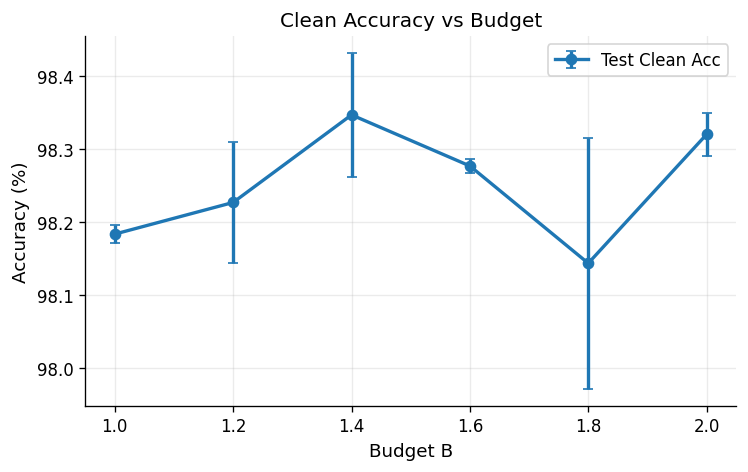

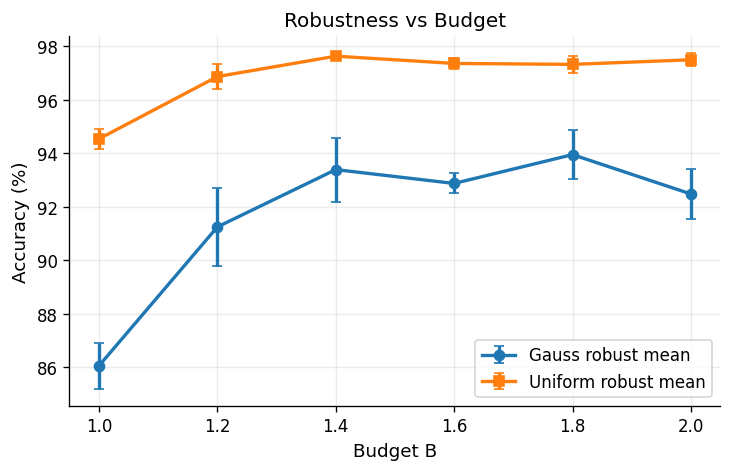

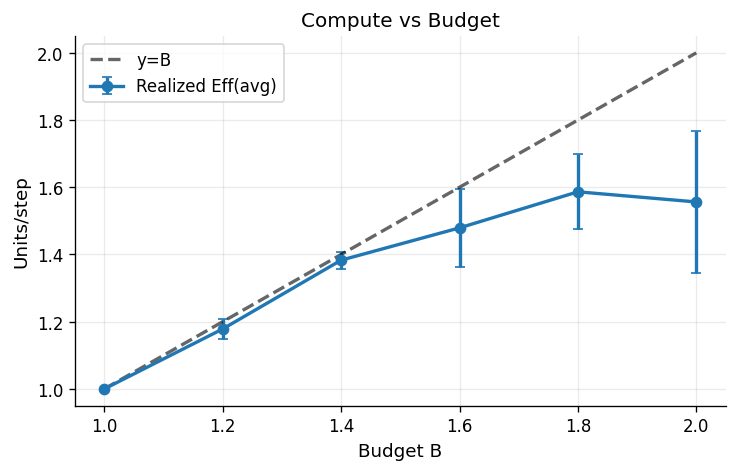

In [1]:
# =============================================================================
# FULL CODE: Budget Sweep for Controller v2 (Primal–Dual + Hard Budget Projection)
# Budgets: B = [1.0, 1.2, 1.4, 1.6, 1.8, 2.0]
#
# What you get:
#  - Per-run results saved to CSV:  ./sweep_out_controller_v2/results.csv
#  - Summary SVG plots:
#      ./sweep_out_controller_v2/fig_sweep_clean_vs_B.svg
#      ./sweep_out_controller_v2/fig_sweep_robust_vs_B.svg
#      ./sweep_out_controller_v2/fig_sweep_eff_vs_B.svg
#  - Shows plots at the end (plt.show()).
#
# Notes:
#  - Hard budget is enforced "in expectation" via p_sam <= (B-1). Realized per-epoch
#    compute can fluctuate due to stochastic sampling.
#  - Data split is fixed by SPLIT_SEED for fair comparison across budgets/seeds.
# =============================================================================

import os
import csv
import time
import copy
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt


# ----------------------------
# Plot helpers
# ----------------------------
def set_pub_style():
    plt.rcParams.update({
        "figure.dpi": 120,
        "savefig.dpi": 120,
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "lines.linewidth": 2.0,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
    })


def save_svg(fig, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    fig.tight_layout()
    fig.savefig(path, format="svg", bbox_inches="tight")
    plt.close(fig)


def mean_std(vals):
    v = np.array(vals, dtype=np.float64)
    return float(v.mean()), float(v.std(ddof=0))


# ----------------------------
# Data preload (MNIST -> GPU/CPU once)
# ----------------------------
def preload_mnist_to_device(device, split_seed=42, val_ratio=0.1):
    import torchvision.transforms as transforms
    from torchvision.datasets import MNIST
    from torch.utils.data import DataLoader, random_split

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x.view(-1))
    ])

    full_train = MNIST(root="./data", train=True, download=True, transform=transform)
    test_set   = MNIST(root="./data", train=False, download=True, transform=transform)

    n_total = len(full_train)
    n_val = int(val_ratio * n_total)
    n_train = n_total - n_val

    train_set, val_set = random_split(
        full_train, [n_train, n_val],
        generator=torch.Generator().manual_seed(split_seed)
    )

    def _preload(dataset):
        loader = DataLoader(dataset, batch_size=256, shuffle=False, num_workers=0)
        xs, ys = [], []
        for x, y in loader:
            xs.append(x)
            ys.append(y)
        x = torch.cat(xs).to(device)
        y = torch.cat(ys).to(device)
        return x, y

    print("[DATA] Preloading MNIST to device ...")
    train_x, train_y = _preload(train_set)
    val_x, val_y     = _preload(val_set)
    test_x, test_y   = _preload(test_set)
    print(f"[DATA] Train {len(train_x)}, Val {len(val_x)}, Test {len(test_x)}")
    return train_x, train_y, val_x, val_y, test_x, test_y


# =============================================================================
# Controller v2 training (single run) parameterized by budget B and seed
# =============================================================================
def train_controller_v2_one_run(
    *,
    BUDGET_B: float,
    SEED: int,
    device,
    train_data, train_targets,
    val_data, val_targets,
    test_data, test_targets,
    NOISE_LEVELS,
    # constraints
    TARGET_CLEAN=98.45,
    TARGET_ROBUST=92.57,
    # schedule
    MAX_EPOCHS=100,
    BATCH=512,
    PHASE_SWITCH_EPOCH=15,
    # early stopping
    PATIENCE=20,
    MIN_EPOCHS_BEFORE_STOP=25,
    MIN_PHASE2_EPOCHS=15,
    # hyperparams
    RHO=1.0,
    SIGMA_START=0.003,
    SIGMA_END=0.010,
    MIX_UNIFORM_PROB=0.25,
    TAU=0.7,
    ETA_LAMBDA=0.08,
    VIOL_BETA=0.9,
    LAMBDA_MAX=20.0,
    # EMA
    USE_EMA=True,
    EMA_DECAY=0.9995,
    # unified score weights
    LAMBDA_CLEAN_SCORE=0.08,
    PEN_CLEAN=6.0,
    PEN_GAUSS=12.0,
    PEN_UNIF=3.0,
    # logging
    PRINT_EVERY=0,   # 0 = no periodic prints; else print each N epochs
):
    # reproducibility
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    # budget cap on p_sam
    P_SAM_MAX = max(0.0, min(1.0, BUDGET_B - 1.0))  # E[units]=1+p_sam <= B

    # ----------------------------
    # Model
    # ----------------------------
    class SimpleMLP(nn.Module):
        def __init__(self):
            super().__init__()
            self.fc1 = nn.Linear(784, 512)
            self.fc2 = nn.Linear(512, 10)
            self.relu = nn.ReLU()
        def forward(self, x):
            return self.fc2(self.relu(self.fc1(x)))

    # ----------------------------
    # EMA
    # ----------------------------
    class EMA:
        def __init__(self, model, decay=0.9995):
            self.decay = decay
            self.shadow = {k: v.detach().clone() for k, v in model.state_dict().items()}
        @torch.no_grad()
        def update(self, model):
            msd = model.state_dict()
            for k in self.shadow:
                self.shadow[k].mul_(self.decay).add_(msd[k], alpha=(1.0 - self.decay))
        def state_dict(self):
            return self.shadow

    # ----------------------------
    # SAM global-L2
    # ----------------------------
    class GlobalSAM:
        def __init__(self, optimizer, rho=0.05, eps=1e-12):
            self.opt = optimizer
            self.rho = rho
            self.eps = eps
            self._backup = None

        @torch.no_grad()
        def _grad_norm(self):
            sq = None
            for group in self.opt.param_groups:
                for p in group["params"]:
                    if p.grad is None:
                        continue
                    g2 = (p.grad ** 2).sum()
                    sq = g2 if sq is None else (sq + g2)
            if sq is None:
                for group in self.opt.param_groups:
                    for p in group["params"]:
                        return torch.tensor(0.0, device=p.device)
                return torch.tensor(0.0)
            return torch.sqrt(sq + self.eps)

        @torch.no_grad()
        def _backup_params(self):
            self._backup = []
            for group in self.opt.param_groups:
                for p in group["params"]:
                    if p.grad is not None:
                        self._backup.append(p.detach().clone())

        @torch.no_grad()
        def _restore_params(self):
            idx = 0
            for group in self.opt.param_groups:
                for p in group["params"]:
                    if p.grad is not None:
                        p.copy_(self._backup[idx])
                        idx += 1
            self._backup = None

        def step(self, model, x, y, criterion):
            self.opt.zero_grad(set_to_none=True)
            loss = criterion(model(x), y)
            loss.backward()

            gnorm = self._grad_norm()
            if float(gnorm.detach().cpu()) == 0.0:
                self.opt.step()
                return float(loss.detach().cpu())

            scale = self.rho / (gnorm + self.eps)

            self._backup_params()
            with torch.no_grad():
                for group in self.opt.param_groups:
                    for p in group["params"]:
                        if p.grad is None:
                            continue
                        p.add_(p.grad * scale)

            self.opt.zero_grad(set_to_none=True)
            loss2 = criterion(model(x), y)
            loss2.backward()

            self._restore_params()
            self.opt.step()
            return float(loss2.detach().cpu())

    # ----------------------------
    # MixRWP (mixture noise + RMS scaling)
    # ----------------------------
    class MixRWP:
        def __init__(self, optimizer, sigma=0.005, mix_uniform_prob=0.25, perturb_bias=False, eps=1e-12):
            self.opt = optimizer
            self.sigma = sigma
            self.mix_uniform_prob = mix_uniform_prob
            self.perturb_bias = perturb_bias
            self.eps = eps

        def _scaled_noise(self, p: torch.Tensor):
            scale = (p.detach().norm(p=2) / (p.numel() ** 0.5 + self.eps)) + self.eps
            if np.random.random() < self.mix_uniform_prob:
                z = (torch.rand_like(p) * 2.0 - 1.0)
            else:
                z = torch.randn_like(p)
            return z * (self.sigma * scale)

        def step(self, model, x, y, criterion):
            params, backups = [], []
            with torch.no_grad():
                for name, p in model.named_parameters():
                    if not p.requires_grad:
                        continue
                    if (not self.perturb_bias) and ("bias" in name):
                        continue
                    params.append(p)
                    backups.append(p.detach().clone())
                    p.add_(self._scaled_noise(p))

            self.opt.zero_grad(set_to_none=True)
            loss = criterion(model(x), y)
            loss.backward()

            with torch.no_grad():
                for p, w0 in zip(params, backups):
                    p.copy_(w0)

            self.opt.step()
            return float(loss.detach().cpu())

    # ----------------------------
    # Eval helpers
    # ----------------------------
    @torch.no_grad()
    def eval_acc(model, data, targets, batch=2048):
        model.eval()
        correct = 0
        total = 0
        for i in range(0, len(data), batch):
            x = data[i:i+batch]
            y = targets[i:i+batch]
            out = model(x)
            pred = out.argmax(dim=1)
            correct += int((pred == y).sum().item())
            total += y.size(0)
        return 100.0 * correct / total

    @torch.no_grad()
    def robustness_curve(model, data, targets, noise_levels, mode="gauss"):
        base_state = copy.deepcopy(model.state_dict())
        out = {}
        for s in noise_levels:
            # apply weight noise
            for name, p in model.named_parameters():
                if "weight" in name:
                    if mode == "gauss":
                        p.add_(torch.randn_like(p) * s)
                    elif mode == "uniform":
                        p.add_((torch.rand_like(p) * 2.0 - 1.0) * s)
                    else:
                        raise ValueError("mode must be gauss/uniform")
            out[s] = eval_acc(model, data, targets)
            model.load_state_dict(base_state)
        return out

    def robust_mean_from_curve(curve, include_sigma0=True):
        ks = sorted(curve.keys())
        if not include_sigma0:
            ks = [k for k in ks if k > 0]
        if len(ks) == 0:
            return float("nan")
        return float(np.mean([curve[k] for k in ks]))

    def unified_val_score(val_clean, val_gauss_mean, val_unif_mean):
        overall = 0.5 * (val_gauss_mean + val_unif_mean)
        pc = max(0.0, TARGET_CLEAN - val_clean)
        pg = max(0.0, TARGET_ROBUST - val_gauss_mean)
        pu = max(0.0, TARGET_ROBUST - val_unif_mean)
        return overall + LAMBDA_CLEAN_SCORE * val_clean - PEN_CLEAN*pc - PEN_GAUSS*pg - PEN_UNIF*pu

    # ----------------------------
    # Policy helpers
    # ----------------------------
    def softmax3(a, b, c, tau=1.0):
        x = np.array([a, b, c], dtype=np.float64) / max(1e-9, tau)
        x = x - x.max()
        e = np.exp(x)
        p = e / e.sum()
        return float(p[0]), float(p[1]), float(p[2])

    def project_budget(p_sgd, p_rwp, p_sam, p_sam_max):
        p_sam_new = min(p_sam, p_sam_max)
        leftover = 1.0 - p_sam_new
        base = p_sgd + p_rwp
        if base <= 1e-12:
            p_sgd_new = leftover * 0.5
            p_rwp_new = leftover * 0.5
        else:
            p_sgd_new = leftover * (p_sgd / base)
            p_rwp_new = leftover * (p_rwp / base)
        return p_sgd_new, p_rwp_new, p_sam_new

    # ----------------------------
    # Train setup
    # ----------------------------
    num_batches = len(train_data) // BATCH

    model = SimpleMLP().to(device)
    criterion = nn.CrossEntropyLoss()
    opt = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=1e-4)

    sam = GlobalSAM(opt, rho=RHO)
    rwp = MixRWP(opt, sigma=SIGMA_START, mix_uniform_prob=MIX_UNIFORM_PROB, perturb_bias=False)
    ema = EMA(model, decay=EMA_DECAY) if USE_EMA else None

    lam_clean = 0.0
    lam_gauss = 0.0
    lam_unif  = 0.0

    v_clean_ema = 0.0
    v_gauss_ema = 0.0
    v_unif_ema  = 0.0

    # early stopping
    best_score = None
    best_state = None
    best_epoch = None
    best_tag = None

    units_total = 0.0
    steps_total = 0
    counts_total = {"SGD": 0, "RWP": 0, "SAM": 0}

    patience_cnt = 0

    # ----------------------------
    # Training loop
    # ----------------------------
    for epoch in range(MAX_EPOCHS):
        # cosine LR
        lr = 0.1 * 0.5 * (1 + np.cos(np.pi * epoch / MAX_EPOCHS))
        for pg in opt.param_groups:
            pg["lr"] = lr

        # sigma schedule
        t_sig = epoch / max(1, MAX_EPOCHS - 1)
        rwp.sigma = float(SIGMA_START + (SIGMA_END - SIGMA_START) * t_sig)

        model.train()
        indices = torch.randperm(len(train_data), device=device)

        e_counts = {"SGD": 0, "RWP": 0, "SAM": 0}
        e_units = 0.0

        p_sgd_sum = 0.0
        p_rwp_sum = 0.0
        p_sam_sum = 0.0

        for b in range(num_batches):
            bi = indices[b*BATCH:(b+1)*BATCH]
            x = train_data[bi]
            y = train_targets[bi]

            # controller scores (same as your v2)
            score_sgd = 0.0
            score_rwp = lam_gauss + lam_unif
            score_sam = lam_clean

            p_sgd, p_rwp, p_sam = softmax3(score_sgd, score_rwp, score_sam, tau=TAU)

            # phase switch: disable RWP initially
            if epoch < PHASE_SWITCH_EPOCH:
                base = p_sgd + p_sam
                p_sgd, p_rwp, p_sam = p_sgd / base, 0.0, p_sam / base

            # hard projection on p_sam
            p_sgd, p_rwp, p_sam = project_budget(p_sgd, p_rwp, p_sam, P_SAM_MAX)

            # accumulate expected probs (after projection)
            p_sgd_sum += p_sgd
            p_rwp_sum += p_rwp
            p_sam_sum += p_sam

            u = np.random.random()
            if u < p_sgd:
                opt.zero_grad(set_to_none=True)
                loss = criterion(model(x), y)
                loss.backward()
                opt.step()
                units = 1.0
                counts_total["SGD"] += 1; e_counts["SGD"] += 1
            elif u < p_sgd + p_rwp:
                _ = rwp.step(model, x, y, criterion)
                units = 1.0
                counts_total["RWP"] += 1; e_counts["RWP"] += 1
            else:
                _ = sam.step(model, x, y, criterion)
                units = 2.0
                counts_total["SAM"] += 1; e_counts["SAM"] += 1

            steps_total += 1
            units_total += units
            e_units += units

            if USE_EMA:
                ema.update(model)

        # --- validation: choose RAW vs EMA for scoring ---
        raw_state = copy.deepcopy(model.state_dict())
        ema_state = ema.state_dict() if USE_EMA else None

        # RAW
        val_clean_raw = eval_acc(model, val_data, val_targets)
        curve_g_raw = robustness_curve(model, val_data, val_targets, NOISE_LEVELS, mode="gauss")
        curve_u_raw = robustness_curve(model, val_data, val_targets, NOISE_LEVELS, mode="uniform")
        val_gauss_raw = robust_mean_from_curve(curve_g_raw, include_sigma0=True)
        val_unif_raw  = robust_mean_from_curve(curve_u_raw, include_sigma0=True)
        score_raw = unified_val_score(val_clean_raw, val_gauss_raw, val_unif_raw)

        # EMA
        if USE_EMA:
            model.load_state_dict(ema_state)
            val_clean_ema = eval_acc(model, val_data, val_targets)
            curve_g_ema = robustness_curve(model, val_data, val_targets, NOISE_LEVELS, mode="gauss")
            curve_u_ema = robustness_curve(model, val_data, val_targets, NOISE_LEVELS, mode="uniform")
            val_gauss_ema = robust_mean_from_curve(curve_g_ema, include_sigma0=True)
            val_unif_ema  = robust_mean_from_curve(curve_u_ema, include_sigma0=True)
            score_ema = unified_val_score(val_clean_ema, val_gauss_ema, val_unif_ema)
        else:
            val_clean_ema = val_gauss_ema = val_unif_ema = -1e9
            score_ema = -1e9

        # choose checkpoint metric
        if USE_EMA and (score_ema >= score_raw):
            chosen_state = ema_state
            chosen_tag = "EMA"
            val_clean, val_gauss, val_unif, score = val_clean_ema, val_gauss_ema, val_unif_ema, score_ema
        else:
            chosen_state = raw_state
            chosen_tag = "RAW"
            val_clean, val_gauss, val_unif, score = val_clean_raw, val_gauss_raw, val_unif_raw, score_raw

        # restore RAW for continued training
        model.load_state_dict(raw_state)

        # --- primal/dual updates ---
        v_clean = max(0.0, TARGET_CLEAN - val_clean)
        v_gauss = max(0.0, TARGET_ROBUST - val_gauss)
        v_unif  = max(0.0, TARGET_ROBUST - val_unif)

        v_clean_ema = VIOL_BETA * v_clean_ema + (1.0 - VIOL_BETA) * v_clean
        v_gauss_ema = VIOL_BETA * v_gauss_ema + (1.0 - VIOL_BETA) * v_gauss
        v_unif_ema  = VIOL_BETA * v_unif_ema  + (1.0 - VIOL_BETA) * v_unif

        lam_clean = float(np.clip(lam_clean + ETA_LAMBDA * v_clean_ema, 0.0, LAMBDA_MAX))
        lam_gauss = float(np.clip(lam_gauss + ETA_LAMBDA * v_gauss_ema, 0.0, LAMBDA_MAX))
        lam_unif  = float(np.clip(lam_unif  + ETA_LAMBDA * v_unif_ema,  0.0, LAMBDA_MAX))

        # early stopping (patience) on unified score
        if best_score is None or score > best_score + 1e-6:
            best_score = score
            best_state = copy.deepcopy(chosen_state)
            best_epoch = epoch + 1
            best_tag = chosen_tag
            patience_cnt = 0
        else:
            patience_cnt += 1

        allow_stop = (epoch + 1) >= MIN_EPOCHS_BEFORE_STOP and (epoch + 1) >= (PHASE_SWITCH_EPOCH + MIN_PHASE2_EPOCHS)
        if allow_stop and (patience_cnt >= PATIENCE):
            break

        if PRINT_EVERY and ((epoch + 1) % PRINT_EVERY == 0):
            eff_epoch_expected = 1.0 + (p_sam_sum / max(1, num_batches))
            eff_epoch_realized = e_units / max(1, num_batches)
            print(f"[B={BUDGET_B:.1f} seed={SEED}] epoch {epoch+1:3d} "
                  f"| val_clean {val_clean:6.2f} val_g {val_gauss:6.2f} val_u {val_unif:6.2f} "
                  f"| score {score:8.3f} ({chosen_tag}) "
                  f"| Eff(exp/real) {eff_epoch_expected:.2f}/{eff_epoch_realized:.2f}")

    # load best checkpoint
    if best_state is None:
        best_state = ema.state_dict() if USE_EMA else model.state_dict()
        best_epoch = MAX_EPOCHS
        best_tag = "EMA" if USE_EMA else "RAW"

    model.load_state_dict(best_state)

    # test metrics
    def eff_avg_realized():
        return float(units_total / max(1, steps_total))

    test_clean = eval_acc(model, test_data, test_targets)
    curve_g_test = robustness_curve(model, test_data, test_targets, NOISE_LEVELS, mode="gauss")
    curve_u_test = robustness_curve(model, test_data, test_targets, NOISE_LEVELS, mode="uniform")
    test_gauss_mean = robust_mean_from_curve(curve_g_test, include_sigma0=True)
    test_unif_mean  = robust_mean_from_curve(curve_u_test, include_sigma0=True)
    test_overall = 0.5 * (test_gauss_mean + test_unif_mean)

    # robustness drops at specific points if present
    drop_01 = None
    drop_02 = None
    if 0.0 in curve_g_test and 0.1 in curve_g_test:
        drop_01 = float(curve_g_test[0.0] - curve_g_test[0.1])
    if 0.0 in curve_g_test and 0.2 in curve_g_test:
        drop_02 = float(curve_g_test[0.0] - curve_g_test[0.2])

    # realized action fractions
    total_steps = max(1, sum(counts_total.values()))
    frac_sam = float(counts_total["SAM"] / total_steps)
    frac_rwp = float(counts_total["RWP"] / total_steps)
    frac_sgd = float(counts_total["SGD"] / total_steps)

    out = {
        "budget_B": float(BUDGET_B),
        "p_sam_max": float(P_SAM_MAX),
        "seed": int(SEED),
        "best_epoch": int(best_epoch),
        "best_tag": str(best_tag),
        "test_clean": float(test_clean),
        "test_gauss_mean": float(test_gauss_mean),
        "test_unif_mean": float(test_unif_mean),
        "test_overall": float(test_overall),
        "drop_at_01_gauss": float(drop_01) if drop_01 is not None else float("nan"),
        "drop_at_02_gauss": float(drop_02) if drop_02 is not None else float("nan"),
        "eff_avg_realized": eff_avg_realized(),
        "frac_sgd": frac_sgd,
        "frac_rwp": frac_rwp,
        "frac_sam": frac_sam,
        "counts_sgd": int(counts_total["SGD"]),
        "counts_rwp": int(counts_total["RWP"]),
        "counts_sam": int(counts_total["SAM"]),
    }
    return out


# =============================================================================
# Sweep runner
# =============================================================================
def run_sweep():
    # ----- CONFIG SWEEP -----
    B_LIST = [1.0, 1.2, 1.4, 1.6, 1.8, 2.0]
    SEEDS  = [42, 43, 44]   # change to [42] if you want faster

    NOISE_LEVELS = [0.0, 0.01, 0.02, 0.04, 0.06, 0.08, 0.1, 0.2]

    OUT_DIR = "./sweep_out_controller_v2"
    os.makedirs(OUT_DIR, exist_ok=True)
    CSV_PATH = os.path.join(OUT_DIR, "results.csv")

    # training config (keep same across budgets)
    MAX_EPOCHS = 100
    BATCH = 512
    PHASE_SWITCH_EPOCH = 15
    PATIENCE = 20
    MIN_EPOCHS_BEFORE_STOP = 25
    MIN_PHASE2_EPOCHS = 15

    # device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[SYS] device = {device}")

    # preload data once for fairness + speed
    SPLIT_SEED = 42
    train_data, train_targets, val_data, val_targets, test_data, test_targets = preload_mnist_to_device(
        device=device,
        split_seed=SPLIT_SEED,
        val_ratio=0.1
    )

    results = []
    t_all0 = time.perf_counter()

    for B in B_LIST:
        for sd in SEEDS:
            print("\n" + "-" * 80)
            print(f"[RUN] Budget B={B:.1f} | seed={sd}")
            print("-" * 80)

            out = train_controller_v2_one_run(
                BUDGET_B=B,
                SEED=sd,
                device=device,
                train_data=train_data, train_targets=train_targets,
                val_data=val_data, val_targets=val_targets,
                test_data=test_data, test_targets=test_targets,
                NOISE_LEVELS=NOISE_LEVELS,
                MAX_EPOCHS=MAX_EPOCHS,
                BATCH=BATCH,
                PHASE_SWITCH_EPOCH=PHASE_SWITCH_EPOCH,
                PATIENCE=PATIENCE,
                MIN_EPOCHS_BEFORE_STOP=MIN_EPOCHS_BEFORE_STOP,
                MIN_PHASE2_EPOCHS=MIN_PHASE2_EPOCHS,
                PRINT_EVERY=0,  # set to 5 if you want periodic per-epoch prints
            )
            results.append(out)

            print(f"[DONE] B={B:.1f} seed={sd} | "
                  f"clean={out['test_clean']:.2f} "
                  f"gauss_mean={out['test_gauss_mean']:.2f} "
                  f"unif_mean={out['test_unif_mean']:.2f} "
                  f"eff_avg={out['eff_avg_realized']:.2f} "
                  f"frac_sam={out['frac_sam']:.3f}")

    t_all = time.perf_counter() - t_all0
    print(f"\n[SWEEP DONE] total time = {t_all:.1f}s | runs = {len(results)}")

    # write CSV
    fieldnames = list(results[0].keys()) if results else []
    with open(CSV_PATH, "w", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=fieldnames)
        w.writeheader()
        for r in results:
            w.writerow(r)
    print(f"[CSV] Saved: {os.path.abspath(CSV_PATH)}")

    # aggregate per B (mean ± std over seeds)
    agg = {}
    for B in B_LIST:
        rs = [r for r in results if abs(r["budget_B"] - B) < 1e-9]
        agg[B] = {
            "clean": [r["test_clean"] for r in rs],
            "gmean": [r["test_gauss_mean"] for r in rs],
            "umean": [r["test_unif_mean"] for r in rs],
            "overall": [r["test_overall"] for r in rs],
            "eff": [r["eff_avg_realized"] for r in rs],
            "frac_sam": [r["frac_sam"] for r in rs],
            "drop01": [r["drop_at_01_gauss"] for r in rs],
        }

    # plots
    set_pub_style()

    Bs = np.array(B_LIST, dtype=np.float64)

    clean_m = np.array([mean_std(agg[B]["clean"])[0] for B in B_LIST])
    clean_s = np.array([mean_std(agg[B]["clean"])[1] for B in B_LIST])

    g_m = np.array([mean_std(agg[B]["gmean"])[0] for B in B_LIST])
    g_s = np.array([mean_std(agg[B]["gmean"])[1] for B in B_LIST])

    u_m = np.array([mean_std(agg[B]["umean"])[0] for B in B_LIST])
    u_s = np.array([mean_std(agg[B]["umean"])[1] for B in B_LIST])

    eff_m = np.array([mean_std(agg[B]["eff"])[0] for B in B_LIST])
    eff_s = np.array([mean_std(agg[B]["eff"])[1] for B in B_LIST])

    # Fig: Clean vs B
    fig = plt.figure(figsize=(7.0, 4.0))
    plt.errorbar(Bs, clean_m, yerr=clean_s, marker="o", capsize=3, label="Test Clean Acc")
    plt.xlabel("Budget B")
    plt.ylabel("Accuracy (%)")
    plt.title("Clean Accuracy vs Compute Budget")
    plt.legend(loc="best")
    save_svg(fig, os.path.join(OUT_DIR, "fig_sweep_clean_vs_B.svg"))

    # Fig: Robust vs B (Gaussian & Uniform)
    fig = plt.figure(figsize=(7.0, 4.0))
    plt.errorbar(Bs, g_m, yerr=g_s, marker="o", capsize=3, label="Gauss robust mean", color="#1f77b4")
    plt.errorbar(Bs, u_m, yerr=u_s, marker="s", capsize=3, label="Uniform robust mean", color="#ff7f0e")
    plt.xlabel("Budget B")
    plt.ylabel("Accuracy (%)")
    plt.title("Robustness vs Compute Budget (mean over noise levels)")
    plt.legend(loc="best")
    save_svg(fig, os.path.join(OUT_DIR, "fig_sweep_robust_vs_B.svg"))

    # Fig: Eff vs B
    fig = plt.figure(figsize=(7.0, 4.0))
    plt.errorbar(Bs, eff_m, yerr=eff_s, marker="o", capsize=3, label="Realized Eff(avg)")
    plt.plot(Bs, Bs, linestyle="--", color="black", alpha=0.6, label="y = B (reference)")
    plt.xlabel("Budget B")
    plt.ylabel("Compute (units/step)")
    plt.title("Realized Compute vs Budget")
    plt.legend(loc="best")
    save_svg(fig, os.path.join(OUT_DIR, "fig_sweep_eff_vs_B.svg"))

    print(f"[SVG] Saved plots to: {os.path.abspath(OUT_DIR)}")

    # show summary plots at end (opens GUI windows if backend supports it)
    # (In headless terminals, figures may not show; SVG files are still saved.)
    # To show here, re-create minimal display versions:
    fig1 = plt.figure(figsize=(7.0, 4.0))
    plt.errorbar(Bs, clean_m, yerr=clean_s, marker="o", capsize=3, label="Test Clean Acc")
    plt.xlabel("Budget B"); plt.ylabel("Accuracy (%)"); plt.title("Clean Accuracy vs Budget"); plt.legend()

    fig2 = plt.figure(figsize=(7.0, 4.0))
    plt.errorbar(Bs, g_m, yerr=g_s, marker="o", capsize=3, label="Gauss robust mean")
    plt.errorbar(Bs, u_m, yerr=u_s, marker="s", capsize=3, label="Uniform robust mean")
    plt.xlabel("Budget B"); plt.ylabel("Accuracy (%)"); plt.title("Robustness vs Budget"); plt.legend()

    fig3 = plt.figure(figsize=(7.0, 4.0))
    plt.errorbar(Bs, eff_m, yerr=eff_s, marker="o", capsize=3, label="Realized Eff(avg)")
    plt.plot(Bs, Bs, linestyle="--", color="black", alpha=0.6, label="y=B")
    plt.xlabel("Budget B"); plt.ylabel("Units/step"); plt.title("Compute vs Budget"); plt.legend()

    plt.show()


if __name__ == "__main__":
    run_sweep()


In [1]:
# =============================================================================
# CONTROLLER v2 (PRIMAL–DUAL + HARD BUDGET PROJECTION) + SVG EXPORT + SHOW
# - Train MLP 784-512-10 on MNIST (PyTorch)
# - Logs: budget (expected vs realized), dual/violations, policy, train/val metrics
# - Saves ALL figures as .svg and displays them when finished
#
# Output folder (SVG): ./figs_svg_controller_v2/
# =============================================================================

import os
import time
import copy
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt


# ----------------------------
# Plot helpers
# ----------------------------
def set_pub_style():
    plt.rcParams.update({
        "figure.dpi": 120,
        "savefig.dpi": 120,
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "lines.linewidth": 2.0,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
    })


def save_svg(fig, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    fig.tight_layout()
    fig.savefig(path, format="svg", bbox_inches="tight")


def plot_and_save_all_svgs(logs, robustness_gauss, robustness_unif, out_dir, BUDGET_B, P_SAM_MAX, show=True):
    set_pub_style()
    os.makedirs(out_dir, exist_ok=True)

    ep = np.array(logs["epoch"], dtype=np.int32)

    # -------------------------
    # FIG 1: Budget expected vs realized
    # -------------------------
    fig = plt.figure(figsize=(7.2, 4.2))
    plt.plot(ep, logs["eff_epoch_expected"], label="Expected Eff (1 + mean p_sam)", color="#1f77b4")
    plt.plot(ep, logs["eff_epoch_realized"], label="Realized Eff (units/batch)", color="#ff7f0e")
    plt.axhline(BUDGET_B, linestyle="--", color="black", alpha=0.8, label=f"Budget B={BUDGET_B:.2f}")
    plt.xlabel("Epoch")
    plt.ylabel("Compute (units/step)")
    plt.title("Hard Budget Projection: Expected vs Realized Compute")
    plt.legend(loc="best")
    save_svg(fig, os.path.join(out_dir, "fig01_budget_expected_vs_realized.svg"))

    # -------------------------
    # FIG 2: Violations(EMA) + Dual variables
    # -------------------------
    fig, ax = plt.subplots(2, 1, figsize=(7.2, 6.2), sharex=True)

    ax[0].plot(ep, logs["v_clean_ema"], label="v_clean (EMA)", color="#2ca02c")
    ax[0].plot(ep, logs["v_gauss_ema"], label="v_gauss (EMA)", color="#d62728")
    ax[0].plot(ep, logs["v_unif_ema"],  label="v_unif (EMA)",  color="#9467bd")
    ax[0].set_ylabel("Violation (EMA)")
    ax[0].set_title("Primal–Dual: Smoothed Violations and Dual Ascent")
    ax[0].legend(loc="best")

    ax[1].plot(ep, logs["lam_clean"], label="λ_clean", color="#2ca02c")
    ax[1].plot(ep, logs["lam_gauss"], label="λ_gauss", color="#d62728")
    ax[1].plot(ep, logs["lam_unif"],  label="λ_unif",  color="#9467bd")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Dual variable λ")
    ax[1].legend(loc="best")

    save_svg(fig, os.path.join(out_dir, "fig02_dual_violations.svg"))

    # -------------------------
    # FIG 3: Policy probabilities (expected) + realized action fractions
    # -------------------------
    fig, ax = plt.subplots(2, 1, figsize=(7.2, 6.2), sharex=True)

    ax[0].plot(ep, logs["p_sgd_mean"], label="mean p(SGD)", color="#1f77b4")
    ax[0].plot(ep, logs["p_rwp_mean"], label="mean p(RWP)", color="#ff7f0e")
    ax[0].plot(ep, logs["p_sam_mean"], label="mean p(SAM)", color="#d62728")
    ax[0].axhline(P_SAM_MAX, linestyle="--", color="#d62728", alpha=0.7, label=f"p_sam cap={P_SAM_MAX:.2f}")
    ax[0].set_ylabel("Expected probability")
    ax[0].set_title("Controller Scheduling: Expected Policy vs Realized Mix")
    ax[0].legend(loc="best")

    ax[1].plot(ep, logs["frac_sgd"], label="realized frac(SGD)", color="#1f77b4", linestyle=":")
    ax[1].plot(ep, logs["frac_rwp"], label="realized frac(RWP)", color="#ff7f0e", linestyle=":")
    ax[1].plot(ep, logs["frac_sam"], label="realized frac(SAM)", color="#d62728", linestyle=":")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Realized fraction")
    ax[1].legend(loc="best")

    save_svg(fig, os.path.join(out_dir, "fig03_policy_expected_vs_realized.svg"))

    # -------------------------
    # FIG 4: Train/Val metrics over epochs
    # -------------------------
    fig = plt.figure(figsize=(7.2, 4.6))
    plt.plot(ep, logs["train_acc"], label="Train Acc", color="#17becf")
    plt.plot(ep, logs["val_clean"], label="Val Clean", color="#1f77b4")
    plt.plot(ep, logs["val_gauss"], label="Val GaussMean", color="#d62728")
    plt.plot(ep, logs["val_unif"],  label="Val UnifMean",  color="#9467bd")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title("Training & Validation Metrics")
    plt.legend(loc="best")
    save_svg(fig, os.path.join(out_dir, "fig04_train_val_metrics.svg"))

    # -------------------------
    # FIG 5: Robustness curve on TEST (weight noise)
    # -------------------------
    fig = plt.figure(figsize=(7.2, 4.2))
    if robustness_gauss is not None:
        xs = sorted(robustness_gauss.keys())
        ys = [robustness_gauss[x] for x in xs]
        plt.plot(xs, ys, marker="o", label="Gaussian weight noise", color="#1f77b4")
    if robustness_unif is not None:
        xs = sorted(robustness_unif.keys())
        ys = [robustness_unif[x] for x in xs]
        plt.plot(xs, ys, marker="s", label="Uniform weight noise", color="#ff7f0e")
    plt.xlabel("Noise level σ")
    plt.ylabel("Test accuracy (%)")
    plt.title("Robustness Curve (Test)")
    plt.legend(loc="best")
    save_svg(fig, os.path.join(out_dir, "fig05_robustness_curve_test.svg"))

    print(f"\n[SVG] Saved all figures to: {os.path.abspath(out_dir)}")

    if show:
        plt.show()


# =============================================================================
# Main training
# =============================================================================
def train_controller_v2_with_figures():
    # ----------------------------
    # CONFIG (EDIT HERE)
    # ----------------------------
    SEED = 42

    TARGET_CLEAN  = 98.45
    TARGET_ROBUST = 92.57

    NOISE_LEVELS = [0.0, 0.01, 0.02, 0.04, 0.06, 0.08, 0.1, 0.2]

    # Budget: E[units] = 1 + p_sam <= B  => p_sam <= B-1
    BUDGET_B = 1.50
    P_SAM_MAX = max(0.0, min(1.0, BUDGET_B - 1.0))

    MAX_EPOCHS = 100
    BATCH = 512
    PHASE_SWITCH_EPOCH = 15

    PATIENCE = 20
    MIN_EPOCHS_BEFORE_STOP = 25
    MIN_PHASE2_EPOCHS = 15

    # SAM/RWP hyperparams
    RHO = 1.0
    SIGMA_START = 0.003
    SIGMA_END   = 0.010
    MIX_UNIFORM_PROB = 0.25

    # Policy temperature
    TAU = 0.7

    # Dual update / smoothing
    ETA_LAMBDA = 0.08
    VIOL_BETA  = 0.9
    LAMBDA_MAX = 20.0

    # EMA weights
    USE_EMA = True
    EMA_DECAY = 0.9995

    # Unified score weights
    LAMBDA_CLEAN_SCORE = 0.08
    PEN_CLEAN = 6.0
    PEN_GAUSS = 12.0
    PEN_UNIF  = 3.0

    # ----------------------------
    # Seed / device
    # ----------------------------
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[SYS] device = {device}")

    # ----------------------------
    # Model
    # ----------------------------
    class SimpleMLP(nn.Module):
        def __init__(self):
            super().__init__()
            self.fc1 = nn.Linear(784, 512)
            self.fc2 = nn.Linear(512, 10)
            self.relu = nn.ReLU()
        def forward(self, x):
            return self.fc2(self.relu(self.fc1(x)))

    # ----------------------------
    # EMA
    # ----------------------------
    class EMA:
        def __init__(self, model, decay=0.9995):
            self.decay = decay
            self.shadow = {k: v.detach().clone() for k, v in model.state_dict().items()}
        @torch.no_grad()
        def update(self, model):
            msd = model.state_dict()
            for k in self.shadow:
                self.shadow[k].mul_(self.decay).add_(msd[k], alpha=(1.0 - self.decay))
        def state_dict(self):
            return self.shadow

    # ----------------------------
    # SAM (global L2)
    # ----------------------------
    class GlobalSAM:
        def __init__(self, optimizer, rho=0.05, eps=1e-12):
            self.opt = optimizer
            self.rho = rho
            self.eps = eps
            self._backup = None

        @torch.no_grad()
        def _grad_norm(self):
            sq = None
            for group in self.opt.param_groups:
                for p in group["params"]:
                    if p.grad is None:
                        continue
                    g2 = (p.grad ** 2).sum()
                    sq = g2 if sq is None else (sq + g2)
            if sq is None:
                # return tensor on proper device
                for group in self.opt.param_groups:
                    for p in group["params"]:
                        return torch.tensor(0.0, device=p.device)
                return torch.tensor(0.0)
            return torch.sqrt(sq + self.eps)

        @torch.no_grad()
        def _backup_params(self):
            self._backup = []
            for group in self.opt.param_groups:
                for p in group["params"]:
                    if p.grad is not None:
                        self._backup.append(p.detach().clone())

        @torch.no_grad()
        def _restore_params(self):
            idx = 0
            for group in self.opt.param_groups:
                for p in group["params"]:
                    if p.grad is not None:
                        p.copy_(self._backup[idx])
                        idx += 1
            self._backup = None

        def step(self, model, x, y, criterion):
            self.opt.zero_grad(set_to_none=True)
            loss = criterion(model(x), y)
            loss.backward()

            gnorm = self._grad_norm()
            if float(gnorm.detach().cpu()) == 0.0:
                self.opt.step()
                return float(loss.detach().cpu())

            scale = self.rho / (gnorm + self.eps)

            self._backup_params()
            with torch.no_grad():
                for group in self.opt.param_groups:
                    for p in group["params"]:
                        if p.grad is None:
                            continue
                        p.add_(p.grad * scale)

            self.opt.zero_grad(set_to_none=True)
            loss2 = criterion(model(x), y)
            loss2.backward()

            self._restore_params()
            self.opt.step()
            return float(loss2.detach().cpu())

    # ----------------------------
    # MixRWP (mixture noise + RMS scaling)
    # ----------------------------
    class MixRWP:
        def __init__(self, optimizer, sigma=0.005, mix_uniform_prob=0.25, perturb_bias=False, eps=1e-12):
            self.opt = optimizer
            self.sigma = sigma
            self.mix_uniform_prob = mix_uniform_prob
            self.perturb_bias = perturb_bias
            self.eps = eps

        def _scaled_noise(self, p: torch.Tensor):
            scale = (p.detach().norm(p=2) / (p.numel() ** 0.5 + self.eps)) + self.eps
            if np.random.random() < self.mix_uniform_prob:
                z = (torch.rand_like(p) * 2.0 - 1.0)
            else:
                z = torch.randn_like(p)
            return z * (self.sigma * scale)

        def step(self, model, x, y, criterion):
            params, backups = [], []
            with torch.no_grad():
                for name, p in model.named_parameters():
                    if not p.requires_grad:
                        continue
                    if (not self.perturb_bias) and ("bias" in name):
                        continue
                    params.append(p)
                    backups.append(p.detach().clone())
                    p.add_(self._scaled_noise(p))

            self.opt.zero_grad(set_to_none=True)
            loss = criterion(model(x), y)
            loss.backward()

            with torch.no_grad():
                for p, w0 in zip(params, backups):
                    p.copy_(w0)

            self.opt.step()
            return float(loss.detach().cpu())

    # ----------------------------
    # Eval helpers
    # ----------------------------
    @torch.no_grad()
    def eval_acc(model, data, targets, batch=2048):
        model.eval()
        correct = 0
        total = 0
        for i in range(0, len(data), batch):
            x = data[i:i+batch]
            y = targets[i:i+batch]
            out = model(x)
            pred = out.argmax(dim=1)
            correct += int((pred == y).sum().item())
            total += y.size(0)
        return 100.0 * correct / total

    @torch.no_grad()
    def eval_weight_noise_curve(model, data, targets, noise_levels, mode="gauss"):
        """Return dict: sigma -> accuracy"""
        base_state = copy.deepcopy(model.state_dict())
        curve = {}
        for s in noise_levels:
            for name, p in model.named_parameters():
                if "weight" in name:
                    if mode == "gauss":
                        p.add_(torch.randn_like(p) * s)
                    elif mode == "uniform":
                        p.add_((torch.rand_like(p) * 2.0 - 1.0) * s)
                    else:
                        raise ValueError("mode must be gauss/uniform")
            curve[float(s)] = eval_acc(model, data, targets)
            model.load_state_dict(base_state)
        return curve

    def curve_mean(curve, include_sigma0=True):
        ks = sorted(curve.keys())
        if not include_sigma0:
            ks = [k for k in ks if k > 0]
        return float(np.mean([curve[k] for k in ks])) if ks else float("nan")

    def unified_val_score(val_clean, val_gauss_mean, val_unif_mean):
        overall = 0.5 * (val_gauss_mean + val_unif_mean)
        pc = max(0.0, TARGET_CLEAN - val_clean)
        pg = max(0.0, TARGET_ROBUST - val_gauss_mean)
        pu = max(0.0, TARGET_ROBUST - val_unif_mean)
        return overall + LAMBDA_CLEAN_SCORE * val_clean - PEN_CLEAN*pc - PEN_GAUSS*pg - PEN_UNIF*pu

    # ----------------------------
    # Policy helpers
    # ----------------------------
    def softmax3(a, b, c, tau=1.0):
        x = np.array([a, b, c], dtype=np.float64) / max(1e-9, tau)
        x = x - x.max()
        e = np.exp(x)
        p = e / e.sum()
        return float(p[0]), float(p[1]), float(p[2])

    def project_budget(p_sgd, p_rwp, p_sam, p_sam_max):
        p_sam_new = min(p_sam, p_sam_max)
        leftover = 1.0 - p_sam_new
        base = p_sgd + p_rwp
        if base <= 1e-12:
            p_sgd_new = leftover * 0.5
            p_rwp_new = leftover * 0.5
        else:
            p_sgd_new = leftover * (p_sgd / base)
            p_rwp_new = leftover * (p_rwp / base)
        return p_sgd_new, p_rwp_new, p_sam_new

    # ----------------------------
    # Data preload (MNIST -> device)
    # ----------------------------
    import torchvision.transforms as transforms
    from torchvision.datasets import MNIST
    from torch.utils.data import DataLoader, random_split

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x.view(-1))
    ])

    full_train = MNIST(root="./data", train=True, download=True, transform=transform)
    test_set   = MNIST(root="./data", train=False, download=True, transform=transform)

    n_total = len(full_train)
    n_val = int(0.1 * n_total)
    n_train = n_total - n_val

    train_set, val_set = random_split(
        full_train, [n_train, n_val],
        generator=torch.Generator().manual_seed(SEED)
    )

    def preload_to_device(dataset):
        loader = DataLoader(dataset, batch_size=256, shuffle=False, num_workers=0)
        xs, ys = [], []
        for x, y in loader:
            xs.append(x)
            ys.append(y)
        return torch.cat(xs).to(device), torch.cat(ys).to(device)

    print("[DATA] Preloading MNIST to device ...")
    train_data, train_targets = preload_to_device(train_set)
    val_data, val_targets     = preload_to_device(val_set)
    test_data, test_targets   = preload_to_device(test_set)
    print(f"[DATA] Train {len(train_data)}, Val {len(val_data)}, Test {len(test_data)}")

    num_batches = len(train_data) // BATCH

    # ----------------------------
    # Build model/optimizer
    # ----------------------------
    model = SimpleMLP().to(device)
    criterion = nn.CrossEntropyLoss()
    opt = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=1e-4)

    sam = GlobalSAM(opt, rho=RHO)
    rwp = MixRWP(opt, sigma=SIGMA_START, mix_uniform_prob=MIX_UNIFORM_PROB, perturb_bias=False)
    ema = EMA(model, decay=EMA_DECAY) if USE_EMA else None

    # Dual variables
    lam_clean = 0.0
    lam_gauss = 0.0
    lam_unif  = 0.0

    # Smoothed violations (EMA)
    v_clean_ema = 0.0
    v_gauss_ema = 0.0
    v_unif_ema  = 0.0

    # Early stopping
    best_score = None
    best_state = None
    best_info  = None
    patience_counter = 0

    # Total counts/compute
    units_total = 0.0
    steps_total = 0
    counts_total = {"SGD": 0, "RWP": 0, "SAM": 0}

    # Logs for plotting
    logs = {
        "epoch": [],
        "train_acc": [],
        "train_loss": [],
        "val_clean": [],
        "val_gauss": [],
        "val_unif": [],
        "score": [],
        "chosen_tag": [],
        "eff_epoch_expected": [],
        "eff_epoch_realized": [],
        "eff_avg": [],
        "p_sgd_mean": [],
        "p_rwp_mean": [],
        "p_sam_mean": [],
        "frac_sgd": [],
        "frac_rwp": [],
        "frac_sam": [],
        "v_clean_ema": [],
        "v_gauss_ema": [],
        "v_unif_ema": [],
        "lam_clean": [],
        "lam_gauss": [],
        "lam_unif": [],
    }

    print("\n" + "="*80)
    print("CONTROLLER v2 START (hard budget cap + dual EMA)")
    print("="*80)
    print(f"Budget B={BUDGET_B:.2f} => p_sam_max={P_SAM_MAX:.2f}")

    for epoch in range(MAX_EPOCHS):
        # cosine lr
        lr = 0.1 * 0.5 * (1 + np.cos(np.pi * epoch / MAX_EPOCHS))
        for pg in opt.param_groups:
            pg["lr"] = lr

        # sigma schedule (linear)
        t_sig = epoch / max(1, MAX_EPOCHS - 1)
        rwp.sigma = float(SIGMA_START + (SIGMA_END - SIGMA_START) * t_sig)

        model.train()
        if device.type == "cuda":
            torch.cuda.synchronize()
        t0 = time.perf_counter()

        correct = 0
        total = 0
        total_loss = 0.0

        indices = torch.randperm(len(train_data), device=device)

        # per-epoch counters
        e_counts = {"SGD": 0, "RWP": 0, "SAM": 0}
        e_units = 0.0

        # sums for expected policy
        p_sgd_sum = 0.0
        p_rwp_sum = 0.0
        p_sam_sum = 0.0

        for b in range(num_batches):
            bi = indices[b*BATCH:(b+1)*BATCH]
            x = train_data[bi]
            y = train_targets[bi]

            # scores from duals (same as your v2)
            score_sgd = 0.0
            score_rwp = lam_gauss + lam_unif
            score_sam = lam_clean

            p_sgd, p_rwp, p_sam = softmax3(score_sgd, score_rwp, score_sam, tau=TAU)

            # disable RWP before phase switch
            if epoch < PHASE_SWITCH_EPOCH:
                base = p_sgd + p_sam
                p_sgd, p_rwp, p_sam = p_sgd/base, 0.0, p_sam/base

            # hard budget projection
            p_sgd, p_rwp, p_sam = project_budget(p_sgd, p_rwp, p_sam, P_SAM_MAX)

            p_sgd_sum += p_sgd
            p_rwp_sum += p_rwp
            p_sam_sum += p_sam

            u = np.random.random()
            if u < p_sgd:
                opt.zero_grad(set_to_none=True)
                out = model(x)
                loss = criterion(out, y)
                loss.backward()
                opt.step()
                lossv = float(loss.detach().cpu())
                units = 1.0
                counts_total["SGD"] += 1; e_counts["SGD"] += 1
            elif u < p_sgd + p_rwp:
                lossv = rwp.step(model, x, y, criterion)
                units = 1.0
                counts_total["RWP"] += 1; e_counts["RWP"] += 1
            else:
                lossv = sam.step(model, x, y, criterion)
                units = 2.0
                counts_total["SAM"] += 1; e_counts["SAM"] += 1

            steps_total += 1
            units_total += units
            e_units += units
            total_loss += lossv * x.size(0)

            with torch.no_grad():
                out2 = model(x)
                pred = out2.argmax(dim=1)
                correct += int((pred == y).sum().item())
                total += y.size(0)

            if USE_EMA:
                ema.update(model)

        if device.type == "cuda":
            torch.cuda.synchronize()
        train_time = time.perf_counter() - t0

        train_acc = 100.0 * correct / max(1, total)
        train_loss = total_loss / max(1, total)

        # realized compute
        eff_avg = float(units_total / max(1, steps_total))
        eff_epoch_realized = float(e_units / max(1, num_batches))

        # expected compute from projected p_sam
        p_sgd_mean = float(p_sgd_sum / max(1, num_batches))
        p_rwp_mean = float(p_rwp_sum / max(1, num_batches))
        p_sam_mean = float(p_sam_sum / max(1, num_batches))
        eff_epoch_expected = float(1.0 + p_sam_mean)

        frac_sgd = float(e_counts["SGD"] / max(1, num_batches))
        frac_rwp = float(e_counts["RWP"] / max(1, num_batches))
        frac_sam = float(e_counts["SAM"] / max(1, num_batches))

        # ----------------------------
        # Validation (choose RAW vs EMA for checkpoint scoring)
        # ----------------------------
        raw_state = copy.deepcopy(model.state_dict())
        ema_state = ema.state_dict() if USE_EMA else None

        # RAW metrics
        val_clean_raw = eval_acc(model, val_data, val_targets)
        curve_g_raw = eval_weight_noise_curve(model, val_data, val_targets, NOISE_LEVELS, mode="gauss")
        curve_u_raw = eval_weight_noise_curve(model, val_data, val_targets, NOISE_LEVELS, mode="uniform")
        val_gauss_raw = curve_mean(curve_g_raw, include_sigma0=True)
        val_unif_raw  = curve_mean(curve_u_raw, include_sigma0=True)
        score_raw = unified_val_score(val_clean_raw, val_gauss_raw, val_unif_raw)

        # EMA metrics
        if USE_EMA:
            model.load_state_dict(ema_state)
            val_clean_ema = eval_acc(model, val_data, val_targets)
            curve_g_ema = eval_weight_noise_curve(model, val_data, val_targets, NOISE_LEVELS, mode="gauss")
            curve_u_ema = eval_weight_noise_curve(model, val_data, val_targets, NOISE_LEVELS, mode="uniform")
            val_gauss_ema = curve_mean(curve_g_ema, include_sigma0=True)
            val_unif_ema  = curve_mean(curve_u_ema, include_sigma0=True)
            score_ema = unified_val_score(val_clean_ema, val_gauss_ema, val_unif_ema)
        else:
            val_clean_ema = val_gauss_ema = val_unif_ema = -1e9
            score_ema = -1e9

        if USE_EMA and (score_ema >= score_raw):
            chosen_tag = "EMA"
            val_clean, val_gauss, val_unif, score = val_clean_ema, val_gauss_ema, val_unif_ema, score_ema
            chosen_state = ema_state
        else:
            chosen_tag = "RAW"
            val_clean, val_gauss, val_unif, score = val_clean_raw, val_gauss_raw, val_unif_raw, score_raw
            chosen_state = raw_state

        # restore RAW for continuing training
        model.load_state_dict(raw_state)

        # ----------------------------
        # Dual updates (EMA-smoothed violations)
        # ----------------------------
        v_clean = max(0.0, TARGET_CLEAN - val_clean)
        v_gauss = max(0.0, TARGET_ROBUST - val_gauss)
        v_unif  = max(0.0, TARGET_ROBUST - val_unif)

        v_clean_ema = VIOL_BETA * v_clean_ema + (1.0 - VIOL_BETA) * v_clean
        v_gauss_ema = VIOL_BETA * v_gauss_ema + (1.0 - VIOL_BETA) * v_gauss
        v_unif_ema  = VIOL_BETA * v_unif_ema  + (1.0 - VIOL_BETA) * v_unif

        lam_clean = float(np.clip(lam_clean + ETA_LAMBDA * v_clean_ema, 0.0, LAMBDA_MAX))
        lam_gauss = float(np.clip(lam_gauss + ETA_LAMBDA * v_gauss_ema, 0.0, LAMBDA_MAX))
        lam_unif  = float(np.clip(lam_unif  + ETA_LAMBDA * v_unif_ema,  0.0, LAMBDA_MAX))

        # ----------------------------
        # Early stopping on unified score
        # ----------------------------
        if best_score is None or score > best_score + 1e-6:
            best_score = float(score)
            best_state = copy.deepcopy(chosen_state)
            best_info = {
                "epoch": epoch + 1,
                "chosen": chosen_tag,
                "val_clean": float(val_clean),
                "val_gauss": float(val_gauss),
                "val_unif": float(val_unif),
                "score": float(score),
                "viol_clean": float(v_clean),
                "viol_gauss": float(v_gauss),
                "viol_unif": float(v_unif),
                "lam_clean": float(lam_clean),
                "lam_gauss": float(lam_gauss),
                "lam_unif": float(lam_unif),
                "eff_epoch_expected": float(eff_epoch_expected),
                "eff_epoch_realized": float(eff_epoch_realized),
                "eff_avg": float(eff_avg),
                "sigma_rwp": float(rwp.sigma),
                "rho_sam": float(sam.rho),
                "counts_epoch": dict(e_counts),
                "counts_total": dict(counts_total),
                "p_sam_max": float(P_SAM_MAX),
            }
            patience_counter = 0
        else:
            patience_counter += 1

        allow_stop = (epoch + 1) >= MIN_EPOCHS_BEFORE_STOP and (epoch + 1) >= (PHASE_SWITCH_EPOCH + MIN_PHASE2_EPOCHS)
        if allow_stop and patience_counter >= PATIENCE:
            print(f"\n[STOP] Early stopping at epoch {epoch+1} (patience={PATIENCE})")
            break

        # log for plots
        logs["epoch"].append(epoch + 1)
        logs["train_acc"].append(float(train_acc))
        logs["train_loss"].append(float(train_loss))
        logs["val_clean"].append(float(val_clean))
        logs["val_gauss"].append(float(val_gauss))
        logs["val_unif"].append(float(val_unif))
        logs["score"].append(float(score))
        logs["chosen_tag"].append(chosen_tag)
        logs["eff_epoch_expected"].append(float(eff_epoch_expected))
        logs["eff_epoch_realized"].append(float(eff_epoch_realized))
        logs["eff_avg"].append(float(eff_avg))
        logs["p_sgd_mean"].append(float(p_sgd_mean))
        logs["p_rwp_mean"].append(float(p_rwp_mean))
        logs["p_sam_mean"].append(float(p_sam_mean))
        logs["frac_sgd"].append(float(frac_sgd))
        logs["frac_rwp"].append(float(frac_rwp))
        logs["frac_sam"].append(float(frac_sam))
        logs["v_clean_ema"].append(float(v_clean_ema))
        logs["v_gauss_ema"].append(float(v_gauss_ema))
        logs["v_unif_ema"].append(float(v_unif_ema))
        logs["lam_clean"].append(float(lam_clean))
        logs["lam_gauss"].append(float(lam_gauss))
        logs["lam_unif"].append(float(lam_unif))

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d} | "
                  f"Train {train_acc:6.2f}% (loss {train_loss:.4f}) | "
                  f"ValClean {val_clean:6.2f}% | ValG {val_gauss:6.2f}% | ValU {val_unif:6.2f}% | "
                  f"Score {score:8.3f} ({chosen_tag}) | "
                  f"λc={lam_clean:.2f} λg={lam_gauss:.2f} λu={lam_unif:.2f} | "
                  f"Eff(exp/real)={eff_epoch_expected:.2f}x/{eff_epoch_realized:.2f}x | "
                  f"Eff(avg)={eff_avg:.2f}x | "
                  f"sigma {rwp.sigma:.4f} | time {train_time:.3f}s | "
                  f"mix(SGD/RWP/SAM)={e_counts['SGD']}/{e_counts['RWP']}/{e_counts['SAM']}")

    # if nothing logged because stop early before first log
    if best_state is None:
        best_state = ema.state_dict() if USE_EMA else model.state_dict()
        best_info = {"epoch": -1, "chosen": "EMA" if USE_EMA else "RAW", "note": "no best state"}

    # Load best checkpoint and evaluate on TEST
    model.load_state_dict(best_state)

    test_clean = eval_acc(model, test_data, test_targets)
    test_curve_gauss = eval_weight_noise_curve(model, test_data, test_targets, NOISE_LEVELS, mode="gauss")
    test_curve_unif  = eval_weight_noise_curve(model, test_data, test_targets, NOISE_LEVELS, mode="uniform")
    test_gauss_mean  = curve_mean(test_curve_gauss, include_sigma0=True)
    test_unif_mean   = curve_mean(test_curve_unif, include_sigma0=True)
    test_overall     = 0.5 * (test_gauss_mean + test_unif_mean)

    print("\n" + "="*80)
    print("FINAL TEST RESULT (CONTROLLER v2)")
    print("="*80)
    print(f"Best epoch: {best_info.get('epoch', None)} | chosen={best_info.get('chosen', None)}")
    print(f"Clean Acc:      {test_clean:.2f}%")
    print(f"Gauss Robust:   {test_gauss_mean:.2f}% (mean over σ list)")
    print(f"Uniform Robust: {test_unif_mean:.2f}% (mean over σ list)")
    print(f"Overall Robust: {test_overall:.2f}%")
    print(f"Eff(avg):       {float(units_total/max(1,steps_total)):.2f}x (Budget {BUDGET_B:.2f}x)")
    print(f"Counts total (SGD/RWP/SAM): {counts_total}")

    # Export + show figures
    out_dir = "./figs_svg_controller_v2"
    plot_and_save_all_svgs(
        logs=logs,
        robustness_gauss=test_curve_gauss,
        robustness_unif=test_curve_unif,
        out_dir=out_dir,
        BUDGET_B=BUDGET_B,
        P_SAM_MAX=P_SAM_MAX,
        show=True
    )

    return {
        "best_info": best_info,
        "test_clean": float(test_clean),
        "test_gauss_mean": float(test_gauss_mean),
        "test_unif_mean": float(test_unif_mean),
        "test_overall": float(test_overall),
        "eff_avg": float(units_total / max(1, steps_total)),
        "counts_total": counts_total,
        "logs": logs,
        "test_curve_gauss": test_curve_gauss,
        "test_curve_unif": test_curve_unif,
        "svg_dir": os.path.abspath(out_dir),
    }


if __name__ == "__main__":
    out = train_controller_v2_with_figures()
    print(f"\nSVG folder: {out['svg_dir']}")
